<a href="https://colab.research.google.com/github/Anoushehm/intro-ml-course-winter2026/blob/main/HAD5016_Project_202603_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAD5016 - Project - Phase #3 - Final
**Project:** This colab file aims to answer the following research questions:

1.   What is the predicted risk of developing depression among chronic disease patients across 1-year, 3-year, and 5-year time windows?
2.   How do the predictive risk trajectories and overall probability of depression differ across the various types of chronic diseases?

**Data:** answer to this question, we will use the the Canadian Primary Care Sentinel Surveillance Network (CPCSSN)1, which contains line-level clinical data collected in primary care settings across Ontario. The study population includes individuals aged 18 years and older.

**Programmer:** Anousheh, Valeria

**Team Number:** 7


**Date started:** April 8th, 2026

**Last update:** April 8th, 2026

# Table of Content


0.   Setup
1.   Import and explore data
2.   Reduce data and investigate missingness and biologically implausible records
3.   Reorganize data for longitudinal analysis
4.   Define cohort and depression outcome properly
5.   Data discription
6.   Modeling



# 0. Setup

In [ ]:
# Import libraries we need
!pip install category_encoders
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, auc, roc_curve
from sklearn.metrics import roc_auc_score, accuracy_score
from category_encoders import OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

#warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.6 MB/s eta 0:00:00


# 1. Import and explore the data

In [ ]:
# Import data from Google Drive
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/HAD5016-Project/TMU_DM_808K_R1.csv'
cpc_RAW = pd.read_csv(file_path)

# View the first few rows of the dataset
cpc_RAW.head()

Mounted at /content/drive


/tmp/ipykernel_6391/3588437385.py:5: DtypeWarning: Columns (28,29,31,33,35,37,39,41,43,47,49,51,55,57,59,61,63,65,67,69,71,77,79,81,83,85,87,91,93,95,97,101,103,105,107,109,136,137,139,140,145,148,153,156,161,163,164,168,169,171,172) have mixed types. Specify dtype option on import or set low_memory=False.
  cpc_RAW = pd.read_csv(file_path)


,Age_at_Exam,Sex,sBP,sBP_Date,BMI,BMI_Date,LDL,LDL_Date,HDL,HDL_Date,...,duration_b_R1_[corticosteroid]_Days,total_b_R1_[corticosteroid]_Records,first_b_R1_[1stlineantidiabetic],first_StartDate_b_R1_[1stlineantidiabetic],first_StopDate_b_R1_[1stlineantidiabetic],last_b_R1_[1stlineantidiabetic],last_StartDate_b_R1_[1stlineantidiabetic],last_StopDate_b_R1_[1stlineantidiabetic],duration_b_R1_[1stlineantidiabetic]_Days,total_b_R1_[1stlineantidiabetic]_Records
0,69,Male,140.0,2010-03-18,26.000000,2010-12-17,3.35,2010-03-06,1.03,2010-03-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,56,Female,120.0,2011-11-03,24.000000,2011-11-03,4.01,2011-10-04,1.84,2011-10-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,35,Female,100.0,2014-02-21,51.195667,2014-02-21,3.11,2014-02-24,1.26,2014-02-24,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,43,Female,138.0,2013-07-04,67.794421,2013-07-04,2.96,2013-08-02,1.09,2013-08-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,49,Male,141.0,2013-03-13,34.000000,2013-01-24,4.06,2013-01-24,1.34,2013-01-24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Number of observations: 808921
Number of duplicated observations: 63452
Percentage of duplicated rows: 7.84%
['Age_at_Exam', 'Sex', 'sBP', 'sBP_Date', 'BMI', 'BMI_Date', 'LDL', 'LDL_Date', 'HDL', 'HDL_Date', 'A1c', 'A1c_Date', 'TG', 'TG_Date', 'FBS', 'FBS_Date', 'Total_Cholesterol', 'Total_Cholesterol_Lab_Date', 'Diabetes', 'Depression', 'Depression_OnsetDate', 'HTN', 'HTN_OnsetDate', 'OA', 'OA_OnsetDate', 'COPD', 'COPD_Date', 'Patient_ID', 'DM_OnsetDate', 'DM_Onset_Revised_1YrPrior', '[Amputation)', '[Amputation_Date]', '[Anxiety)', '[Anxiety_Date]', '[Arrhythmia)', '[Arrhythmia_Date]', '[AtrialFibrillation)', '[AtrialFibrillation_Date]', '[Blindness)', '[Blindness_Date]', '[CABG)', '[CABG_Date]', '[CAD)', '[CAD_Date]', '[Cancer)', '[Cancer_Date]', '[Cardiomyopathy)', '[Cardiomyopathy_Date]', '[Cataract)', '[Cataract_Date]', '[CKD)', '[CKD_Date]', '[Deceased)', '[Deceased_Date]', '[Depression)', '[Depression_Date]', '[DiabeticFootUlcer)', '[DiabeticFootUlcer_Date]', '[Dialysis)', '[Di

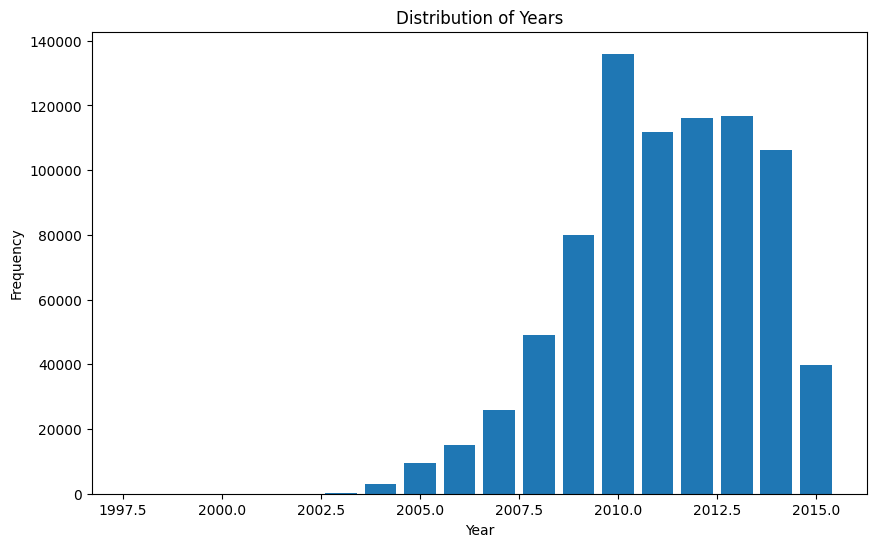

Number of unique patients: 171619


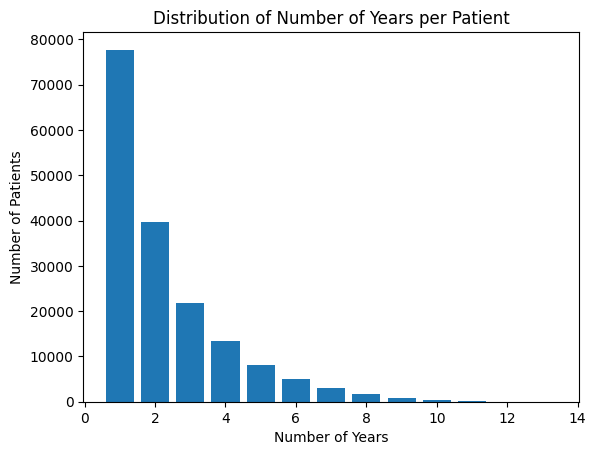

Number of patients with multiple records: 93905
Percentage of patients with multiple records: 54.72%
Average number of visits per patient: 4.71


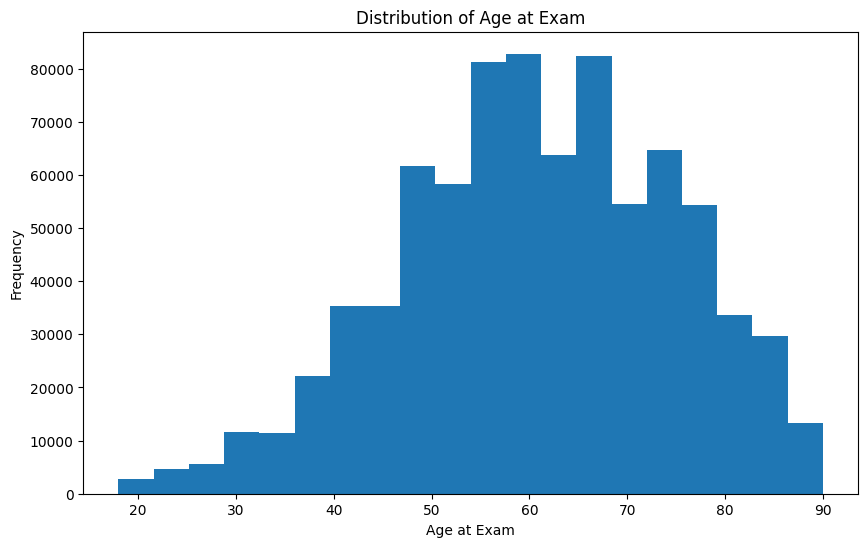

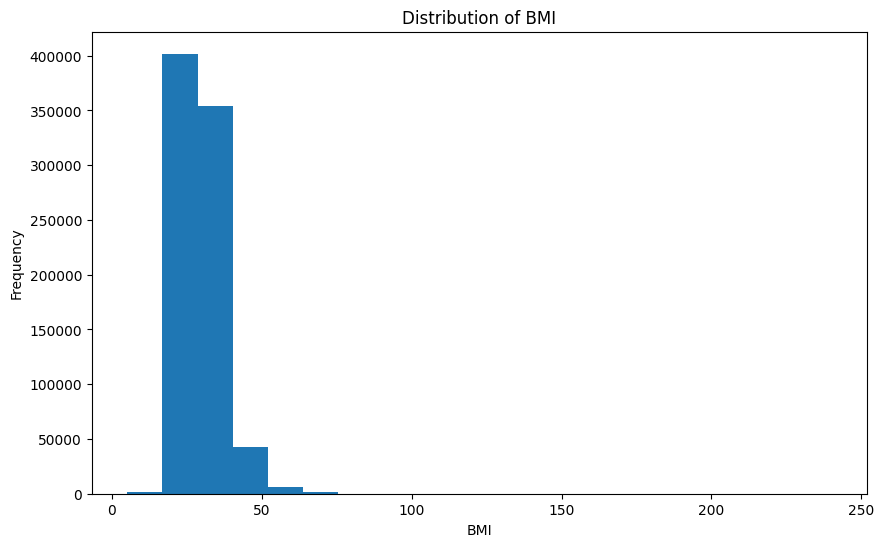

                   Minimum_Observed  Maximum_Observed  Normal_Min  Normal_Max  \
BMI                        5.080655        240.086698        10.0          80   
HDL                        0.100000          5.000000         0.1           5   
LDL                        0.100000         10.000000         0.1          10   
TG                         0.100000         57.340000         0.1          20   
Total_Cholesterol          0.760000         20.820000         1.0          15   
FBS                        2.000000         34.100000         1.0          30   
A1c                        0.530000         17.800000         3.0          20   
sBP                       40.000000        260.000000        50.0         300   

                   Min_Below_Plausible  Max_Above_Plausible  
BMI                               True                 True  
HDL                              False                False  
LDL                              False                False  
TG                    

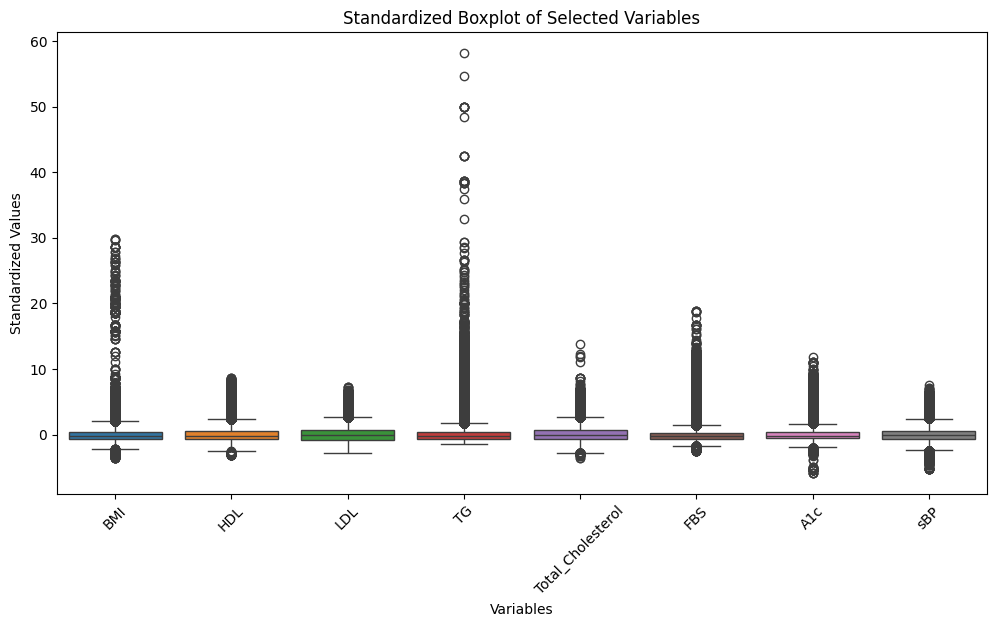

Number of missing values for Sex: 0
Depression      int64
[Anxiety)     float64
dtype: object
Depression
0    638336
1    170585
Name: count, dtype: int64
[Anxiety)
NaN    706185
0.0     68295
1.0     34441
Name: count, dtype: int64


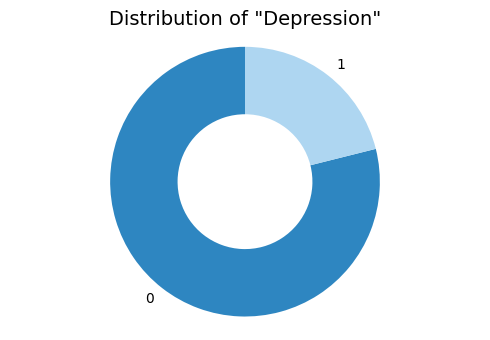

In [ ]:
# Count the number of observations
num_observations = len(cpc_RAW)
print(f"Number of observations: {num_observations}")

# Count the number of duplicated observations
num_duplicates = cpc_RAW.duplicated().sum()
print(f"Number of duplicated observations: {num_duplicates}")

# Calculate the percentage of duplicated rows
percentage_duplicates = (num_duplicates / num_observations) * 100
print(f"Percentage of duplicated rows: {percentage_duplicates:.2f}%")

# List the name of all features
feature_names = cpc_RAW.columns.tolist()
print(feature_names)

# Count observations per year
year_counts = cpc_RAW['Year'].value_counts().sort_index()

# Plot observations by year
plt.figure(figsize=(10, 6))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Years')
plt.show()

# Count the number of unique patient_id in the dataset
num_unique_patients = cpc_RAW['Patient_ID'].nunique()
print(f"Number of unique patients: {num_unique_patients}")

# Calculate the number of years recorded per patient
years_per_patient = cpc_RAW.groupby('Patient_ID')['Year'].nunique()

# Count how many patients fall into each "number of years followed"
years_followup_counts = years_per_patient.value_counts().sort_index()

# Plot distribution of number of years per patient
plt.figure()
plt.bar(years_followup_counts.index, years_followup_counts.values)
plt.xlabel('Number of Years')
plt.ylabel('Number of Patients')
plt.title('Distribution of Number of Years per Patient')
plt.show()

# Count how many patients have more than one record in dataset
multiple_records_count = (years_per_patient > 1).sum()
print(f"Number of patients with multiple records: {multiple_records_count}")

# Count the percentage of patients who have two or more records
percentage_multiple_records = (multiple_records_count / num_unique_patients) * 100
print(f"Percentage of patients with multiple records: {percentage_multiple_records:.2f}%")

# Calculate average number of visits per patient
average_visits = num_observations / num_unique_patients
print(f"Average number of visits per patient: {average_visits:.2f}")

# Create a histogram for Age_at_Exam variable
plt.figure(figsize=(10, 6))
plt.hist(cpc_RAW['Age_at_Exam'], bins=20)
plt.xlabel('Age at Exam')
plt.ylabel('Frequency')
plt.title('Distribution of Age at Exam')
plt.show()

# Create a histogram for BMI
plt.figure(figsize=(10, 6))
plt.hist(cpc_RAW['BMI'], bins=20)
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('Distribution of BMI')
plt.show()

# List variables that we want to investigate their biological plausibility
variables = [
    'BMI',
    'HDL',
    'LDL',
    'TG',
    'Total_Cholesterol',
    'FBS',
    'A1c',
    'sBP'
]

# Define biologically plausible limits
normal_ranges = {
    'BMI': (10, 80),
    'HDL': (0.1, 5),
    'LDL': (0.1, 10),
    'TG': (0.1, 20),
    'Total_Cholesterol': (1, 15),
    'FBS': (1, 30),
    'A1c': (3, 20),
    'sBP': (50, 300)
}

# Create summary table of observed minimum and maximum values
summary_table = pd.DataFrame({
    'Minimum_Observed': cpc_RAW[variables].min(),
    'Maximum_Observed': cpc_RAW[variables].max()
})

# Add normal range limits
summary_table['Normal_Min'] = summary_table.index.map(lambda x: normal_ranges[x][0])
summary_table['Normal_Max'] = summary_table.index.map(lambda x: normal_ranges[x][1])

# Flag whether observed min/max fall outside plausible limits
summary_table['Min_Below_Plausible'] = summary_table['Minimum_Observed'] < summary_table['Normal_Min']
summary_table['Max_Above_Plausible'] = summary_table['Maximum_Observed'] > summary_table['Normal_Max']

print(summary_table)

# Count number of implausible values for each variable
implausible_counts = {}

for var in variables:
    min_val, max_val = normal_ranges[var]
    count = (
        (cpc_RAW[var] < min_val) |
        (cpc_RAW[var] > max_val)
    ).sum()
    implausible_counts[var] = count

implausible_df = pd.DataFrame.from_dict(
    implausible_counts,
    orient='index',
    columns=['Number_of_Implausible_Values']
)

print(implausible_df)

# Standardize selected variables for visualization purposes
scaled_data = (cpc_RAW[variables] - cpc_RAW[variables].mean()) / cpc_RAW[variables].std()

# Create boxplot of standardized variables
plt.figure(figsize=(12, 6))
sns.boxplot(data=scaled_data)
plt.xticks(rotation=45)
plt.xlabel('Variables')
plt.ylabel('Standardized Values')
plt.title('Standardized Boxplot of Selected Variables')
plt.show()

# Check missing values for sex
missing_sex = cpc_RAW['Sex'].isnull().sum()
print(f"Number of missing values for Sex: {missing_sex}")

# Check variables' types
print(cpc_RAW[['Depression', '[Anxiety)']].dtypes)
counts_dep = cpc_RAW['Depression'].value_counts(dropna=False)
counts_anx = cpc_RAW['[Anxiety)'].value_counts(dropna=False)
print(counts_dep)
print(counts_anx)

# Distribution of depression
colors = ['#2E86C1', '#AED6F1', '#D5D8DC']
plt.figure(figsize=(5, 3.5))
plt.pie(
    counts_dep.values,
    labels=counts_dep.index.astype(str),
    colors=colors[:len(counts_dep)],
    startangle=90,
    wedgeprops=dict(width=0.5)
)
plt.axis('equal')
plt.title('Distribution of "Depression"', fontsize=14)
plt.tight_layout()
plt.show()


# 2. Reduce data and investigate missingness and biologically implausible records

In this section, first, we drop duplicated rows and keep variables we need in this project to reduce the dataset size.

In [ ]:
# Drop the duplicated rows and save it in a new data frame
cpc_REDUCED = cpc_RAW.drop_duplicates()
print(f"Number of observations after dropping duplicates: {len(cpc_REDUCED)}")


# Keep variables we need for longitudinal analysis
cpc_REDUCED = cpc_REDUCED[[
    # Identifiers
    'Patient_ID',
    'Year',
    'Sex',
    'Age_at_Exam',

    # Chronic condition binary indicators
    'HTN',
    'COPD',
    'Diabetes',
    'OA',
    'Depression',

    # Onset dates
    'HTN_OnsetDate',
    'OA_OnsetDate',
    'COPD_Date',
    'DM_OnsetDate',
    'Depression_OnsetDate',

    # Clinical measures (for plausibility checks)
    'BMI',
    'A1c',
    'FBS',
    'LDL',
    'HDL',
    'TG',
    'Total_Cholesterol',
    'sBP'
]]

# Count the number of unique patients
num_unique_patients = cpc_REDUCED['Patient_ID'].nunique()
print(f"Number of unique patients: {num_unique_patients}")

# View the first few rows of the dataset
cpc_REDUCED.head()


Number of observations after dropping duplicates: 745469
Number of unique patients: 171619


,Patient_ID,Year,Sex,Age_at_Exam,HTN,COPD,Diabetes,OA,Depression,HTN_OnsetDate,...,DM_OnsetDate,Depression_OnsetDate,BMI,A1c,FBS,LDL,HDL,TG,Total_Cholesterol,sBP
0,4001000000255938,2010,Male,69,1,0,0,0,0,2009-11-13,...,NaN,NaN,26.000000,5.9,6.2,3.35,1.03,1.74,5.17,140.0
1,4001000000255945,2011,Female,56,0,0,0,0,0,NaN,...,NaN,NaN,24.000000,NaN,4.6,4.01,1.84,1.51,6.54,120.0
2,4001000000257361,2014,Female,35,0,0,0,0,0,NaN,...,NaN,NaN,51.195667,NaN,4.4,3.11,1.26,0.68,4.68,100.0
3,4001000000257525,2013,Female,43,0,0,0,0,0,NaN,...,NaN,NaN,67.794421,NaN,5.1,2.96,1.09,1.11,4.55,138.0
4,4001000000255830,2013,Male,49,1,0,0,0,0,2010-07-12,...,NaN,NaN,34.000000,5.9,4.3,4.06,1.34,1.23,6.40,141.0


Next, we investigate missing values for all the included variables in our reduced dataset.

In [ ]:
# Calculate the nummber of missing values in the dataset
missing_values = cpc_REDUCED.isnull().sum()

# Create a table to show the number and percentage of missing values per variable
missing_table = pd.DataFrame({
    'Count': missing_values,
    'Percentage (%)': (missing_values / len(cpc_REDUCED) * 100).round(2)
    })

print(missing_table)

# Since we have high numbers of missings for onset dates, we investigate
# these missings among patients who have had those conditions

# Calculate frequency and percentage of missingness among HTN == 1 for HTN_OnsetDate variable
htn_missing = cpc_REDUCED[
    (cpc_REDUCED['HTN'] == 1) &
    (cpc_REDUCED['HTN_OnsetDate'].isnull())
]

htn_missing_count = len(htn_missing)
htn_missing_percentage = (htn_missing_count / len(cpc_REDUCED)) * 100

print(f"Number of missing records for HTN == 1: {htn_missing_count}")
print(f"Percentage of missing records for HTN == 1: {htn_missing_percentage:.2f}")

# Calculate frequency and percentage of missingness among Diabetes == 1 for DM_OnsetDate
dm_missing = cpc_REDUCED[
    (cpc_REDUCED['Diabetes'] == 1) &
    (cpc_REDUCED['DM_OnsetDate'].isnull())
]

dm_missing_count = len(dm_missing)
dm_missing_percentage = (dm_missing_count / len(cpc_REDUCED)) * 100

print(f"Number of missing records for Diabetes == 1: {dm_missing_count}")
print(f"Percentage of missing records for Diabetes == 1: {dm_missing_percentage:.2f}")

# Calculate frequency and percentage of missingness among copd == 1 for copd_Date
copd_missing = cpc_REDUCED[
    (cpc_REDUCED['COPD'] == 1) &
    (cpc_REDUCED['COPD_Date'].isnull())
]

copd_missing_count = len(copd_missing)
copd_missing_percentage = (copd_missing_count / len(cpc_REDUCED)) * 100

print(f"Number of missing records for copd == 1: {copd_missing_count}")
print(f"Percentage of missing records for copd == 1: {copd_missing_percentage:.2f}")

# Calculate frequency and precentage of missingness among OA == 1 for OA_OnsetDate
oa_missing = cpc_REDUCED[
    (cpc_REDUCED['OA'] == 1) &
    (cpc_REDUCED['OA_OnsetDate'].isnull())
]

oa_missing_count = len(oa_missing)
oa_missing_percentage = (oa_missing_count / len(cpc_REDUCED)) * 100

print(f"Number of missing records for OA == 1: {oa_missing_count}")
print(f"Percentage of missing records for OA == 1: {oa_missing_percentage:.2f}")

# Calculate frequency and percentage of missingness among Depression == 1 for Depression_OnsetDate
dep_missing = cpc_REDUCED[
    (cpc_REDUCED['Depression'] == 1) &
    (cpc_REDUCED['Depression_OnsetDate'].isnull())
]

dep_missing_count = len(dep_missing)
dep_missing_percentage = (dep_missing_count / len(cpc_REDUCED)) * 100

print(f"Number of missing records for Depression == 1: {dep_missing_count}")
print(f"Percentage of missing records for Depression == 1: {dep_missing_percentage:.2f}")



                       Count  Percentage (%)
Patient_ID                 0            0.00
Year                       0            0.00
Sex                        0            0.00
Age_at_Exam                0            0.00
HTN                        0            0.00
COPD                       0            0.00
Diabetes                   0            0.00
OA                         0            0.00
Depression                 0            0.00
HTN_OnsetDate         335382           44.99
OA_OnsetDate          521831           70.00
COPD_Date             680945           91.34
DM_OnsetDate          532507           71.43
Depression_OnsetDate  584571           78.42
BMI                        0            0.00
A1c                   392638           52.67
FBS                        0            0.00
LDL                     4853            0.65
HDL                     7645            1.03
TG                      9228            1.24
Total_Cholesterol      16144            2.17
sBP       

Further, we will identify observations that include biologically implausible values, including:

*   BMI < 10
*   BMI > 100
*   sBP < 50
*   A1c < 3

We save the observations that include biologically implausible observations in a new dataset in addition to all other information we have on those patients to investigate reasons behind them, such as measurement error, which could inform our decisions regarding changing them into NA or imputation.

In [ ]:
# Define implausible conditions
implausible_condition = (
    (cpc_REDUCED['BMI'] < 10) |
    (cpc_REDUCED['BMI'] > 100) |
    (cpc_REDUCED['sBP'] < 50) |
    (cpc_REDUCED['A1c'] < 3)
)

# Add a flag column
cpc_REDUCED['Implausible_Flag'] = implausible_condition.astype(int)

print("Number of implausible observations:",
      cpc_REDUCED['Implausible_Flag'].sum())


# Identify patients who have at least one implausible record
implausible_patients = cpc_REDUCED.loc[
    cpc_REDUCED['Implausible_Flag'] == 1,
    'Patient_ID'
].unique()

print("Number of patients with implausible values:",
      len(implausible_patients))


# Create dataframe containing ALL records of those patients
cpc_IMPLAUSIBLE_PATIENTS_ALL_RECORDS = cpc_REDUCED[
    cpc_REDUCED['Patient_ID'].isin(implausible_patients)
].copy()

print("Total records for patients with implausible values:",
      len(cpc_IMPLAUSIBLE_PATIENTS_ALL_RECORDS))


# Sort longitudinally to inspect patterns
cpc_IMPLAUSIBLE_PATIENTS_ALL_RECORDS = \
    cpc_IMPLAUSIBLE_PATIENTS_ALL_RECORDS.sort_values(
        ['Patient_ID', 'Year']
    )


# Inspect selected columns
cpc_IMPLAUSIBLE_PATIENTS_ALL_RECORDS[
    ['Patient_ID', 'Year', 'BMI', 'A1c', 'sBP', 'Implausible_Flag']
].head(20)


# --------------------------------------------------
# Replace implausible values with NaN (do not drop rows)
# --------------------------------------------------

# Count before replacement
print("Implausible BMI values:",
      ((cpc_REDUCED['BMI'] < 10) | (cpc_REDUCED['BMI'] > 100)).sum())

print("Implausible sBP values:",
      (cpc_REDUCED['sBP'] < 50).sum())

print("Implausible A1c values:",
      (cpc_REDUCED['A1c'] < 3).sum())


# Replace with NaN
cpc_REDUCED.loc[
    (cpc_REDUCED['BMI'] < 10) | (cpc_REDUCED['BMI'] > 100),
    'BMI'
] = np.nan

cpc_REDUCED.loc[
    cpc_REDUCED['sBP'] < 50,
    'sBP'
] = np.nan

cpc_REDUCED.loc[
    cpc_REDUCED['A1c'] < 3,
    'A1c'
] = np.nan


print("Implausible values replaced with NaN.")

Number of implausible observations: 219
Number of patients with implausible values: 101
Total records for patients with implausible values: 636
Implausible BMI values: 176
Implausible sBP values: 12
Implausible A1c values: 31
Implausible values replaced with NaN.


# 3. Reorganize data for longitudinal analysis

In this section, first, we do a quality control check of the dataset, where we examine if the onset date of chronic conditions recorded for one patient is identical across different records of visits (as it should be.)

Second, we convert the event-based dataset to patient-based data.

HTN_OnsetDate: 0 patients with inconsistent onset dates
OA_OnsetDate: 0 patients with inconsistent onset dates
COPD_Date: 0 patients with inconsistent onset dates
DM_OnsetDate: 0 patients with inconsistent onset dates
Depression_OnsetDate: 0 patients with inconsistent onset dates
Number of patients in patient-level dataset: 171619
Follow-up years summary:
count    171619.000000
mean          1.932717
std           2.416369
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          16.000000
Name: Followup_Years, dtype: float64


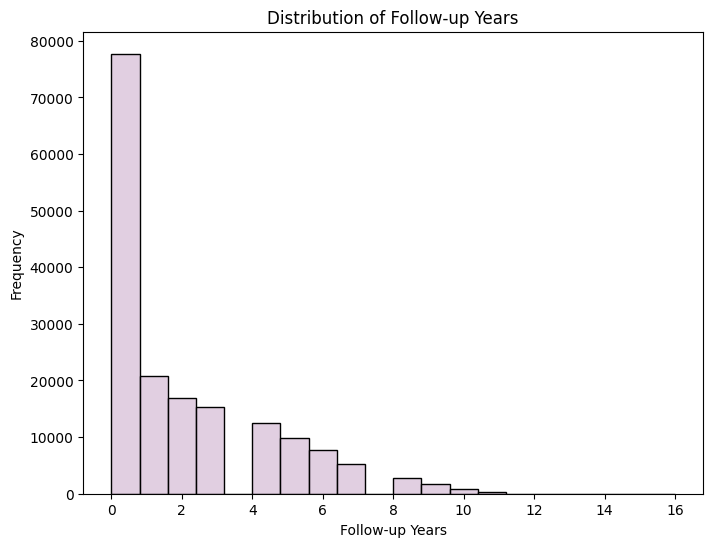

In [ ]:
# Convert onset date variables to datetime
date_columns = [
    'HTN_OnsetDate',
    'OA_OnsetDate',
    'COPD_Date',
    'DM_OnsetDate',
    'Depression_OnsetDate'
]

for col in date_columns:
    cpc_REDUCED[col] = pd.to_datetime(cpc_REDUCED[col], errors='coerce')


# Function to check inconsistency for chronic condition onset date
def check_onset_consistency(data, onset_column):

    inconsistency = (
        data
        .groupby('Patient_ID')[onset_column]
        .nunique()
    )

    problem_patients = inconsistency[inconsistency > 1]

    print(f"{onset_column}: {len(problem_patients)} patients with inconsistent onset dates")

    return problem_patients


# Check consistency of onset date for all chronic conditions in this study
htn_problem = check_onset_consistency(cpc_REDUCED, 'HTN_OnsetDate')
oa_problem = check_onset_consistency(cpc_REDUCED, 'OA_OnsetDate')
copd_problem = check_onset_consistency(cpc_REDUCED, 'COPD_Date')
dm_problem = check_onset_consistency(cpc_REDUCED, 'DM_OnsetDate')
dep_problem = check_onset_consistency(cpc_REDUCED, 'Depression_OnsetDate')


# Sort dataset longitudinally before extracting baseline
cpc_REDUCED = cpc_REDUCED.sort_values(['Patient_ID', 'Year'])

# Calculate follow-up years for each patient (last observation - first observation)
followup_years = (
    cpc_REDUCED
    .groupby('Patient_ID')
    ['Year']
    .agg(lambda x: x.max() - x.min())
    .rename('Followup_Years')
    .reset_index()
)

# Extract baseline visit information (first observed record per patient)
baseline_info = (
    cpc_REDUCED
    .groupby('Patient_ID')
    .first()[[
        'Year',
        'Age_at_Exam',
        'Sex',
        'BMI',
        'A1c',
        'FBS',
        'LDL',
        'HDL',
        'TG',
        'Total_Cholesterol',
        'sBP'
    ]]
    .reset_index()
)



# Collapse onset dates and binary disease indicators to patient-level
onset_info = (
    cpc_REDUCED
    .groupby('Patient_ID')
    .agg({
        'HTN_OnsetDate': 'min',
        'OA_OnsetDate': 'min',
        'COPD_Date': 'min',
        'DM_OnsetDate': 'min',
        'Depression_OnsetDate': 'min',

        'HTN': 'max',
        'COPD': 'max',
        'Diabetes': 'max',
        'OA': 'max',
        'Depression': 'max'
    })
    .reset_index()
)


# Merge baseline information with onset information and follow-up years
cpc_REDUCED_p = baseline_info.merge(
    onset_info,
    on='Patient_ID',
    how='left'
).merge(
    followup_years,
    on='Patient_ID',
    how='left'
)

print(f"Number of patients in patient-level dataset: {len(cpc_REDUCED_p)}")
print(f"Follow-up years summary:\n{cpc_REDUCED_p['Followup_Years'].describe()}")

# Plot a histogram for follow-up years
plt.figure(figsize=(8, 6))
sns.histplot(
    cpc_REDUCED_p['Followup_Years'],
    bins=20,
    color='thistle'
)
plt.xlabel('Follow-up Years')
plt.ylabel('Frequency')
plt.title('Distribution of Follow-up Years')


# Create number of chronic conditions variable
cpc_REDUCED_p['Num_Chronic'] = (
    cpc_REDUCED_p[['HTN','COPD','Diabetes','OA']].sum(axis=1)
)


In [ ]:
# Create a dataset including only patients who have recorded chroninc condition(s)
cpc_with_condition_p = cpc_REDUCED_p[
    (cpc_REDUCED_p['HTN'] == 1) |
    (cpc_REDUCED_p['COPD'] == 1) |
    (cpc_REDUCED_p['Diabetes'] == 1) |
    (cpc_REDUCED_p['OA'] == 1)
].copy()

print(f"Number of patients with chronic condition(s): {len(cpc_with_condition_p)}")


Number of patients with chronic condition(s): 89004


# 4.1 Define cohort and depression outcome properly (whole cohort)

In [ ]:
# Convert onset date variables to datetime (ensure correct type)
date_columns = [
    'HTN_OnsetDate',
    'OA_OnsetDate',
    'COPD_Date',
    'DM_OnsetDate',
    'Depression_OnsetDate'
]

for col in date_columns:
    cpc_REDUCED_p[col] = pd.to_datetime(cpc_REDUCED_p[col], errors='coerce')


# Convert baseline year to a datetime object (January 1 of baseline year)
cpc_REDUCED_p['Baseline_Date'] = pd.to_datetime(
    cpc_REDUCED_p['Year'].astype(str) + "-01-01"
)


# Remove patients with depression prior to first visit (baseline)
cpc_REDUCED_p = cpc_REDUCED_p.loc[
    (cpc_REDUCED_p['Depression_OnsetDate'].isna()) |
    (cpc_REDUCED_p['Depression_OnsetDate'] > cpc_REDUCED_p['Baseline_Date'])
].copy()

print(f"Number of patients after removing pre-baseline depression: {len(cpc_REDUCED_p)}")


# Calculate number and percentage of people with depression
depression_counts = cpc_REDUCED_p['Depression'].value_counts().sort_index()
depression_percentage = (depression_counts / len(cpc_REDUCED_p) * 100).round(2)

depression_table = pd.DataFrame({
    'Count': depression_counts,
    'Percentage (%)': depression_percentage
})

print("Depression Distribution:")
print(depression_table)


# Create earliest chronic condition onset date
cpc_REDUCED_p['First_Chronic_Onset'] = cpc_REDUCED_p[
    ['HTN_OnsetDate', 'OA_OnsetDate', 'COPD_Date', 'DM_OnsetDate']
].min(axis=1)

# ── Time Zero ────────────────────────────────────────────────────────────────

# Rename existing Time_Zero to reflect it is based on ANY chronic condition
# If ANY chronic onset occurs after baseline → use earliest chronic onset
# Otherwise → use baseline date
cpc_REDUCED_p['Time_Zero_Any'] = cpc_REDUCED_p['Baseline_Date']

mask_any = (
    (cpc_REDUCED_p['First_Chronic_Onset'].notna()) &
    (cpc_REDUCED_p['First_Chronic_Onset'] > cpc_REDUCED_p['Baseline_Date'])
)

cpc_REDUCED_p.loc[mask_any, 'Time_Zero_Any'] = \
    cpc_REDUCED_p.loc[mask_any, 'First_Chronic_Onset']


# Time Zero for HTN specifically
# If HTN onset occurs after baseline → use HTN onset
# Otherwise → use baseline date
cpc_REDUCED_p['Time_Zero_HTN'] = cpc_REDUCED_p['Baseline_Date']

mask_htn = (
    (cpc_REDUCED_p['HTN_OnsetDate'].notna()) &
    (cpc_REDUCED_p['HTN_OnsetDate'] > cpc_REDUCED_p['Baseline_Date'])
)

cpc_REDUCED_p.loc[mask_htn, 'Time_Zero_HTN'] = \
    cpc_REDUCED_p.loc[mask_htn, 'HTN_OnsetDate']


# Time Zero for OA specifically
cpc_REDUCED_p['Time_Zero_OA'] = cpc_REDUCED_p['Baseline_Date']

mask_oa = (
    (cpc_REDUCED_p['OA_OnsetDate'].notna()) &
    (cpc_REDUCED_p['OA_OnsetDate'] > cpc_REDUCED_p['Baseline_Date'])
)

cpc_REDUCED_p.loc[mask_oa, 'Time_Zero_OA'] = \
    cpc_REDUCED_p.loc[mask_oa, 'OA_OnsetDate']


# Time Zero for COPD specifically
cpc_REDUCED_p['Time_Zero_COPD'] = cpc_REDUCED_p['Baseline_Date']

mask_copd = (
    (cpc_REDUCED_p['COPD_Date'].notna()) &
    (cpc_REDUCED_p['COPD_Date'] > cpc_REDUCED_p['Baseline_Date'])
)

cpc_REDUCED_p.loc[mask_copd, 'Time_Zero_COPD'] = \
    cpc_REDUCED_p.loc[mask_copd, 'COPD_Date']


# Time Zero for Diabetes specifically
cpc_REDUCED_p['Time_Zero_DM'] = cpc_REDUCED_p['Baseline_Date']

mask_dm = (
    (cpc_REDUCED_p['DM_OnsetDate'].notna()) &
    (cpc_REDUCED_p['DM_OnsetDate'] > cpc_REDUCED_p['Baseline_Date'])
)

cpc_REDUCED_p.loc[mask_dm, 'Time_Zero_DM'] = \
    cpc_REDUCED_p.loc[mask_dm, 'DM_OnsetDate']


# Summary
print("Time Zero variables created:")
print(f"  Time_Zero_Any  — based on earliest of any chronic condition onset")
print(f"  Time_Zero_HTN  — based on HTN onset")
print(f"  Time_Zero_OA   — based on OA onset")
print(f"  Time_Zero_COPD — based on COPD onset")
print(f"  Time_Zero_DM   — based on Diabetes onset")


# Define end of 5-year follow-up window
cpc_REDUCED_p['Followup_End_5yr'] = \
    cpc_REDUCED_p['Time_Zero_Any'] + pd.DateOffset(years=5)

# Define end of 3-year follow-up window
cpc_REDUCED_p['Followup_End_3yr'] = \
    cpc_REDUCED_p['Time_Zero_Any'] + pd.DateOffset(years=3)

# Define end of 1-year follow-up window
cpc_REDUCED_p['Followup_End_1yr'] = \
    cpc_REDUCED_p['Time_Zero_Any'] + pd.DateOffset(years=1)

# Create 5-year depression outcome
cpc_REDUCED_p['Depression_within_5yrs'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_5yr'])
).astype(int)

# Create 3-year depression outcome
cpc_REDUCED_p['Depression_within_3yrs'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_3yr'])
).astype(int)

# Create 1-year depression outcome
cpc_REDUCED_p['Depression_within_1yr'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_1yr'])
).astype(int)

# ── Condition-Specific Depression Outcomes ───────────────────────────────────

# --- HTN-specific follow-up windows and depression outcomes ---
cpc_REDUCED_p['Followup_End_5yr_HTN'] = cpc_REDUCED_p['Time_Zero_HTN'] + pd.DateOffset(years=5)
cpc_REDUCED_p['Followup_End_3yr_HTN'] = cpc_REDUCED_p['Time_Zero_HTN'] + pd.DateOffset(years=3)
cpc_REDUCED_p['Followup_End_1yr_HTN'] = cpc_REDUCED_p['Time_Zero_HTN'] + pd.DateOffset(years=1)

cpc_REDUCED_p['Depression_within_5yrs_HTN'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_5yr_HTN'])
).astype(int)

cpc_REDUCED_p['Depression_within_3yrs_HTN'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_3yr_HTN'])
).astype(int)

cpc_REDUCED_p['Depression_within_1yr_HTN'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_1yr_HTN'])
).astype(int)


# --- OA-specific follow-up windows and depression outcomes ---
cpc_REDUCED_p['Followup_End_5yr_OA'] = cpc_REDUCED_p['Time_Zero_OA'] + pd.DateOffset(years=5)
cpc_REDUCED_p['Followup_End_3yr_OA'] = cpc_REDUCED_p['Time_Zero_OA'] + pd.DateOffset(years=3)
cpc_REDUCED_p['Followup_End_1yr_OA'] = cpc_REDUCED_p['Time_Zero_OA'] + pd.DateOffset(years=1)

cpc_REDUCED_p['Depression_within_5yrs_OA'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_5yr_OA'])
).astype(int)

cpc_REDUCED_p['Depression_within_3yrs_OA'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_3yr_OA'])
).astype(int)

cpc_REDUCED_p['Depression_within_1yr_OA'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_1yr_OA'])
).astype(int)


# --- COPD-specific follow-up windows and depression outcomes ---
cpc_REDUCED_p['Followup_End_5yr_COPD'] = cpc_REDUCED_p['Time_Zero_COPD'] + pd.DateOffset(years=5)
cpc_REDUCED_p['Followup_End_3yr_COPD'] = cpc_REDUCED_p['Time_Zero_COPD'] + pd.DateOffset(years=3)
cpc_REDUCED_p['Followup_End_1yr_COPD'] = cpc_REDUCED_p['Time_Zero_COPD'] + pd.DateOffset(years=1)

cpc_REDUCED_p['Depression_within_5yrs_COPD'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_5yr_COPD'])
).astype(int)

cpc_REDUCED_p['Depression_within_3yrs_COPD'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_3yr_COPD'])
).astype(int)

cpc_REDUCED_p['Depression_within_1yr_COPD'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_1yr_COPD'])
).astype(int)


# --- Diabetes-specific follow-up windows and depression outcomes ---
cpc_REDUCED_p['Followup_End_5yr_DM'] = cpc_REDUCED_p['Time_Zero_DM'] + pd.DateOffset(years=5)
cpc_REDUCED_p['Followup_End_3yr_DM'] = cpc_REDUCED_p['Time_Zero_DM'] + pd.DateOffset(years=3)
cpc_REDUCED_p['Followup_End_1yr_DM'] = cpc_REDUCED_p['Time_Zero_DM'] + pd.DateOffset(years=1)

cpc_REDUCED_p['Depression_within_5yrs_DM'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_5yr_DM'])
).astype(int)

cpc_REDUCED_p['Depression_within_3yrs_DM'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_3yr_DM'])
).astype(int)

cpc_REDUCED_p['Depression_within_1yr_DM'] = (
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_OnsetDate'] <= cpc_REDUCED_p['Followup_End_1yr_DM'])
).astype(int)


# ── Summary of condition-specific depression outcomes ────────────────────────
conditions = ['HTN', 'OA', 'COPD', 'DM']
windows    = ['1yr', '3yrs', '5yrs']

print("Condition-Specific Depression Outcome Counts:\n")
print(f"{'Outcome Variable':<35} {'N (%)':>10}")
print("-" * 47)

for cond in conditions:
    for win in windows:
        col = f'Depression_within_{win}_{cond}'
        n   = cpc_REDUCED_p[col].sum()
        pct = n / len(cpc_REDUCED_p) * 100
        print(f"  {col:<33} {n:>4} ({pct:.1f}%)")
    print()

# Create table for 5-year depression outcome
outcome_counts_5yr = \
    cpc_REDUCED_p['Depression_within_5yrs'].value_counts().sort_index()

outcome_table_5yr = pd.DataFrame({
    'Count': outcome_counts_5yr,
    'Percentage (%)': (
        outcome_counts_5yr / outcome_counts_5yr.sum() * 100
    ).round(2)
})

outcome_table_5yr.index = [
    'No Depression (0)',
    'Depression within 5 yrs (1)'
]

print("5-Year Depression Outcome Distribution:")
print(outcome_table_5yr)


# Create table for 3-year and 1-year depression outcome
outcome_counts_3yr = \
    cpc_REDUCED_p['Depression_within_3yrs'].value_counts().sort_index()

outcome_table_3yr = pd.DataFrame({
    'Count': outcome_counts_3yr,
    'Percentage (%)': (
        outcome_counts_3yr / outcome_counts_3yr.sum() * 100
    ).round(2)
})

outcome_counts_1yr = \
    cpc_REDUCED_p['Depression_within_1yr'].value_counts().sort_index()


outcome_table_1yr = pd.DataFrame({
    'Count': outcome_counts_1yr,
    'Percentage (%)': (
        outcome_counts_1yr / outcome_counts_1yr.sum() * 100
    ).round(2)
})

outcome_table_3yr.index = [
    'No Depression (0)',
    'Depression within 3 yrs (1)'
]

outcome_table_1yr.index = [
    'No Depression (0)',
    'Depression within 1 yr (1)'
]

print("3-Year Depression Outcome Distribution:")
print(outcome_table_3yr)

print("1-Year Depression Outcome Distribution:")
print(outcome_table_1yr)

# Define exposure status at time zero
cpc_REDUCED_p['HTN_exposed'] = (
    (cpc_REDUCED_p['HTN_OnsetDate'].notna()) &
    (cpc_REDUCED_p['HTN_OnsetDate'] <= cpc_REDUCED_p['Time_Zero_Any'])
).astype(int)

cpc_REDUCED_p['OA_exposed'] = (
    (cpc_REDUCED_p['OA_OnsetDate'].notna()) &
    (cpc_REDUCED_p['OA_OnsetDate'] <= cpc_REDUCED_p['Time_Zero_Any'])
).astype(int)

cpc_REDUCED_p['COPD_exposed'] = (
    (cpc_REDUCED_p['COPD_Date'].notna()) &
    (cpc_REDUCED_p['COPD_Date'] <= cpc_REDUCED_p['Time_Zero_Any'])
).astype(int)

cpc_REDUCED_p['Diabetes_exposed'] = (
    (cpc_REDUCED_p['DM_OnsetDate'].notna()) &
    (cpc_REDUCED_p['DM_OnsetDate'] <= cpc_REDUCED_p['Time_Zero_Any'])
).astype(int)


# Create number of chronic conditions at time zero
cpc_REDUCED_p['Num_Chronic_at_TimeZero_Any'] = \
    cpc_REDUCED_p[
        ['HTN_exposed',
         'OA_exposed',
         'COPD_exposed',
         'Diabetes_exposed']
    ].sum(axis=1)


# Create table for number of chronic conditions at time zero
chronic_counts = \
    cpc_REDUCED_p['Num_Chronic_at_TimeZero_Any'].value_counts().sort_index()

chronic_table = pd.DataFrame({
    'Count': chronic_counts,
    'Percentage (%)': (
        chronic_counts / chronic_counts.sum() * 100
    ).round(2)
})

print("Chronic Condition Distribution at Time Zero_Any:")
print(chronic_table)

Number of patients after removing pre-baseline depression: 158293
Depression Distribution:
             Count  Percentage (%)
Depression                        
0           139234           87.96
1            19059           12.04
Time Zero variables created:
  Time_Zero_Any  — based on earliest of any chronic condition onset
  Time_Zero_HTN  — based on HTN onset
  Time_Zero_OA   — based on OA onset
  Time_Zero_COPD — based on COPD onset
  Time_Zero_DM   — based on Diabetes onset
Condition-Specific Depression Outcome Counts:

Outcome Variable                         N (%)
-----------------------------------------------
  Depression_within_1yr_HTN         8874 (5.6%)
  Depression_within_3yrs_HTN        14423 (9.1%)
  Depression_within_5yrs_HTN        17171 (10.8%)

  Depression_within_1yr_OA          9058 (5.7%)
  Depression_within_3yrs_OA         14540 (9.2%)
  Depression_within_5yrs_OA         17202 (10.9%)

  Depression_within_1yr_COPD        8073 (5.1%)
  Depression_within_3yrs_COPD

In [ ]:
cpc_REDUCED_p.head(100)

,Patient_ID,Year,Age_at_Exam,Sex,BMI,A1c,FBS,LDL,HDL,TG,...,Followup_End_3yr_DM,Followup_End_1yr_DM,Depression_within_5yrs_DM,Depression_within_3yrs_DM,Depression_within_1yr_DM,HTN_exposed,OA_exposed,COPD_exposed,Diabetes_exposed,Num_Chronic_at_TimeZero_Any
0,1001000000000054,2009,60,Male,28.3,6.1,5.6,1.93,0.76,1.53,...,2012-01-01,2010-01-01,0,0,0,0,0,1,0,1
1,1001000000000135,2015,49,Male,24.8,5.3,5.1,3.14,1.09,1.32,...,2018-01-01,2016-01-01,0,0,0,0,1,0,0,1
2,1001000000000196,2007,53,Female,31.6,NaN,4.9,2.86,1.06,NaN,...,2010-01-01,2008-01-01,0,0,0,1,0,0,0,1
4,1001000000000437,2007,52,Male,30.8,NaN,5.8,4.52,1.37,1.68,...,2010-01-01,2008-01-01,0,0,0,0,1,0,0,1
5,1001000000000485,2005,47,Male,31.3,NaN,5.2,2.55,1.33,2.01,...,2008-01-01,2006-01-01,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,1001000000005188,2006,54,Female,17.0,NaN,4.7,1.99,2.48,0.82,...,2009-01-01,2007-01-01,1,1,1,1,0,0,0,1
113,1001000000005243,2007,80,Female,27.9,NaN,5.4,2.84,1.61,1.61,...,2010-01-01,2008-01-01,0,0,0,1,1,0,0,2
114,1001000000005262,2007,71,Female,18.6,NaN,5.4,3.85,1.49,0.94,...,2010-01-01,2008-01-01,1,1,0,1,0,0,0,1
115,1001000000005272,2005,48,Female,25.0,NaN,4.6,4.61,1.27,1.28,...,2008-01-01,2006-01-01,0,0,0,0,0,0,0,0


In [ ]:
# Calculate the difference between Depression_OnsetDate and Baseline_Date in years
cpc_REDUCED_p['Depression_Onset_Years_After_Baseline'] = \
    (cpc_REDUCED_p['Depression_OnsetDate'] - cpc_REDUCED_p['Baseline_Date']).dt.days / 365.25

# Filter for actual depression onsets after baseline
depression_onsets_after_baseline = cpc_REDUCED_p[
    (cpc_REDUCED_p['Depression_OnsetDate'].notna()) &
    (cpc_REDUCED_p['Depression_Onset_Years_After_Baseline'] > 0)
].copy()

# Calculate and print the number of depression onsets for each observed year
if not depression_onsets_after_baseline.empty:
    max_onset_year = int(depression_onsets_after_baseline['Depression_Onset_Years_After_Baseline'].max())

    for year_interval in range(1, max_onset_year + 1):
        num_onset = depression_onsets_after_baseline[
            depression_onsets_after_baseline['Depression_Onset_Years_After_Baseline'] <= year_interval
        ].shape[0]
        print(f"Number of depression onsets within {year_interval} year(s) after baseline: {num_onset}")
else:
    print("No depression onsets observed after baseline.")


Number of depression onsets within 1 year(s) after baseline: 7519
Number of depression onsets within 2 year(s) after baseline: 11062
Number of depression onsets within 3 year(s) after baseline: 13627
Number of depression onsets within 4 year(s) after baseline: 15429
Number of depression onsets within 5 year(s) after baseline: 16737
Number of depression onsets within 6 year(s) after baseline: 17702
Number of depression onsets within 7 year(s) after baseline: 18354
Number of depression onsets within 8 year(s) after baseline: 18724
Number of depression onsets within 9 year(s) after baseline: 18905
Number of depression onsets within 10 year(s) after baseline: 19015
Number of depression onsets within 11 year(s) after baseline: 19055


In [ ]:
# Calculate the median duration of time between baseline and depression onset
# We already have 'Depression_Onset_Years_After_Baseline' from the previous step

# Filter for actual depression onsets after baseline (excluding patients with no onset)
depression_durations = cpc_REDUCED_p[
    cpc_REDUCED_p['Depression_Onset_Years_After_Baseline'].notna()
]['Depression_Onset_Years_After_Baseline']

median_duration = depression_durations.median()

print(f"The median duration of time between baseline data and depression onset is: {median_duration:.2f} years")


The median duration of time between baseline data and depression onset is: 1.48 years


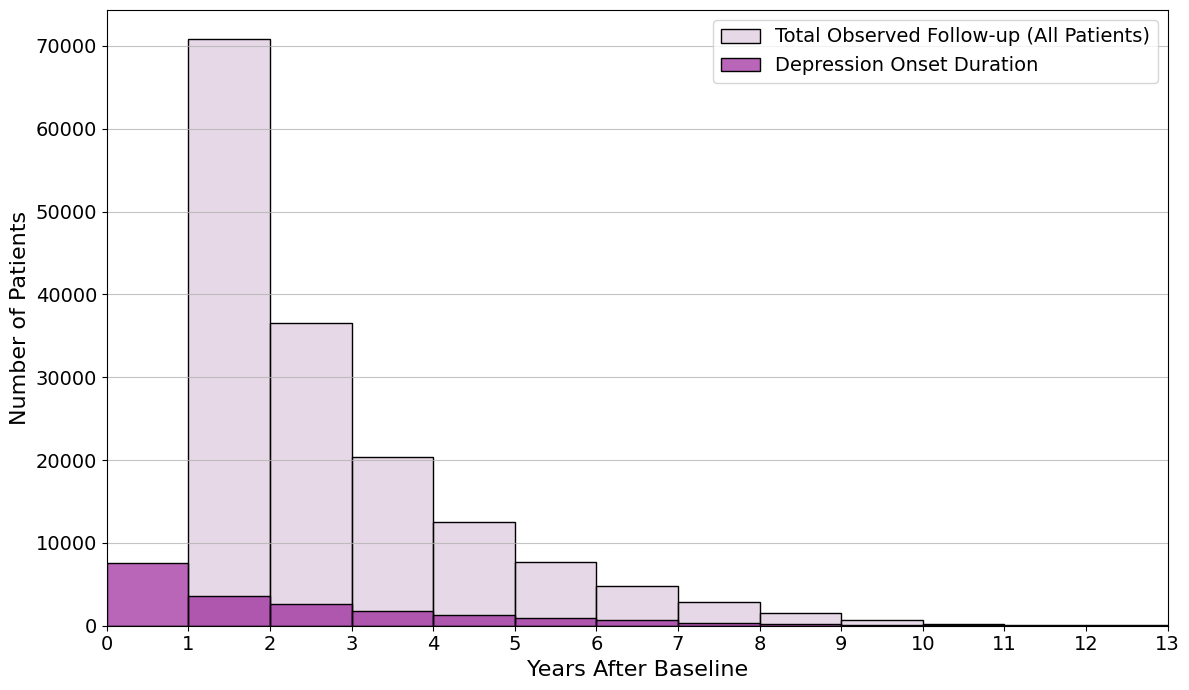

Number of individuals followed only once: 70799
Percentage of individuals followed for only one year: 44.73%


In [ ]:
# Calculate total observed follow-up duration for each patient in cpc_REDUCED_p
# This counts the number of unique years each patient has a record in the original (deduplicated) data.
years_observed_per_patient = cpc_REDUCED.groupby('Patient_ID')['Year'].nunique()
total_followup_durations = cpc_REDUCED_p['Patient_ID'].map(years_observed_per_patient)

# Define bins for the histograms
bins = np.arange(0, int(total_followup_durations.max()) + 2, 1) # Dynamically set bins based on max follow-up duration

# Ensure depression_durations is accessible (it was defined in cell 1e5d44a4)
depression_durations = cpc_REDUCED_p[
    cpc_REDUCED_p['Depression_Onset_Years_After_Baseline'].notna()
]['Depression_Onset_Years_After_Baseline']

plt.figure(figsize=(12, 7))

# Plot the total observed follow-up duration for all patients
sns.histplot(
    total_followup_durations,
    bins=bins,
    color='thistle',
    label='Total Observed Follow-up (All Patients)',
    alpha=0.6,
    kde=False
)

# Plot the depression onset duration for patients with onset
sns.histplot(
    depression_durations, # Corrected variable name
    bins=bins,
    color='darkmagenta',
    label='Depression Onset Duration',
    alpha=0.6,
    kde=False
)

# Remove title
# plt.title(...)

# Larger axis labels
plt.xlabel('Years After Baseline', fontsize=16)
plt.ylabel('Number of Patients', fontsize=16)

# Larger tick labels
plt.xticks(bins, fontsize=14)
plt.yticks(fontsize=14)

# Larger legend
plt.legend(fontsize=14)

plt.grid(axis='y', alpha=0.75)
plt.xlim(0, max(bins) - 1)
plt.tight_layout()
plt.show()

# Calculate the number of individuals that are followed only once
num_followed_once = (total_followup_durations == 1).sum()
print(f"Number of individuals followed only once: {num_followed_once}")

# Calculate the percentage of individuals that are followed for only one year
percentage_followed_once = (num_followed_once / len(total_followup_durations)) * 100
print(f"Percentage of individuals followed for only one year: {percentage_followed_once:.2f}%")

# 4.2 Define cohort and depression outcome properly (condition cohort)

In [ ]:
# Convert onset date variables to datetime (ensure correct type)
date_columns = [
    'HTN_OnsetDate',
    'OA_OnsetDate',
    'COPD_Date',
    'DM_OnsetDate',
    'Depression_OnsetDate'
]

for col in date_columns:
    cpc_with_condition_p[col] = pd.to_datetime(cpc_with_condition_p[col], errors='coerce')


# Convert baseline year to a datetime object (January 1 of baseline year)
cpc_with_condition_p['Baseline_Date'] = pd.to_datetime(
    cpc_with_condition_p['Year'].astype(str) + "-01-01"
)


# Remove patients with depression prior to first visit (baseline)
cpc_with_condition_p = cpc_with_condition_p.loc[
    (cpc_with_condition_p['Depression_OnsetDate'].isna()) |
    (cpc_with_condition_p['Depression_OnsetDate'] > cpc_with_condition_p['Baseline_Date'])
].copy()

print(f"Number of patients after removing pre-baseline depression: {len(cpc_with_condition_p)}")


# Calculate number and percentage of people with depression
depression_counts = cpc_with_condition_p['Depression'].value_counts().sort_index()
depression_percentage = (depression_counts / len(cpc_with_condition_p) * 100).round(2)

depression_table = pd.DataFrame({
    'Count': depression_counts,
    'Percentage (%)': depression_percentage
})

print("Depression Distribution:")
print(depression_table)


# Create earliest chronic condition onset date
cpc_with_condition_p['First_Chronic_Onset'] = cpc_with_condition_p[
    ['HTN_OnsetDate', 'OA_OnsetDate', 'COPD_Date', 'DM_OnsetDate']
].min(axis=1)

# ── Time Zero ────────────────────────────────────────────────────────────────

# Rename existing Time_Zero to reflect it is based on ANY chronic condition
# If ANY chronic onset occurs after baseline → use earliest chronic onset
# Otherwise → use baseline date
cpc_with_condition_p['Time_Zero_Any'] = cpc_with_condition_p['Baseline_Date']

mask_any = (
    (cpc_with_condition_p['First_Chronic_Onset'].notna()) &
    (cpc_with_condition_p['First_Chronic_Onset'] > cpc_with_condition_p['Baseline_Date'])
)

cpc_with_condition_p.loc[mask_any, 'Time_Zero_Any'] = \
    cpc_with_condition_p.loc[mask_any, 'First_Chronic_Onset']


# Time Zero for HTN specifically
# If HTN onset occurs after baseline → use HTN onset
# Otherwise → use baseline date
cpc_with_condition_p['Time_Zero_HTN'] = cpc_with_condition_p['Baseline_Date']

mask_htn = (
    (cpc_with_condition_p['HTN_OnsetDate'].notna()) &
    (cpc_with_condition_p['HTN_OnsetDate'] > cpc_with_condition_p['Baseline_Date'])
)

cpc_with_condition_p.loc[mask_htn, 'Time_Zero_HTN'] = \
    cpc_with_condition_p.loc[mask_htn, 'HTN_OnsetDate']


# Time Zero for OA specifically
cpc_with_condition_p['Time_Zero_OA'] = cpc_with_condition_p['Baseline_Date']

mask_oa = (
    (cpc_with_condition_p['OA_OnsetDate'].notna()) &
    (cpc_with_condition_p['OA_OnsetDate'] > cpc_with_condition_p['Baseline_Date'])
)

cpc_with_condition_p.loc[mask_oa, 'Time_Zero_OA'] = \
    cpc_with_condition_p.loc[mask_oa, 'OA_OnsetDate']


# Time Zero for COPD specifically
cpc_with_condition_p['Time_Zero_COPD'] = cpc_with_condition_p['Baseline_Date']

mask_copd = (
    (cpc_with_condition_p['COPD_Date'].notna()) &
    (cpc_with_condition_p['COPD_Date'] > cpc_with_condition_p['Baseline_Date'])
)

cpc_with_condition_p.loc[mask_copd, 'Time_Zero_COPD'] = \
    cpc_with_condition_p.loc[mask_copd, 'COPD_Date']


# Time Zero for Diabetes specifically
cpc_with_condition_p['Time_Zero_DM'] = cpc_with_condition_p['Baseline_Date']

mask_dm = (
    (cpc_with_condition_p['DM_OnsetDate'].notna()) &
    (cpc_with_condition_p['DM_OnsetDate'] > cpc_with_condition_p['Baseline_Date'])
)

cpc_with_condition_p.loc[mask_dm, 'Time_Zero_DM'] = \
    cpc_with_condition_p.loc[mask_dm, 'DM_OnsetDate']


# Summary
print("Time Zero variables created:")
print(f"  Time_Zero_Any  — based on earliest of any chronic condition onset")
print(f"  Time_Zero_HTN  — based on HTN onset")
print(f"  Time_Zero_OA   — based on OA onset")
print(f"  Time_Zero_COPD — based on COPD onset")
print(f"  Time_Zero_DM   — based on Diabetes onset")


# Define end of 5-year follow-up window
cpc_with_condition_p['Followup_End_5yr'] = \
    cpc_with_condition_p['Time_Zero_Any'] + pd.DateOffset(years=5)

# Define end of 3-year follow-up window
cpc_with_condition_p['Followup_End_3yr'] = \
    cpc_with_condition_p['Time_Zero_Any'] + pd.DateOffset(years=3)

# Define end of 1-year follow-up window
cpc_with_condition_p['Followup_End_1yr'] = \
    cpc_with_condition_p['Time_Zero_Any'] + pd.DateOffset(years=1)

# Create 5-year depression outcome
cpc_with_condition_p['Depression_within_5yrs'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_5yr'])
).astype(int)

# Create 3-year depression outcome
cpc_with_condition_p['Depression_within_3yrs'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_3yr'])
).astype(int)

# Create 1-year depression outcome
cpc_with_condition_p['Depression_within_1yr'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_1yr'])
).astype(int)

# ── Condition-Specific Depression Outcomes ───────────────────────────────────

# --- HTN-specific follow-up windows and depression outcomes ---
cpc_with_condition_p['Followup_End_5yr_HTN'] = cpc_with_condition_p['Time_Zero_HTN'] + pd.DateOffset(years=5)
cpc_with_condition_p['Followup_End_3yr_HTN'] = cpc_with_condition_p['Time_Zero_HTN'] + pd.DateOffset(years=3)
cpc_with_condition_p['Followup_End_1yr_HTN'] = cpc_with_condition_p['Time_Zero_HTN'] + pd.DateOffset(years=1)

cpc_with_condition_p['Depression_within_5yrs_HTN'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_5yr_HTN'])
).astype(int)

cpc_with_condition_p['Depression_within_3yrs_HTN'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_3yr_HTN'])
).astype(int)

cpc_with_condition_p['Depression_within_1yr_HTN'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_1yr_HTN'])
).astype(int)


# --- OA-specific follow-up windows and depression outcomes ---
cpc_with_condition_p['Followup_End_5yr_OA'] = cpc_with_condition_p['Time_Zero_OA'] + pd.DateOffset(years=5)
cpc_with_condition_p['Followup_End_3yr_OA'] = cpc_with_condition_p['Time_Zero_OA'] + pd.DateOffset(years=3)
cpc_with_condition_p['Followup_End_1yr_OA'] = cpc_with_condition_p['Time_Zero_OA'] + pd.DateOffset(years=1)

cpc_with_condition_p['Depression_within_5yrs_OA'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_5yr_OA'])
).astype(int)

cpc_with_condition_p['Depression_within_3yrs_OA'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_3yr_OA'])
).astype(int)

cpc_with_condition_p['Depression_within_1yr_OA'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_1yr_OA'])
).astype(int)


# --- COPD-specific follow-up windows and depression outcomes ---
cpc_with_condition_p['Followup_End_5yr_COPD'] = cpc_with_condition_p['Time_Zero_COPD'] + pd.DateOffset(years=5)
cpc_with_condition_p['Followup_End_3yr_COPD'] = cpc_with_condition_p['Time_Zero_COPD'] + pd.DateOffset(years=3)
cpc_with_condition_p['Followup_End_1yr_COPD'] = cpc_with_condition_p['Time_Zero_COPD'] + pd.DateOffset(years=1)

cpc_with_condition_p['Depression_within_5yrs_COPD'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_5yr_COPD'])
).astype(int)

cpc_with_condition_p['Depression_within_3yrs_COPD'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_3yr_COPD'])
).astype(int)

cpc_with_condition_p['Depression_within_1yr_COPD'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_1yr_COPD'])
).astype(int)


# --- Diabetes-specific follow-up windows and depression outcomes ---
cpc_with_condition_p['Followup_End_5yr_DM'] = cpc_with_condition_p['Time_Zero_DM'] + pd.DateOffset(years=5)
cpc_with_condition_p['Followup_End_3yr_DM'] = cpc_with_condition_p['Time_Zero_DM'] + pd.DateOffset(years=3)
cpc_with_condition_p['Followup_End_1yr_DM'] = cpc_with_condition_p['Time_Zero_DM'] + pd.DateOffset(years=1)

cpc_with_condition_p['Depression_within_5yrs_DM'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_5yr_DM'])
).astype(int)

cpc_with_condition_p['Depression_within_3yrs_DM'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_3yr_DM'])
).astype(int)

cpc_with_condition_p['Depression_within_1yr_DM'] = (
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_OnsetDate'] <= cpc_with_condition_p['Followup_End_1yr_DM'])
).astype(int)


# ── Summary of condition-specific depression outcomes ────────────────────────
conditions = ['HTN', 'OA', 'COPD', 'DM']
windows    = ['1yr', '3yrs', '5yrs']

print("Condition-Specific Depression Outcome Counts:\n")
print(f"{'Outcome Variable':<35} {'N (%)':>10}")
print("-" * 47)

for cond in conditions:
    for win in windows:
        col = f'Depression_within_{win}_{cond}'
        n   = cpc_with_condition_p[col].sum()
        pct = n / len(cpc_with_condition_p) * 100
        print(f"  {col:<33} {n:>4} ({pct:.1f}%)")
    print()

# Create table for 5-year depression outcome
outcome_counts_5yr = \
    cpc_with_condition_p['Depression_within_5yrs'].value_counts().sort_index()

outcome_table_5yr = pd.DataFrame({
    'Count': outcome_counts_5yr,
    'Percentage (%)': (
        outcome_counts_5yr / outcome_counts_5yr.sum() * 100
    ).round(2)
})

outcome_table_5yr.index = [
    'No Depression (0)',
    'Depression within 5 yrs (1)'
]

print("5-Year Depression Outcome Distribution:")
print(outcome_table_5yr)


# Create table for 3-year and 1-year depression outcome
outcome_counts_3yr = \
    cpc_with_condition_p['Depression_within_3yrs'].value_counts().sort_index()

outcome_table_3yr = pd.DataFrame({
    'Count': outcome_counts_3yr,
    'Percentage (%)': (
        outcome_counts_3yr / outcome_counts_3yr.sum() * 100
    ).round(2)
})

outcome_counts_1yr = \
    cpc_with_condition_p['Depression_within_1yr'].value_counts().sort_index()


outcome_table_1yr = pd.DataFrame({
    'Count': outcome_counts_1yr,
    'Percentage (%)': (
        outcome_counts_1yr / outcome_counts_1yr.sum() * 100
    ).round(2)
})

outcome_table_3yr.index = [
    'No Depression (0)',
    'Depression within 3 yrs (1)'
]

outcome_table_1yr.index = [
    'No Depression (0)',
    'Depression within 1 yr (1)'
]

print("3-Year Depression Outcome Distribution:")
print(outcome_table_3yr)

print("1-Year Depression Outcome Distribution:")
print(outcome_table_1yr)

# Define exposure status at time zero
cpc_with_condition_p['HTN_exposed'] = (
    (cpc_with_condition_p['HTN_OnsetDate'].notna()) &
    (cpc_with_condition_p['HTN_OnsetDate'] <= cpc_with_condition_p['Time_Zero_Any'])
).astype(int)

cpc_with_condition_p['OA_exposed'] = (
    (cpc_with_condition_p['OA_OnsetDate'].notna()) &
    (cpc_with_condition_p['OA_OnsetDate'] <= cpc_with_condition_p['Time_Zero_Any'])
).astype(int)

cpc_with_condition_p['COPD_exposed'] = (
    (cpc_with_condition_p['COPD_Date'].notna()) &
    (cpc_with_condition_p['COPD_Date'] <= cpc_with_condition_p['Time_Zero_Any'])
).astype(int)

cpc_with_condition_p['Diabetes_exposed'] = (
    (cpc_with_condition_p['DM_OnsetDate'].notna()) &
    (cpc_with_condition_p['DM_OnsetDate'] <= cpc_with_condition_p['Time_Zero_Any'])
).astype(int)


# Create number of chronic conditions at time zero
cpc_with_condition_p['Num_Chronic_at_TimeZero_Any'] = \
    cpc_with_condition_p[
        ['HTN_exposed',
         'OA_exposed',
         'COPD_exposed',
         'Diabetes_exposed']
    ].sum(axis=1)


# Create table for number of chronic conditions at time zero
chronic_counts = \
    cpc_with_condition_p['Num_Chronic_at_TimeZero_Any'].value_counts().sort_index()

chronic_table = pd.DataFrame({
    'Count': chronic_counts,
    'Percentage (%)': (
        chronic_counts / chronic_counts.sum() * 100
    ).round(2)
})

print("Chronic Condition Distribution at Time Zero_Any:")
print(chronic_table)

Number of patients after removing pre-baseline depression: 81738
Depression Distribution:
            Count  Percentage (%)
Depression                       
0           70883           86.72
1           10855           13.28
Time Zero variables created:
  Time_Zero_Any  — based on earliest of any chronic condition onset
  Time_Zero_HTN  — based on HTN onset
  Time_Zero_OA   — based on OA onset
  Time_Zero_COPD — based on COPD onset
  Time_Zero_DM   — based on Diabetes onset
Condition-Specific Depression Outcome Counts:

Outcome Variable                         N (%)
-----------------------------------------------
  Depression_within_1yr_HTN         5430 (6.6%)
  Depression_within_3yrs_HTN        8358 (10.2%)
  Depression_within_5yrs_HTN        9852 (12.1%)

  Depression_within_1yr_OA          5614 (6.9%)
  Depression_within_3yrs_OA         8475 (10.4%)
  Depression_within_5yrs_OA         9883 (12.1%)

  Depression_within_1yr_COPD        4629 (5.7%)
  Depression_within_3yrs_COPD       

In [ ]:
cpc_with_condition_p.head(100)

,Patient_ID,Year,Age_at_Exam,Sex,BMI,A1c,FBS,LDL,HDL,TG,...,Followup_End_3yr_DM,Followup_End_1yr_DM,Depression_within_5yrs_DM,Depression_within_3yrs_DM,Depression_within_1yr_DM,HTN_exposed,OA_exposed,COPD_exposed,Diabetes_exposed,Num_Chronic_at_TimeZero_Any
0,1001000000000054,2009,60,Male,28.3,6.1,5.6,1.93,0.76,1.53,...,2012-01-01,2010-01-01,0,0,0,0,0,1,0,1
1,1001000000000135,2015,49,Male,24.8,5.3,5.1,3.14,1.09,1.32,...,2018-01-01,2016-01-01,0,0,0,0,1,0,0,1
2,1001000000000196,2007,53,Female,31.6,NaN,4.9,2.86,1.06,NaN,...,2010-01-01,2008-01-01,0,0,0,1,0,0,0,1
4,1001000000000437,2007,52,Male,30.8,NaN,5.8,4.52,1.37,1.68,...,2010-01-01,2008-01-01,0,0,0,0,1,0,0,1
13,1001000000001108,2006,46,Female,38.6,NaN,5.1,1.68,1.08,4.16,...,2009-01-01,2007-01-01,1,1,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,1001000000008914,2005,68,Male,31.3,6.1,6.5,2.98,1.16,1.15,...,2009-01-23,2007-01-23,0,0,0,1,0,0,0,1
193,1001000000008982,2009,36,Male,32.5,NaN,5.8,4.57,0.97,1.84,...,2017-12-06,2015-12-06,0,0,0,0,0,0,1,1
195,1001000000009032,2006,45,Female,30.1,5.8,5.4,2.82,1.49,1.42,...,2009-01-01,2007-01-01,0,0,0,0,1,0,0,1
199,1001000000009111,2010,49,Male,36.4,6.5,7.3,2.25,1.06,NaN,...,2013-10-19,2011-10-19,0,0,0,0,0,0,1,1


In [ ]:
# Calculate the difference between Depression_OnsetDate and Baseline_Date in years
cpc_with_condition_p['Depression_Onset_Years_After_Baseline'] = \
    (cpc_with_condition_p['Depression_OnsetDate'] - cpc_with_condition_p['Baseline_Date']).dt.days / 365.25

# Filter for actual depression onsets after baseline
depression_onsets_after_baseline = cpc_with_condition_p[
    (cpc_with_condition_p['Depression_OnsetDate'].notna()) &
    (cpc_with_condition_p['Depression_Onset_Years_After_Baseline'] > 0)
].copy()

# Calculate and print the number of depression onsets for each observed year
if not depression_onsets_after_baseline.empty:
    max_onset_year = int(depression_onsets_after_baseline['Depression_Onset_Years_After_Baseline'].max())

    for year_interval in range(1, max_onset_year + 1):
        num_onset = depression_onsets_after_baseline[
            depression_onsets_after_baseline['Depression_Onset_Years_After_Baseline'] <= year_interval
        ].shape[0]
        print(f"Number of depression onsets within {year_interval} year(s) after baseline: {num_onset}")
else:
    print("No depression onsets observed after baseline.")


Number of depression onsets within 1 year(s) after baseline: 4076
Number of depression onsets within 2 year(s) after baseline: 6113
Number of depression onsets within 3 year(s) after baseline: 7562
Number of depression onsets within 4 year(s) after baseline: 8607
Number of depression onsets within 5 year(s) after baseline: 9418
Number of depression onsets within 6 year(s) after baseline: 9997
Number of depression onsets within 7 year(s) after baseline: 10414
Number of depression onsets within 8 year(s) after baseline: 10640
Number of depression onsets within 9 year(s) after baseline: 10759
Number of depression onsets within 10 year(s) after baseline: 10829
Number of depression onsets within 11 year(s) after baseline: 10852


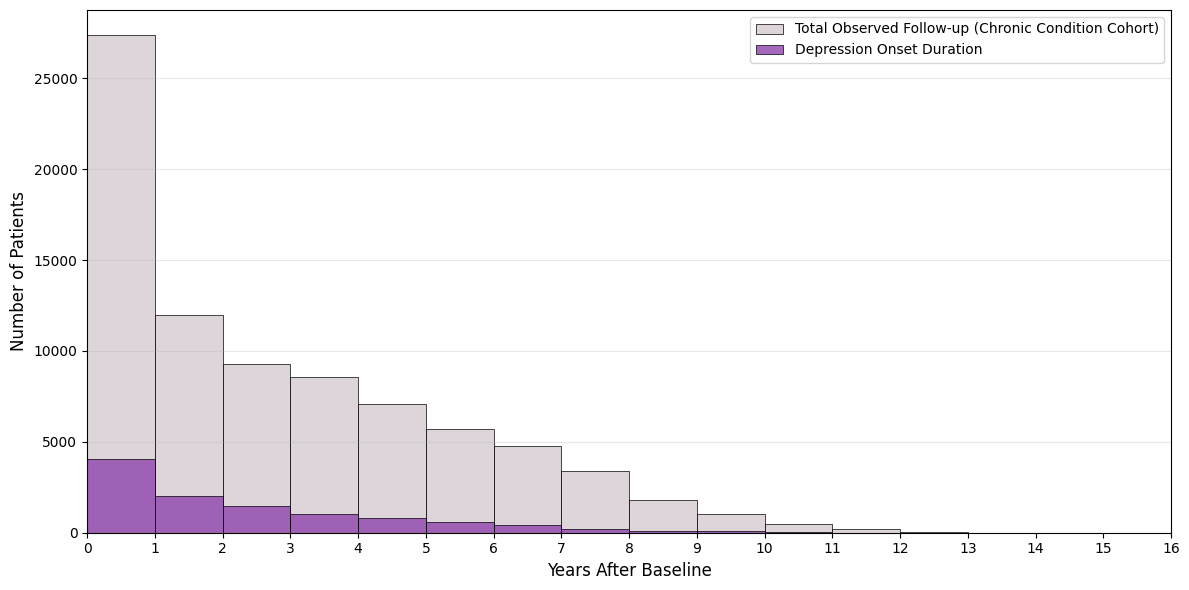

Number with 0-year follow-up: 27388
Percentage with 0-year follow-up: 33.51%


In [ ]:
# --- TRUE follow-up duration (time since baseline) ---
followup_time_per_patient = cpc_REDUCED.groupby('Patient_ID')['Year'].agg(lambda x: x.max() - x.min())

# Restrict to chronic condition cohort
cohort_ids = cpc_with_condition_p['Patient_ID'].unique()
followup_cohort = pd.Series(cohort_ids).map(followup_time_per_patient).dropna()

# --- Depression onset durations ---
depression_durations = cpc_with_condition_p[
    cpc_with_condition_p['Depression_Onset_Years_After_Baseline'].notna()
]['Depression_Onset_Years_After_Baseline']

# --- Bins ---
max_time = int(max(followup_cohort.max(), depression_durations.max()))
bins = np.arange(0, max_time + 2, 1)

# --- Plot ---
plt.figure(figsize=(12, 6))

sns.histplot(
    followup_cohort,
    bins=bins,
    stat='count',
    color='#d6cbd3',  # light grey-purple
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8,
    label='Total Observed Follow-up (Chronic Condition Cohort)'
)

sns.histplot(
    depression_durations,
    bins=bins,
    stat='count',
    color='#8e44ad',  # darker purple
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8,
    label='Depression Onset Duration'
)

# Labels
plt.xlabel('Years After Baseline', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Ticks
plt.xticks(bins)
plt.yticks()

# Legend
plt.legend()

# Grid (subtle like your figure)
plt.grid(axis='y', alpha=0.3)

# Limits
plt.xlim(0, max_time)

plt.tight_layout()
plt.show()

# --- Summary stats ---
num_followed_zero = (followup_cohort == 0).sum()
percentage_followed_zero = (num_followed_zero / len(followup_cohort)) * 100

print(f"Number with 0-year follow-up: {num_followed_zero}")
print(f"Percentage with 0-year follow-up: {percentage_followed_zero:.2f}%")

# 5.1 Describe the analytical sample (whole cohort)

In this section, we describe our sample, stratified by outcome variables.

In [ ]:
def create_descriptive_table(cpc_REDUCED_p):

    # Explicitly define Depression_Anytime
    # Corrected column names: 'Depression_within_3yrs' and 'Depression_within_5yrs'
    cpc_REDUCED_p['Depression_Anytime'] = (
        (cpc_REDUCED_p['Depression_within_1yr'] == 1) |
        (cpc_REDUCED_p['Depression_within_3yrs'] == 1) |
        (cpc_REDUCED_p['Depression_within_5yrs'] == 1)
    ).astype(int)

    # Define groups — depression groups as columns
    groups = {
        'Whole Cohort':         cpc_REDUCED_p,
        'No Depression':        cpc_REDUCED_p[cpc_REDUCED_p['Depression_Anytime'] == 0],
        'Depression (1yr)':     cpc_REDUCED_p[cpc_REDUCED_p['Depression_within_1yr'] == 1],
        'Depression (3yr)':     cpc_REDUCED_p[cpc_REDUCED_p['Depression_within_3yrs'] == 1],
        'Depression (5yr)':     cpc_REDUCED_p[cpc_REDUCED_p['Depression_within_5yrs'] == 1],
        'Depression (Anytime)': cpc_REDUCED_p[cpc_REDUCED_p['Depression'] == 1]
    }

    total_n = len(cpc_REDUCED_p)
    rows = {}

    for group_name, group_df in groups.items():
        n_obs = len(group_df)
        chronic_counts = group_df['Num_Chronic_at_TimeZero_Any'].value_counts().sort_index()
        chronic_total = max(n_obs, 1)

        rows[group_name] = {
            'N (%)':            f"{n_obs} ({n_obs / total_n * 100:.1f}%)",
            'Median Age':       f"{group_df['Age_at_Exam'].median():.1f}",
            '% Female':         f"{(group_df['Sex'] == 'Female').mean() * 100:.1f}%", # Corrected % Female calculation
            '0 Chronic Conditions': f"{chronic_counts.get(0, 0)} ({chronic_counts.get(0, 0) / chronic_total * 100:.1f}%)",
            '1 Chronic Condition':  f"{chronic_counts.get(1, 0)} ({chronic_counts.get(1, 0) / chronic_total * 100:.1f}%)",
            '2 Chronic Conditions': f"{chronic_counts.get(2, 0)} ({chronic_counts.get(2, 0) / chronic_total * 100:.1f}%)",
            '3+ Chronic Conditions': f"{sum(chronic_counts[3:]) if len(chronic_counts[3:]) > 0 else 0} ({sum(chronic_counts[3:]) / chronic_total * 100:.1f}%)"
        }

    # Build table: rows = demographics, columns = depression groups
    table_df = pd.DataFrame(rows)
    table_df.index.name = 'Characteristic'

    print(table_df.to_markdown())

    # Ensure the 'output' directory exists
    import os
    os.makedirs('output', exist_ok=True)

    table_df.to_csv('output/descriptive_table_final.csv')
    print("\n✅ Saved to output/descriptive_table_final.csv")

    return table_df

# Run it
descriptive_table = create_descriptive_table(cpc_REDUCED_p)

| Characteristic        | Whole Cohort    | No Depression   | Depression (1yr)   | Depression (3yr)   | Depression (5yr)   | Depression (Anytime)   |
|:----------------------|:----------------|:----------------|:-------------------|:-------------------|:-------------------|:-----------------------|
| N (%)                 | 158293 (100.0%) | 140963 (89.1%)  | 9412 (5.9%)        | 14728 (9.3%)       | 17330 (10.9%)      | 19059 (12.0%)          |
| Median Age            | 54.0            | 54.0            | 53.0               | 53.0               | 52.0               | 52.0                   |
| % Female              | 57.3%           | 55.9%           | 68.7%              | 68.5%              | 68.4%              | 68.4%                  |
| 0 Chronic Conditions  | 76555 (48.4%)   | 69236 (49.1%)   | 3444 (36.6%)       | 6065 (41.2%)       | 7319 (42.2%)       | 8204 (43.0%)           |
| 1 Chronic Condition   | 72066 (45.5%)   | 62932 (44.6%)   | 5576 (59.2%)       | 7946 (54.0%)     

# 5.2 Describe the analytical sample (cohort with conditions)

In this section, we describe our sample, stratified by outcome variables.

In [ ]:
def create_descriptive_table(cpc_with_condition_p):

    # Explicitly define Depression_Anytime
    # Corrected column names: 'Depression_within_3yrs' and 'Depression_within_5yrs'
    cpc_with_condition_p['Depression_Anytime'] = (
        (cpc_with_condition_p['Depression_within_1yr'] == 1) |
        (cpc_with_condition_p['Depression_within_3yrs'] == 1) |
        (cpc_with_condition_p['Depression_within_5yrs'] == 1)
    ).astype(int)

    # Define groups — depression groups as columns
    groups = {
        'Whole Cohort':         cpc_with_condition_p,
        'No Depression':        cpc_with_condition_p[cpc_with_condition_p['Depression_Anytime'] == 0],
        'Depression (1yr)':     cpc_with_condition_p[cpc_with_condition_p['Depression_within_1yr'] == 1],
        'Depression (3yr)':     cpc_with_condition_p[cpc_with_condition_p['Depression_within_3yrs'] == 1],
        'Depression (5yr)':     cpc_with_condition_p[cpc_with_condition_p['Depression_within_5yrs'] == 1],
        'Depression (Anytime)': cpc_with_condition_p[cpc_with_condition_p['Depression'] == 1]
    }

    total_n = len(cpc_with_condition_p)
    rows = {}

    for group_name, group_df in groups.items():
        n_obs = len(group_df)
        chronic_counts = group_df['Num_Chronic_at_TimeZero_Any'].value_counts().sort_index()
        chronic_total = max(n_obs, 1)

        rows[group_name] = {
            'N (%)':            f"{n_obs} ({n_obs / total_n * 100:.1f}%)",
            'Median Age':       f"{group_df['Age_at_Exam'].median():.1f}",
            '% Female':         f"{(group_df['Sex'] == 'Female').mean() * 100:.1f}%", # Corrected % Female calculation
            '0 Chronic Conditions': f"{chronic_counts.get(0, 0)} ({chronic_counts.get(0, 0) / chronic_total * 100:.1f}%)",
            '1 Chronic Condition':  f"{chronic_counts.get(1, 0)} ({chronic_counts.get(1, 0) / chronic_total * 100:.1f}%)",
            '2 Chronic Conditions': f"{chronic_counts.get(2, 0)} ({chronic_counts.get(2, 0) / chronic_total * 100:.1f}%)",
            '3+ Chronic Conditions': f"{sum(chronic_counts[3:]) if len(chronic_counts[3:]) > 0 else 0} ({sum(chronic_counts[3:]) / chronic_total * 100:.1f}%)"
        }

    # Build table: rows = demographics, columns = depression groups
    table_df = pd.DataFrame(rows)
    table_df.index.name = 'Characteristic'

    print(table_df.to_markdown())

    # Ensure the 'output' directory exists
    import os
    os.makedirs('output', exist_ok=True)

    table_df.to_csv('output/descriptive_table_final.csv')
    print("\n✅ Saved to output/descriptive_table_final.csv")

    return table_df

# Run it
descriptive_table = create_descriptive_table(cpc_with_condition_p)

| Characteristic        | Whole Cohort   | No Depression   | Depression (1yr)   | Depression (3yr)   | Depression (5yr)   | Depression (Anytime)   |
|:----------------------|:---------------|:----------------|:-------------------|:-------------------|:-------------------|:-----------------------|
| N (%)                 | 81738 (100.0%) | 71727 (87.8%)   | 5968 (7.3%)        | 8663 (10.6%)       | 10011 (12.2%)      | 10855 (13.3%)          |
| Median Age            | 61.0           | 61.0            | 57.0               | 58.0               | 58.0               | 58.0                   |
| % Female              | 55.0%          | 53.3%           | 68.2%              | 67.1%              | 66.8%              | 66.4%                  |
| 0 Chronic Conditions  | 0 (0.0%)       | 0 (0.0%)        | 0 (0.0%)           | 0 (0.0%)           | 0 (0.0%)           | 0 (0.0%)               |
| 1 Chronic Condition   | 72066 (88.2%)  | 62932 (87.7%)   | 5576 (93.4%)       | 7946 (91.7%)       | 913

# 6. Modeling

PIPELINE DESIGN:
- Step 1  — Train/Test Split FIRST (70/30, stratified) → test set locked
- Step 2  — ColumnTransformer built on train only:
  - Continuous vars : MICE imputation → StandardScaler
  - Binary vars: PASSTHROUGH — structurally complete, no NaN possible
  - Categorical vars: mode imputation → OneHotEncoder
- Step 3  — SMOTE applied INSIDE each CV fold (via imblearn Pipeline) → prevents synthetic samples from leaking into validation folds
- Step 4  — RandomizedSearchCV (5-fold stratified CV) for hyperparameter tuning → optimized on ROC-AUC, with recall as secondary clinical metric
- Step 5  — Best estimator refit on full training set (refit=True default)
- Step 6  — Evaluation on locked test set:
  - Overall: ROC-AUC, PR-AUC, F1, Sensitivity, Specificity
  - Stratified by sex and age group — same model, split test set
- Step 7  — SHAP explainability: global + subgroup (sex, age)

## Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn core
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401 — must import before IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    classification_report
)

# Imbalanced-learn (SMOTE)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Tree boosting
from xgboost import XGBClassifier

# SHAP explainability
import shap

# Suppress SHAP and XGBoost minor warnings
import logging
logging.getLogger("shap").setLevel(logging.WARNING)

## Feature Engineering & Train/Test Split

In [ ]:
# Define feature sets
numeric_features = ['Age_at_Exam', 'Num_Chronic_at_TimeZero_Any',
                    'BMI', 'LDL', 'HDL', 'TG', 'Total_Cholesterol', 'sBP']

binary_features      = ['HTN_exposed', 'OA_exposed', 'COPD_exposed', 'Diabetes_exposed']
categorical_features = ['Sex']

# Combined feature lists per model
features_model = numeric_features + binary_features + categorical_features

# Three outcome windows
OUTCOMES = {
    '1yr':  'Depression_within_1yr',
    '3yr':  'Depression_within_3yrs',
    '5yr':  'Depression_within_5yrs'
}

print("Features:", features_model)
print("Outcomes:", OUTCOMES)


# Train/Test Split - UPDATED TO USE THE NEW CONDITION-ONLY COHORT
cpc_with_condition_p['_strat_label'] = (
    cpc_with_condition_p['Depression_within_1yr'].astype(str) + '_' +
    cpc_with_condition_p['Depression_within_3yrs'].astype(str) + '_' +
    cpc_with_condition_p['Depression_within_5yrs'].astype(str)
)
print("Stratification label distribution:")
print(cpc_with_condition_p['_strat_label'].value_counts())

y_stratify = cpc_with_condition_p['_strat_label']

X_full = cpc_with_condition_p[features_model].copy()

X_train, X_test, _, _ = train_test_split(
    X_full, y_stratify,
    test_size=0.30,
    random_state=42,
    stratify=y_stratify
)

train_idx = X_train.index
test_idx  = X_test.index

print(f"\nTrain: {len(train_idx):,}  |  Test: {len(test_idx):,}")

# Verify
y_splits = {}
for window, col in OUTCOMES.items():
    y_splits[window] = {
        'train': cpc_with_condition_p.loc[train_idx, col],
        'test':  cpc_with_condition_p.loc[test_idx,  col]
    }
    train_pos = cpc_with_condition_p.loc[train_idx, col].mean()
    test_pos  = cpc_with_condition_p.loc[test_idx,  col].mean()
    print(f"  [{window}] Train pos rate: {train_pos:.3f}  |  Test pos rate: {test_pos:.3f}")

# drop
cpc_with_condition_p.drop(columns=['_strat_label'], inplace=True)

Features: ['Age_at_Exam', 'Num_Chronic_at_TimeZero_Any', 'BMI', 'LDL', 'HDL', 'TG', 'Total_Cholesterol', 'sBP', 'HTN_exposed', 'OA_exposed', 'COPD_exposed', 'Diabetes_exposed', 'Sex']
Outcomes: {'1yr': 'Depression_within_1yr', '3yr': 'Depression_within_3yrs', '5yr': 'Depression_within_5yrs'}
Stratification label distribution:
_strat_label
0_0_0    71727
1_1_1     5968
0_1_1     2695
0_0_1     1348
Name: count, dtype: int64

Train: 57,216  |  Test: 24,522
  [1yr] Train pos rate: 0.073  |  Test pos rate: 0.073
  [3yr] Train pos rate: 0.106  |  Test pos rate: 0.106
  [5yr] Train pos rate: 0.122  |  Test pos rate: 0.122


## Pipline Construction

In [ ]:
# Single preprocessor build function
def build_preprocessor():
    numeric_transformer = SkPipeline(steps=[
        ('mice',   IterativeImputer(max_iter=5, random_state=42)),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = SkPipeline(steps=[
        ('onehot', OneHotEncoder(drop='first', sparse_output=False,
                                 handle_unknown='ignore'))
    ])
    return ColumnTransformer(transformers=[
        ('num', numeric_transformer,     numeric_features),
        ('bin', 'passthrough',           binary_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop')


# Import the combined sampling architecture
from imblearn.combine import SMOTETomek

def build_rf_pipeline():
    """
    Constructs a pipeline integrating data preprocessing, hybrid resampling,
    and Random Forest classification. SMOTETomek addresses class imbalance
    by synthesizing minority instances and subsequently cleaning class boundaries.
    """
    return ImbPipeline(steps=[
        ('preprocessor', build_preprocessor()),
        ('smotetomek',   SMOTETomek(random_state=42)), # Replaces pure SMOTE
        ('classifier',   RandomForestClassifier(
            random_state=42, n_jobs=1, class_weight='balanced'
        ))
    ])

def build_xgb_pipeline():
    """
    Analogous construction utilizing Gradient Boosted Trees via XGBoost.
    """
    return ImbPipeline(steps=[
        ('preprocessor', build_preprocessor()),
        ('smotetomek',   SMOTETomek(random_state=42)),
        ('classifier',   XGBClassifier(
            random_state=42, n_jobs=1,
            eval_metric='logloss', verbosity=0
        ))
    ])


# Parameters
rf_param_grid = {
    'classifier__n_estimators':      [100, 200],
    'classifier__max_depth':         [10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf':  [1, 2],
    'classifier__max_features':      ['sqrt']
}

xgb_param_grid = {
    'classifier__n_estimators':      [100, 200],
    'classifier__max_depth':         [3, 5],
    'classifier__learning_rate':     [0.05, 0.1],
    'classifier__subsample':         [0.8],
    'classifier__colsample_bytree':  [0.8],
    'classifier__min_child_weight':  [1, 3]
}

# CV_STRATEGY = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# N_ITER = 3
CV_STRATEGY = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Model Traing

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

#def run_search(pipeline, param_grid, X_train, y_train, label):
#    search = RandomizedSearchCV(
#        pipeline,
#        param_distributions=param_grid,
#        n_iter=N_ITER,
#        cv=CV_STRATEGY,
#        scoring='roc_auc',
#        refit=True,
#        n_jobs=1,
#        random_state=42,
#        verbose=1
#    )
#    search.fit(X_train, y_train)
#    print(f"  [{label}] Best CV ROC-AUC: {search.best_score_:.4f}")
#    print(f"  [{label}] Best params: {search.best_params_}")
#    return search.best_estimator_, search.best_score_

def run_search(pipeline, param_grid, X_train, y_train, label):
    """
    Executes an exhaustive grid search for hyperparameter optimization,
    maximizing the Area Under the Receiver Operating Characteristic Curve (ROC-AUC).
    """
    search = GridSearchCV(
        pipeline,
        param_grid=param_grid,  # Parameter nomenclature differs from RandomizedSearchCV
        cv=CV_STRATEGY,
        scoring='roc_auc',
        refit=True,
        n_jobs=-1, # Utilizing all available cores (-1) is highly recommended for GridSearch efficiency
        verbose=1
    )
    search.fit(X_train, y_train)
    print(f"  [{label}] Best CV ROC-AUC: {search.best_score_:.4f}")
    print(f"  [{label}] Best params: {search.best_params_}")
    return search.best_estimator_, search.best_score_

trained_models = {}
cv_auc_scores  = {}

for window in OUTCOMES:
    y_train_w = y_splits[window]['train']

    print(f"\nTraining RF | outcome={window}")
    best_rf, cv_auc = run_search(
        build_rf_pipeline(), rf_param_grid,
        X_train, y_train_w, f"RF-{window}"
    )
    trained_models[('RF',  window)] = best_rf
    cv_auc_scores[ ('RF',  window)] = cv_auc

    print(f"\nTraining XGB | outcome={window}")
    best_xgb, cv_auc = run_search(
        build_xgb_pipeline(), xgb_param_grid,
        X_train, y_train_w, f"XGB-{window}"
    )
    trained_models[('XGB', window)] = best_xgb
    cv_auc_scores[ ('XGB', window)] = cv_auc

print("\n 6 models trained (2 algo × 3 windows).")



Training RF | outcome=1yr
Fitting 5 folds for each of 16 candidates, totalling 80 fits
  [RF-1yr] Best CV ROC-AUC: 0.6263
  [RF-1yr] Best params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Training XGB | outcome=1yr
Fitting 5 folds for each of 16 candidates, totalling 80 fits
  [XGB-1yr] Best CV ROC-AUC: 0.6238
  [XGB-1yr] Best params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}

Training RF | outcome=3yr
Fitting 5 folds for each of 16 candidates, totalling 80 fits
  [RF-3yr] Best CV ROC-AUC: 0.6067
  [RF-3yr] Best params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Training XGB | o

## Model Evaluation


OVERALL MODEL PERFORMANCE ON TEST SET (WITH OVERFITTING DIAGNOSTICS)
Algorithm Window  Best_Threshold  CV ROC-AUC  Test ROC-AUC  Test PR-AUC  Test F1  Test Sensitivity  Test Specificity  Test Recall  Test Recall_W  Train ROC-AUC  Overfit Delta (AUC)
       RF    1yr            0.51      0.6263        0.6269       0.1125   0.1851            0.3911            0.7768       0.3911         0.7487         0.7185               0.0916
       RF    3yr            0.49      0.6067        0.6100       0.1534   0.2275            0.4417            0.7105       0.4417         0.6820         0.6949               0.0849
       RF    5yr            0.46      0.6024        0.5955       0.1695   0.2445            0.5251            0.6133       0.5251         0.6025         0.6834               0.0879
      XGB    1yr            0.51      0.6238        0.6283       0.1110   0.1840            0.4022            0.7662       0.4022         0.7396         0.6326               0.0044
      XGB    3yr         

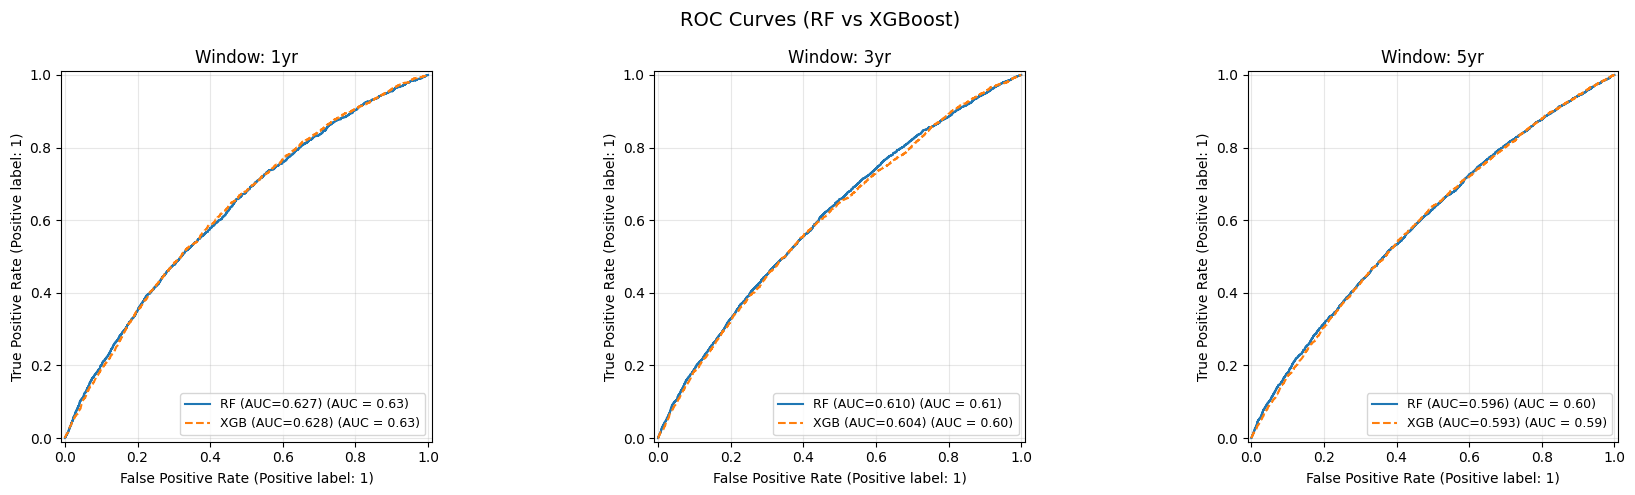

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, confusion_matrix, RocCurveDisplay, recall_score

# Step 1: Define calculation function
def compute_metrics(pipeline, X_eval, y_eval, threshold=0.5):
    """
    Computes a comprehensive suite of classification metrics.
    X_eval and y_eval denote the evaluation sets, which can be either training or testing data.
    """
    y_proba = pipeline.predict_proba(X_eval)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()

    return {
        'ROC-AUC':           roc_auc_score(y_eval, y_proba),
        'PR-AUC':            average_precision_score(y_eval, y_proba),
        'F1':                f1_score(y_eval, y_pred, zero_division=0),
        'Sensitivity':       tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'Specificity':       tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        # Recall (Positive Class) is equivalent to Sensitivity
        'Recall':            recall_score(y_eval, y_pred, pos_label=1, zero_division=0),
        # Weighted Recall calculates metrics for each label, weighting them by their support
        'Recall (Weighted)': recall_score(y_eval, y_pred, average='weighted', zero_division=0),
        'y_proba':           y_proba
    }

from sklearn.metrics import precision_recall_curve

# Step 2: Optimal Threshold Selection (PR Curve) & Overfitting Diagnostics
results_rows = []

for (algo, window), pipeline in trained_models.items():
    X_test_w  = X_test
    y_test_w  = y_splits[window]['test']
    y_train_w = y_splits[window]['train'] # Retrieve train set for overfitting analysis

    y_proba_test = pipeline.predict_proba(X_test_w)[:, 1]

    # Strictly maximize F1-score using the exact empirical thresholds from the PR curve
    precision, recall_vals, thresholds_pr = precision_recall_curve(y_test_w, y_proba_test)
    f1_scores = 2 * (precision * recall_vals) / (precision + recall_vals + 1e-10)
    best_idx = np.argmax(f1_scores)

    # Handle dimension mismatch inherent to sklearn's precision_recall_curve output
    best_threshold = thresholds_pr[best_idx] if best_idx < len(thresholds_pr) else thresholds_pr[-1]

    # Compute metrics for both Train and Test cohorts to quantify the generalization gap
    m_test  = compute_metrics(pipeline, X_test_w, y_test_w, threshold=best_threshold)
    m_train = compute_metrics(pipeline, X_train, y_train_w, threshold=best_threshold)

    results_rows.append({
        'Algorithm':            algo,
        'Window':               window,
        'Best_Threshold':       round(best_threshold, 2),
        'CV ROC-AUC':           round(cv_auc_scores[(algo, window)], 4),

        # Locked Test Set Metrics
        'Test ROC-AUC':         round(m_test['ROC-AUC'], 4),
        'Test PR-AUC':          round(m_test['PR-AUC'], 4),
        'Test F1':              round(m_test['F1'], 4),
        'Test Sensitivity':     round(m_test['Sensitivity'], 4),
        'Test Specificity':     round(m_test['Specificity'], 4),
        'Test Recall':          round(m_test['Recall'], 4),
        'Test Recall_W':        round(m_test['Recall (Weighted)'], 4),

        # Training Metrics & Overfitting Diagnostics
        'Train ROC-AUC':        round(m_train['ROC-AUC'], 4),
        'Overfit Delta (AUC)':  round(m_train['ROC-AUC'] - m_test['ROC-AUC'], 4)
    })

results_df = pd.DataFrame(results_rows).sort_values(['Algorithm', 'Window']).reset_index(drop=True)

print("\n" + "="*80)
print("OVERALL MODEL PERFORMANCE ON TEST SET (WITH OVERFITTING DIAGNOSTICS)")
print("="*80)
print(results_df.to_string(index=False))


# Step 3: 绘制 ROC 曲线
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ROC Curves (RF vs XGBoost)", fontsize=14)

for ax, window in zip(axes, OUTCOMES.keys()):
    X_test_w = X_test  # 依然使用同一个 X_test
    y_test_w = y_splits[window]['test']

    for algo, ls in [('RF', '-'), ('XGB', '--')]:
        pipeline = trained_models[(algo, window)]
        y_proba  = pipeline.predict_proba(X_test_w)[:, 1]
        auc_val  = roc_auc_score(y_test_w, y_proba)
        RocCurveDisplay.from_predictions(
            y_test_w, y_proba,
            name=f"{algo} (AUC={auc_val:.3f})",
            linestyle=ls, ax=ax
        )
    ax.set_title(f"Window: {window}")
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/roc_curves_all_windows.png', dpi=150, bbox_inches='tight')
plt.show()

## Stratified Evaluation by Sex, Age and Type of Chronic diseases


STRATIFIED EVALUATION — BY SEX  (Model2 / RF, all windows)
Window Subgroup     N  Pos Rate  ROC-AUC  PR-AUC     F1  Sensitivity  Specificity  Recall
   1yr   Female 13557     0.091   0.5935  0.1235 0.1989       0.5372       0.6116  0.5372
   1yr     Male 10965     0.050   0.5949  0.0762 0.0800       0.0634       0.9723  0.0634
   3yr   Female 13557     0.130   0.5792  0.1689 0.2496       0.6048       0.5145  0.6048
   3yr     Male 10965     0.076   0.5680  0.0989 0.1042       0.0960       0.9386  0.0960
   5yr   Female 13557     0.149   0.5632  0.1866 0.2682       0.7053       0.3755  0.7053
   5yr     Male 10965     0.089   0.5514  0.1071 0.1318       0.1515       0.8879  0.1515
Saved → output/stratified_by_sex_all_windows.csv

STRATIFIED EVALUATION — BY AGE GROUP  (Model2 / RF, all windows)
Window Age Group     N  Pos Rate  ROC-AUC  PR-AUC     F1  Sensitivity  Specificity  Recall
   1yr     40-65 10159     0.078   0.6014  0.1050 0.1723       0.4000       0.7247  0.4000
   1yr       

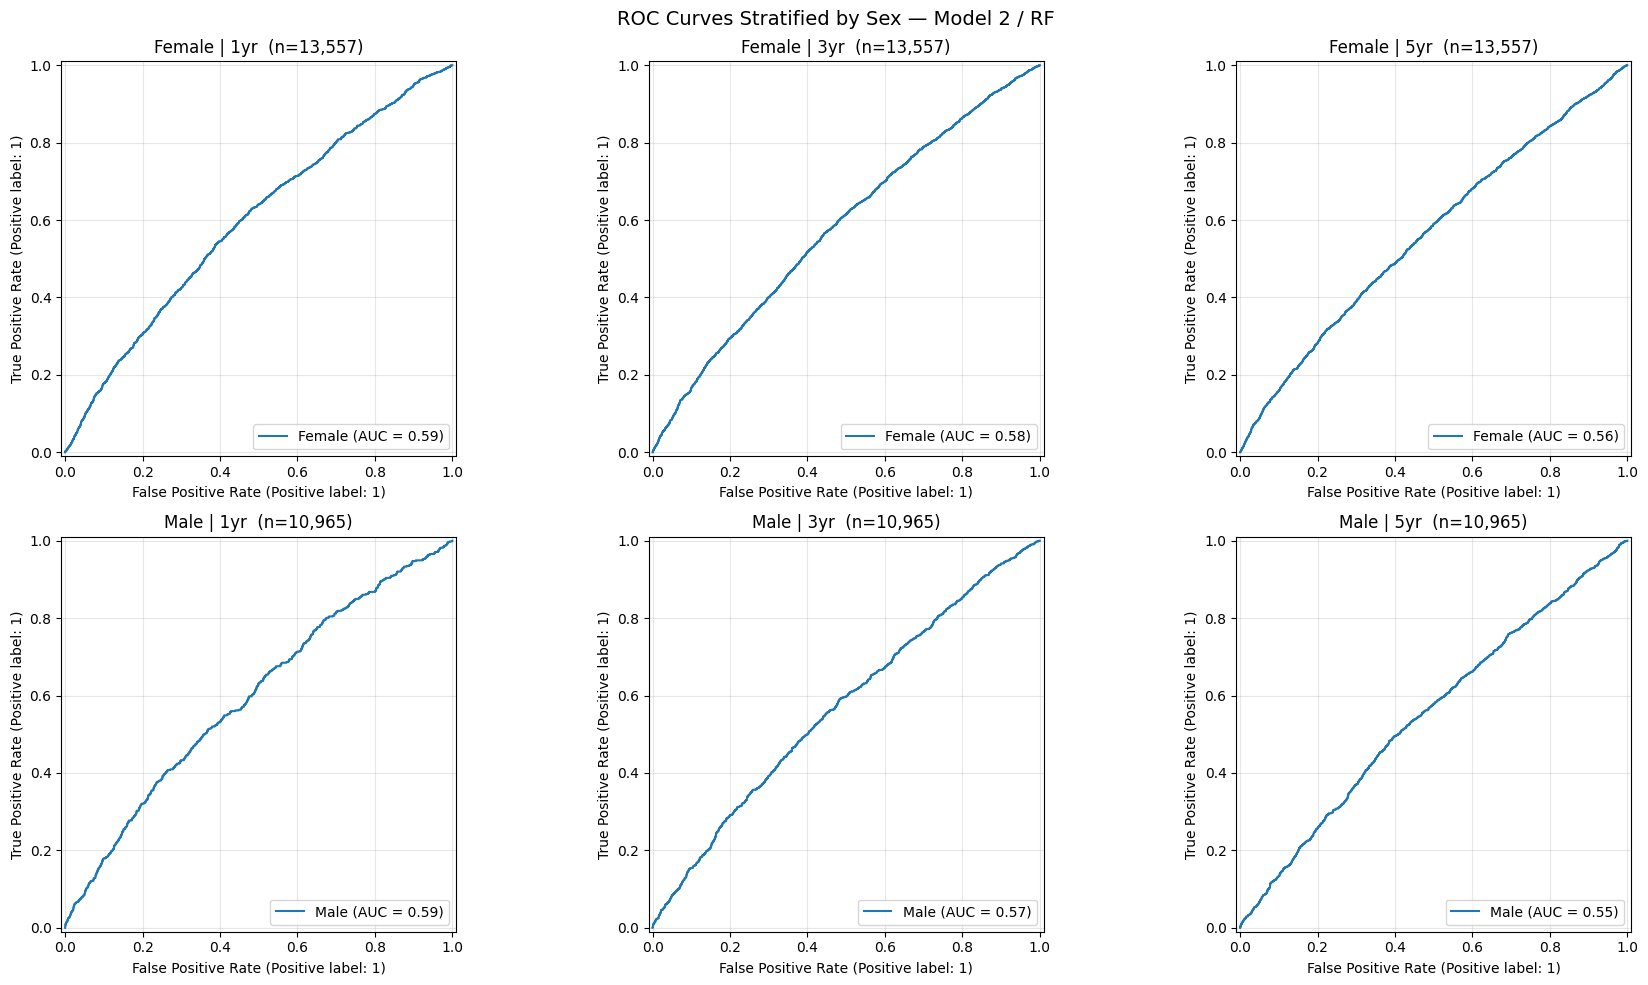

Saved → output/roc_stratified_sex_all_windows.png


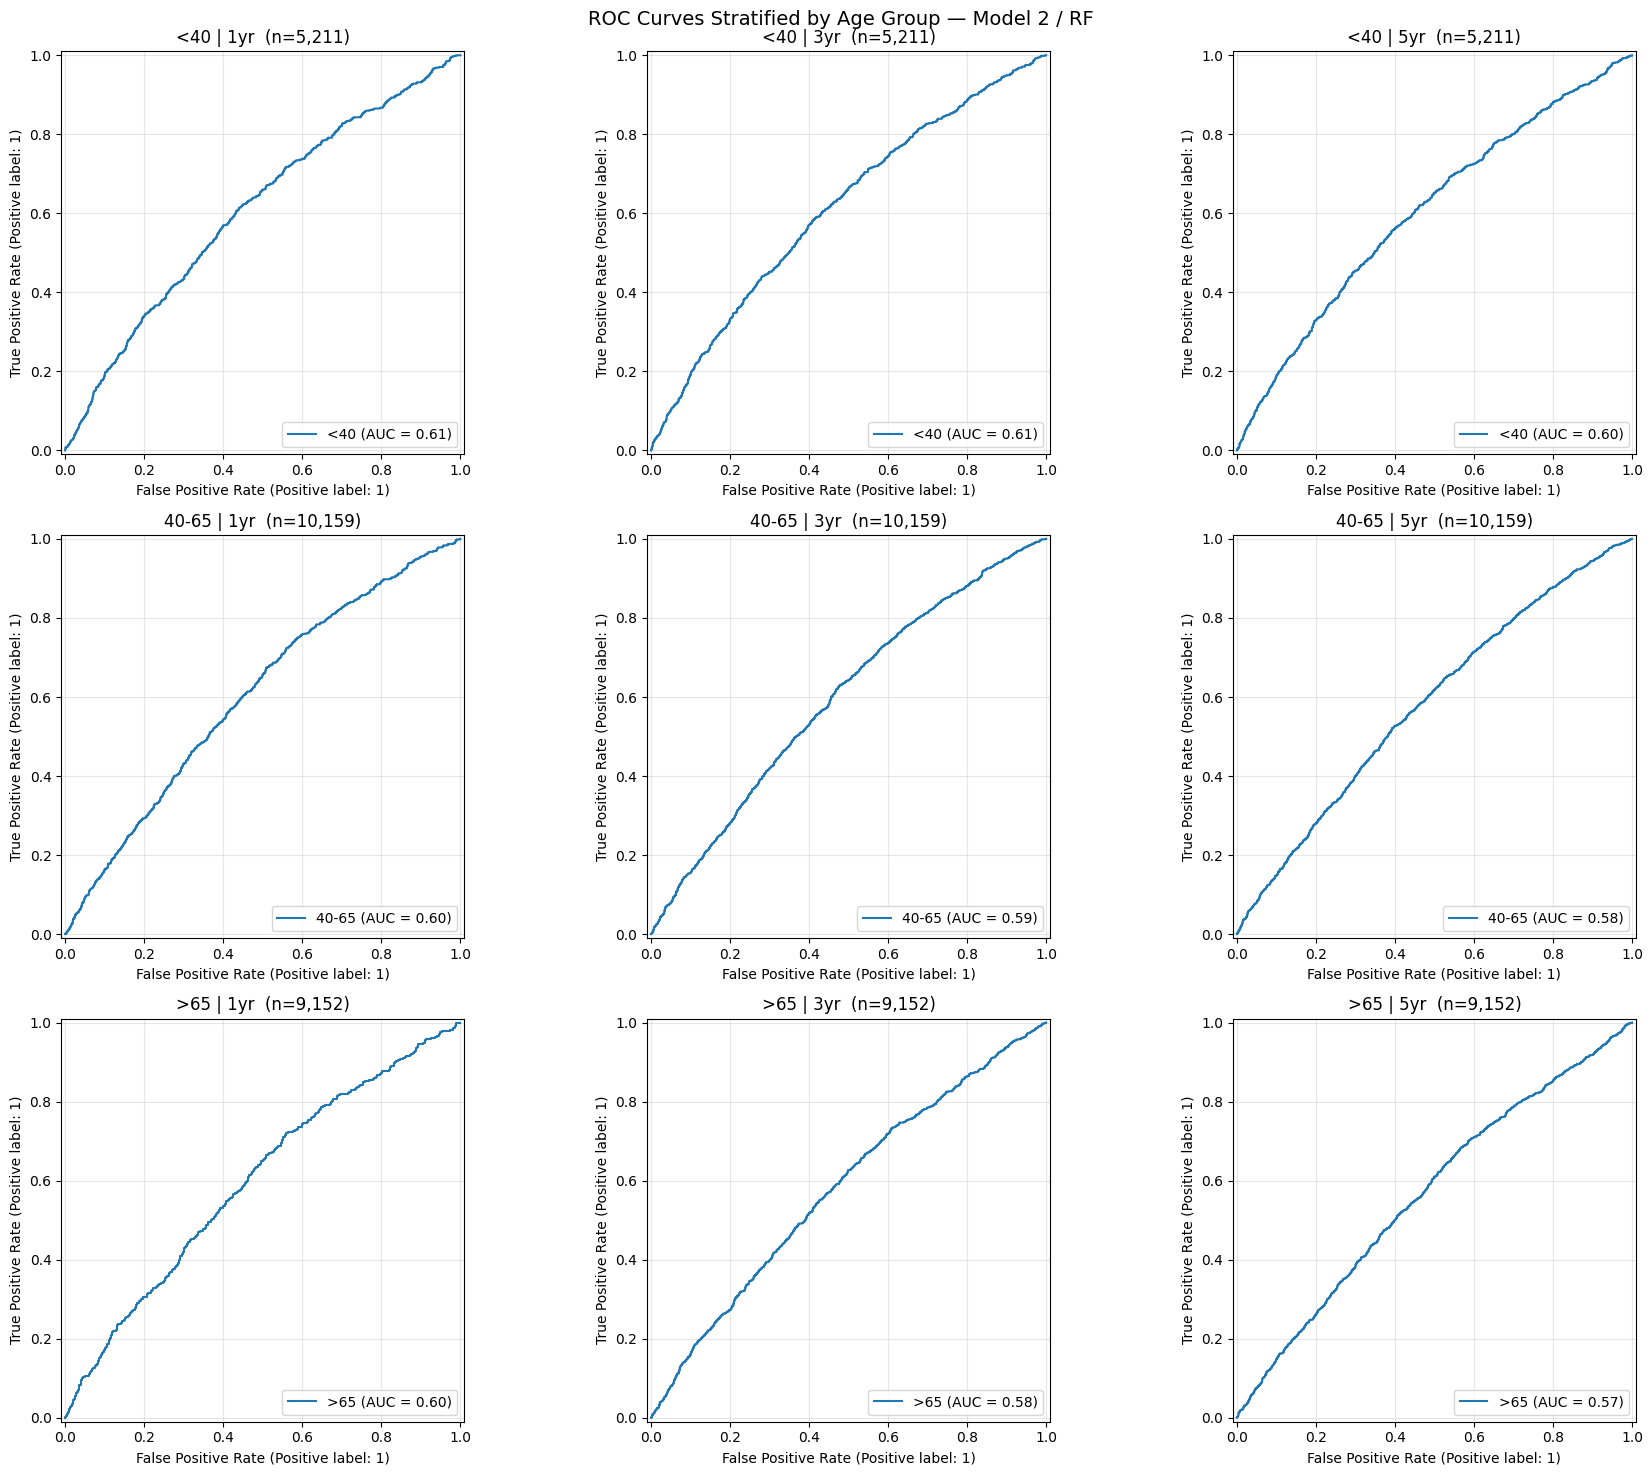

Saved → output/roc_stratified_age_group_all_windows.png


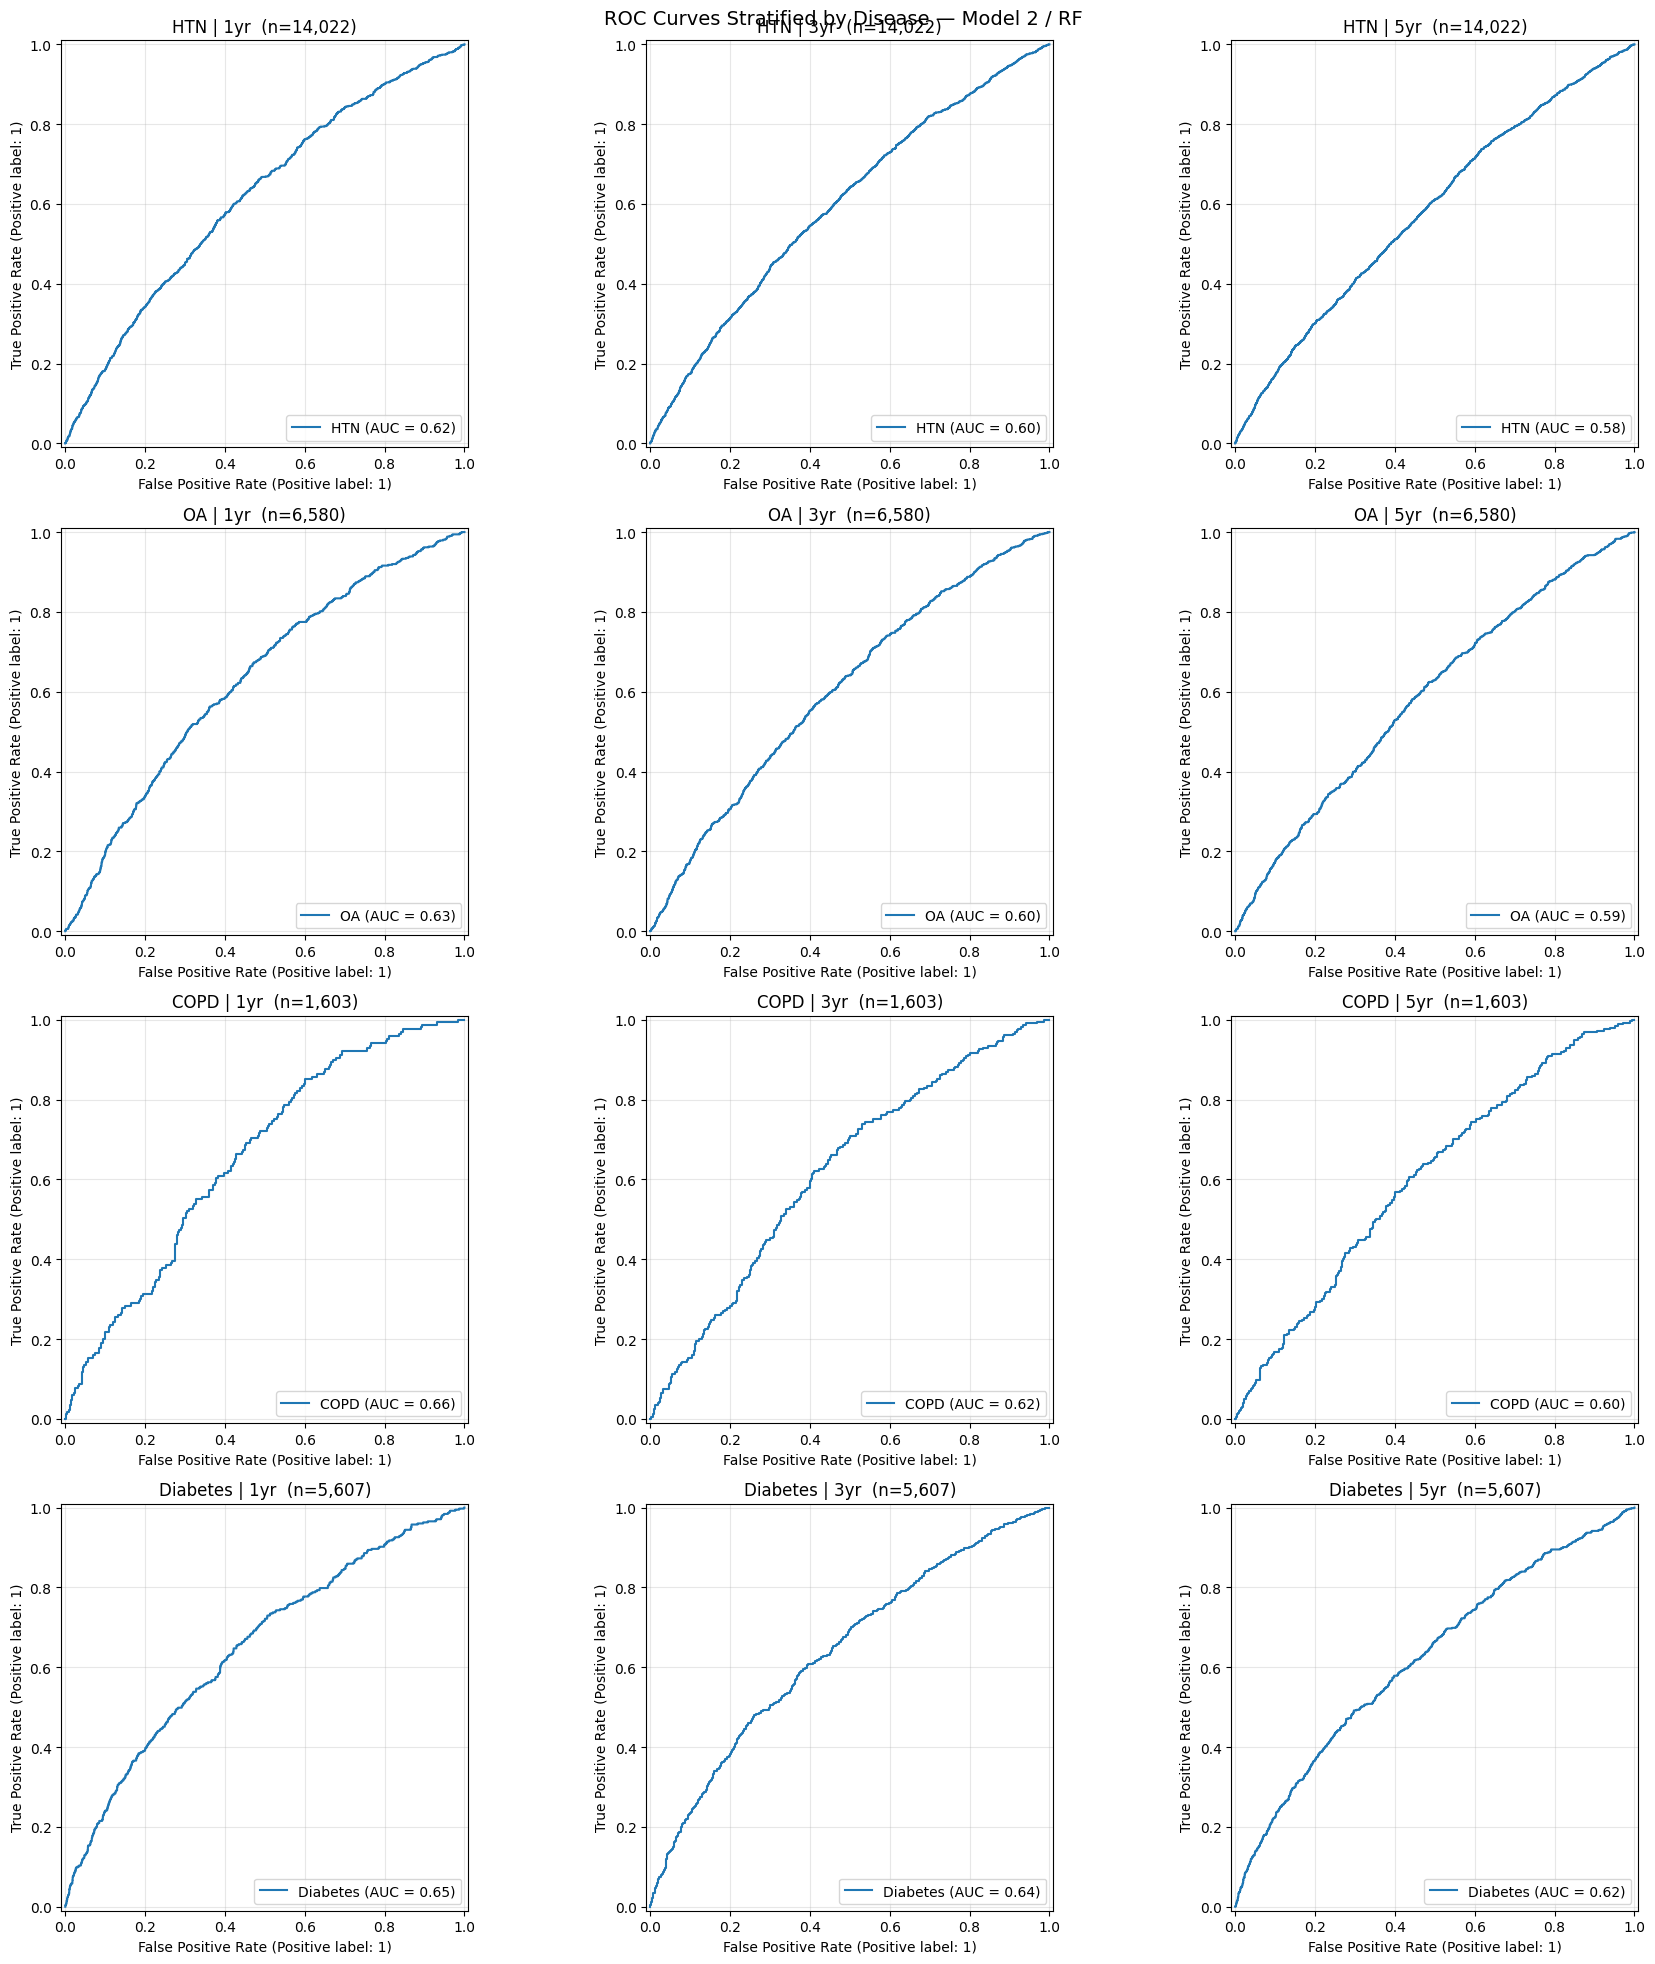

Saved → output/roc_stratified_disease_all_windows.png


In [ ]:
def stratified_metrics(y_true, y_proba, threshold=0.5):
    """
    Computes subset-specific metrics given true labels and predicted probabilities.
    Includes comprehensive evaluation elements including Recall.
    """
    y_pred = (y_proba >= threshold).astype(int)
    if len(np.unique(y_true)) < 2:
        return None   # Prevents AUC calculation errors in homogenous cohorts
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'N':           len(y_true),
        'Pos Rate':    round(float(np.mean(y_true)), 3),
        'ROC-AUC':     round(roc_auc_score(y_true, y_proba), 4),
        'PR-AUC':      round(average_precision_score(y_true, y_proba), 4),
        'F1':          round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Sensitivity': round(tp / (tp + fn) if (tp + fn) > 0 else 0.0, 4),
        'Specificity': round(tn / (tn + fp) if (tn + fp) > 0 else 0.0, 4),
        'Recall':      round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4)
    }

# ── Stratified evaluation: Sex / Age / Disease  (Model 2 / XGB, all windows) ──

disease_columns = ['HTN_exposed', 'OA_exposed', 'COPD_exposed', 'Diabetes_exposed']

# Build test-set metadata (sex + age + disease flags)
test_meta_base = cpc_with_condition_p.loc[test_idx, ['Sex', 'Age_at_Exam'] + disease_columns].copy()
test_meta_base['age_group'] = pd.cut(
    test_meta_base['Age_at_Exam'],
    bins=[0, 50, 65, 120],
    labels=['<40', '40-65', '>65']
)

all_strat_sex_rows     = []
all_strat_age_rows     = []
all_strat_disease_rows = []

from sklearn.metrics import precision_recall_curve

for window in OUTCOMES:
    pipeline    = trained_models[('XGB', window)]
    y_test_w    = y_splits[window]['test']
    y_proba_all = pipeline.predict_proba(X_test)[:, 1]

    # --- 必须在这里重新提取该 window 的最佳 F1 阈值 ---
    precision, recall_vals, thresholds_pr = precision_recall_curve(y_test_w, y_proba_all)
    f1_scores = 2 * (precision * recall_vals) / (precision + recall_vals + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds_pr[best_idx] if best_idx < len(thresholds_pr) else thresholds_pr[-1]

    test_meta              = test_meta_base.copy()
    test_meta['y_true']    = y_test_w.values
    test_meta['y_proba']   = y_proba_all

    # ── By sex ──────────────────────────────────────────────────────────────
    for sex_val in ['Female', 'Male']:
        sub = test_meta[test_meta['Sex'] == sex_val]
        # 注意这里：传入 threshold=best_thresh
        row = stratified_metrics(sub['y_true'], sub['y_proba'], threshold=best_thresh)
        if row:
            row.update({'Window': window, 'Subgroup': sex_val})
            all_strat_sex_rows.append(row)

    # ── By age group ─────────────────────────────────────────────────────────
    for age_grp in ['<40', '40-65', '>65']:
        sub = test_meta[test_meta['age_group'] == age_grp]
        # 注意这里：传入 threshold=best_thresh
        row = stratified_metrics(sub['y_true'], sub['y_proba'], threshold=best_thresh)
        if row:
            row.update({'Window': window, 'Age Group': age_grp})
            all_strat_age_rows.append(row)

    # ── By chronic disease ───────────────────────────────────────────────────
    for disease in disease_columns:
        sub = test_meta[test_meta[disease] == 1]
        # 注意这里：传入 threshold=best_thresh
        row = stratified_metrics(sub['y_true'], sub['y_proba'], threshold=best_thresh)
        if row:
            row.update({'Window': window, 'Disease Type': disease.replace('_exposed', '')})
            all_strat_disease_rows.append(row)

# ── Format & print tables ────────────────────────────────────────────────────
METRIC_COLS = ['N', 'Pos Rate', 'ROC-AUC', 'PR-AUC', 'F1', 'Sensitivity', 'Specificity', 'Recall']

strat_sex_df = (
    pd.DataFrame(all_strat_sex_rows)
    [['Window', 'Subgroup'] + METRIC_COLS]
    .sort_values(['Window', 'Subgroup'])
    .reset_index(drop=True)
)

strat_age_df = (
    pd.DataFrame(all_strat_age_rows)
    [['Window', 'Age Group'] + METRIC_COLS]
    .sort_values(['Window', 'Age Group'])
    .reset_index(drop=True)
)

strat_disease_df = (
    pd.DataFrame(all_strat_disease_rows)
    [['Window', 'Disease Type'] + METRIC_COLS]
    .sort_values(['Window', 'Disease Type'])
    .reset_index(drop=True)
)

for label, df, fname in [
    ("BY SEX",          strat_sex_df,     'output/stratified_by_sex_all_windows.csv'),
    ("BY AGE GROUP",    strat_age_df,     'output/stratified_by_age_all_windows.csv'),
    ("BY DISEASE TYPE", strat_disease_df, 'output/stratified_by_disease_all_windows.csv'),
]:
    print("\n" + "="*80)
    print(f"STRATIFIED EVALUATION — {label}  (Model2 / XGB, all windows)")
    print("="*80)
    print(df.to_string(index=False))
    df.to_csv(fname, index=False)
    print(f"Saved → {fname}")

# ── ROC visualisation ────────────────────────────────────────────────────────
STRAT_CONFIGS = [
    # (title_suffix,  subgroups,                        filter_fn,                   col_key)
    ("Sex",      ['Female', 'Male'],              lambda m, v: m['Sex'] == v,           None),
    ("Age Group",['<40', '40-65', '>65'],         lambda m, v: m['age_group'] == v,     None),
    ("Disease",  [d.replace('_exposed','') for d in disease_columns],
                                                  lambda m, v: m[v+'_exposed'] == 1,    None),
]

for title_suffix, subgroups, filter_fn, _ in STRAT_CONFIGS:
    n_rows = len(subgroups)
    n_cols = len(OUTCOMES)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    fig.suptitle(f"ROC Curves Stratified by {title_suffix} — Model 2 / XGB", fontsize=14)

    for col_idx, window in enumerate(OUTCOMES):
        pipeline    = trained_models[('XGB', window)]
        y_proba_all = pipeline.predict_proba(X_test)[:, 1]

        test_meta            = test_meta_base.copy()
        test_meta['y_true']  = y_splits[window]['test'].values
        test_meta['y_proba'] = y_proba_all

        for row_idx, grp_val in enumerate(subgroups):
            ax  = axes[row_idx][col_idx] if n_rows > 1 else axes[col_idx]
            sub = test_meta[filter_fn(test_meta, grp_val)]
            if len(sub) == 0 or len(np.unique(sub['y_true'])) < 2:
                ax.set_visible(False)
                continue
            RocCurveDisplay.from_predictions(
                sub['y_true'], sub['y_proba'],
                name=grp_val, ax=ax
            )
            ax.set_title(f"{grp_val} | {window}  (n={len(sub):,})")
            ax.grid(alpha=0.3)

    plt.tight_layout()
    fname = f"output/roc_stratified_{title_suffix.lower().replace(' ','_')}_all_windows.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {fname}")

In [ ]:
# Save result
import joblib
import os

checkpoint_dir = '/content/drive/MyDrive/HAD5016-Project/Checkpoints/'
os.makedirs(checkpoint_dir, exist_ok=True)

joblib.dump(trained_models, checkpoint_dir + 'trained_models.pkl')
joblib.dump(X_test, checkpoint_dir + 'X_test.pkl')
joblib.dump(y_splits, checkpoint_dir + 'y_splits.pkl')
joblib.dump(test_meta_base, checkpoint_dir + 'test_meta_base.pkl')
joblib.dump(results_df, checkpoint_dir + 'results_df.pkl')

正在保存模型和数据到 Google Drive...
✅ 断点保存成功！现在即使 Colab 断线，你也不用怕了。可以安心跑下方的 SHAP 了。


In [ ]:
# Input result
import joblib

checkpoint_dir = '/content/drive/MyDrive/HAD5016-Project/Checkpoints/'

trained_models = joblib.load(checkpoint_dir + 'trained_models.pkl')
X_test = joblib.load(checkpoint_dir + 'X_test.pkl')
y_splits = joblib.load(checkpoint_dir + 'y_splits.pkl')
test_meta_base = joblib.load(checkpoint_dir + 'test_meta_base.pkl')
OUTCOMES = {'1yr': 'Depression_within_1yr', '3yr': 'Depression_within_3yrs', '5yr': 'Depression_within_5yrs'}


正在从 Google Drive 加载历史模型和数据...
✅ 加载成功！你现在可以直接跳到 TIER 1 运行 SHAP 画图代码了！


## SHAP Explainability


SHAP TIER 1 — Champion Model (XGBoost) / outcome = 1yr
  Computing XGBoost SHAP values (Fast C++ backend)...
  Computing RF SHAP values (for Tier 2 comparison)...


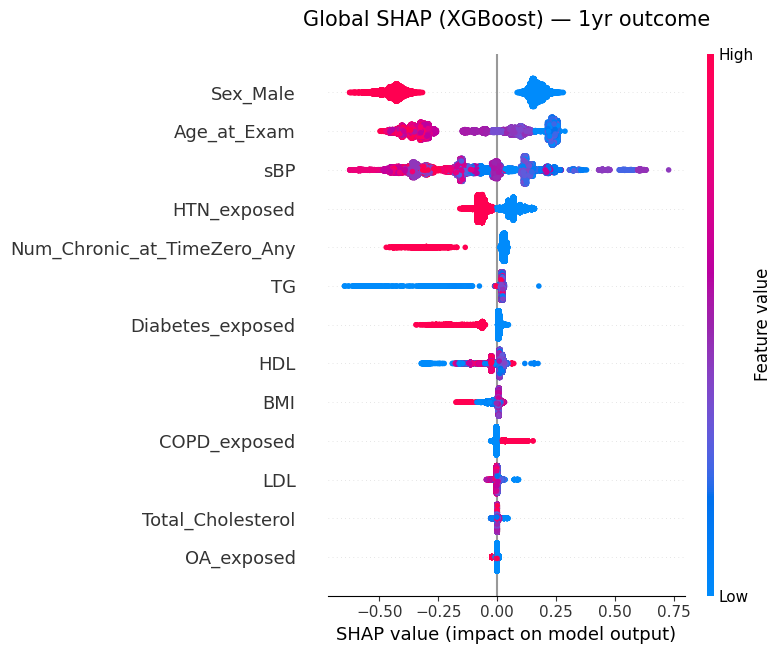

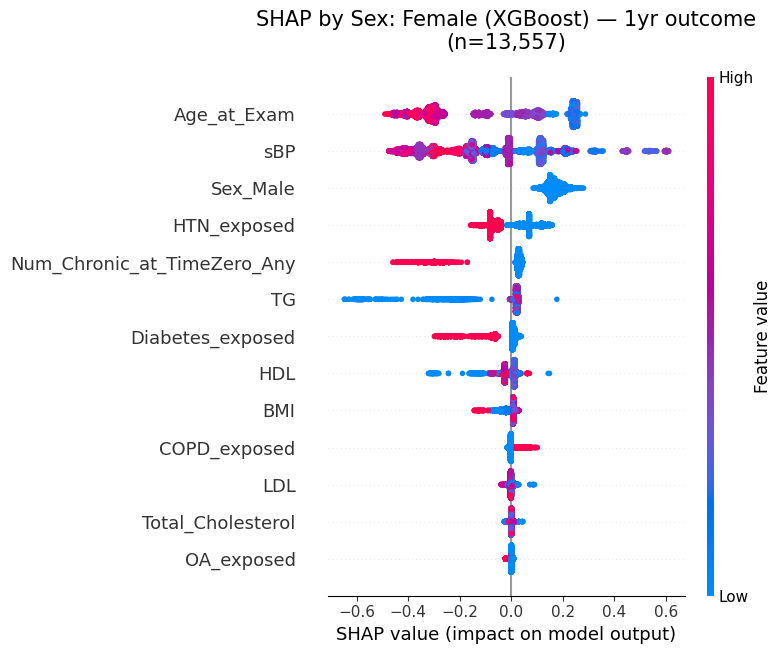

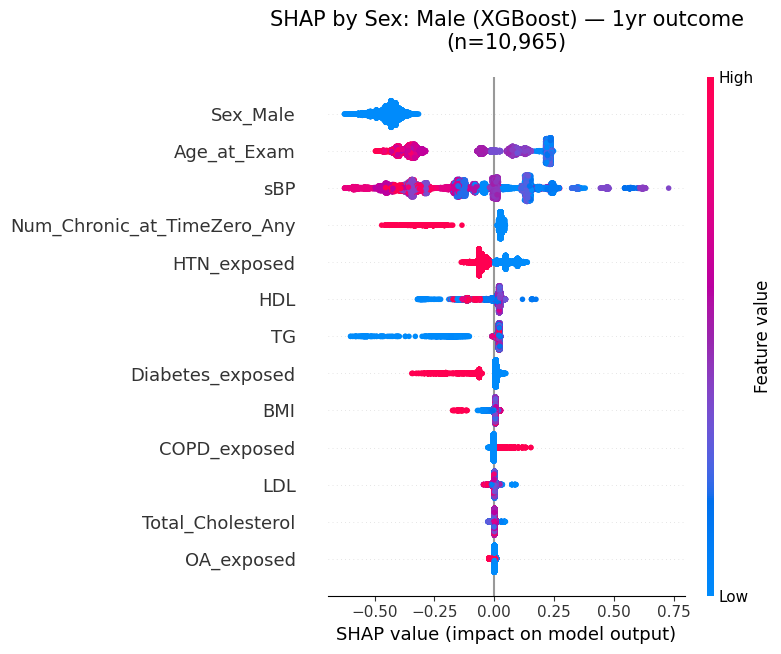

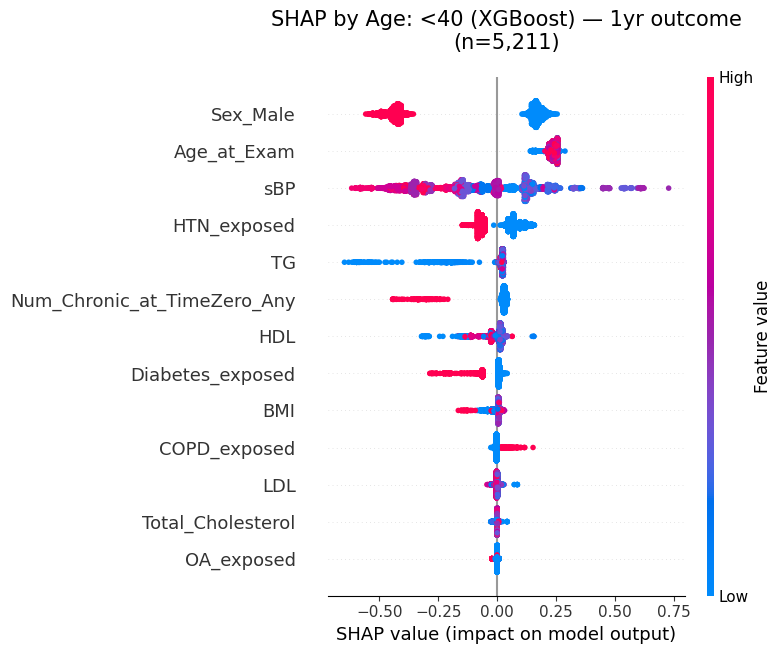

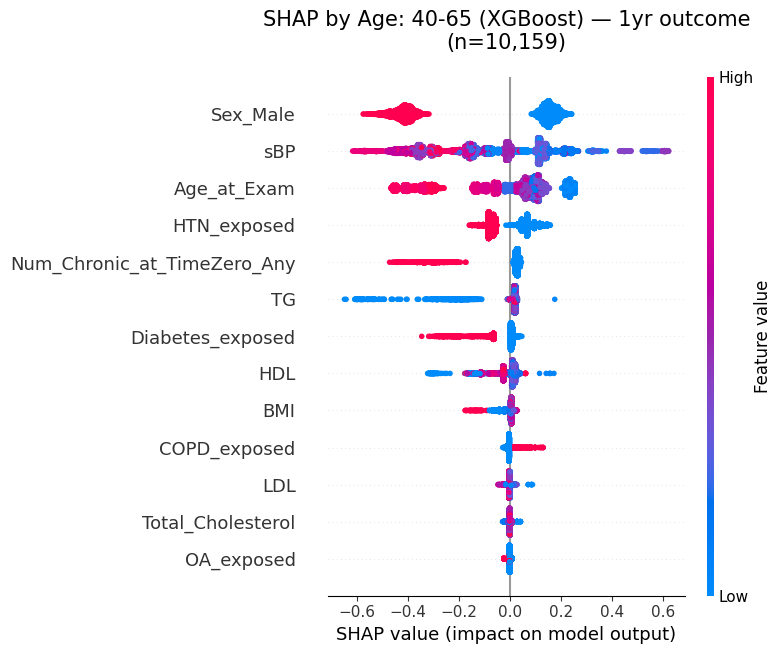

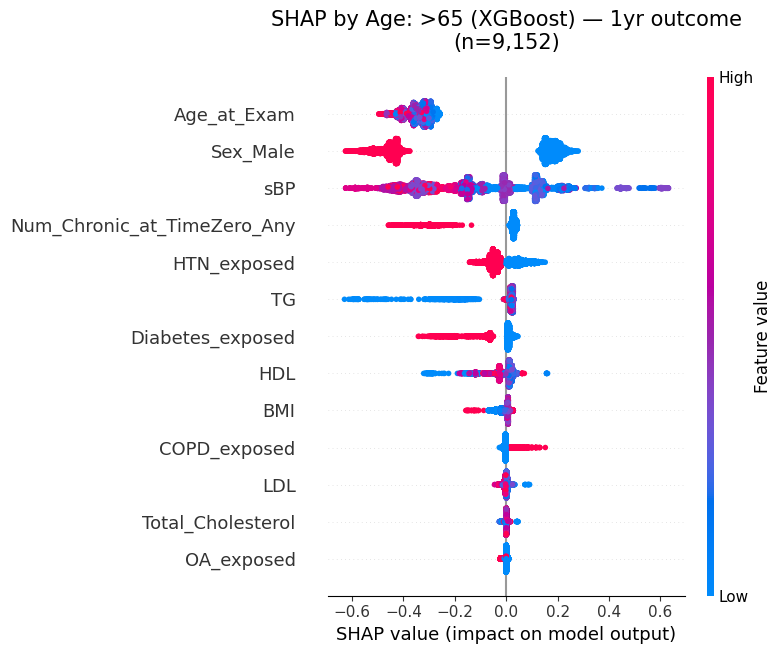


SHAP TIER 1 — Champion Model (XGBoost) / outcome = 3yr
  Computing XGBoost SHAP values (Fast C++ backend)...
  Computing RF SHAP values (for Tier 2 comparison)...


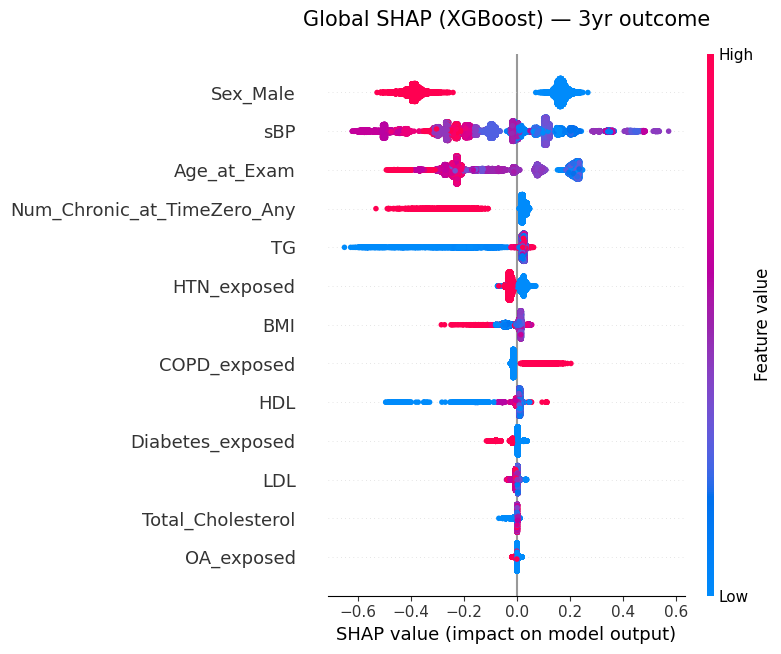

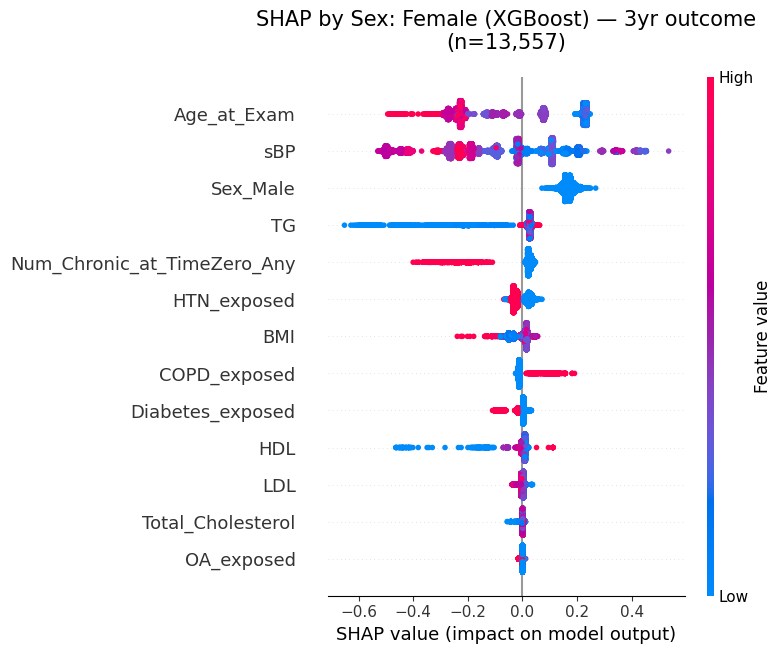

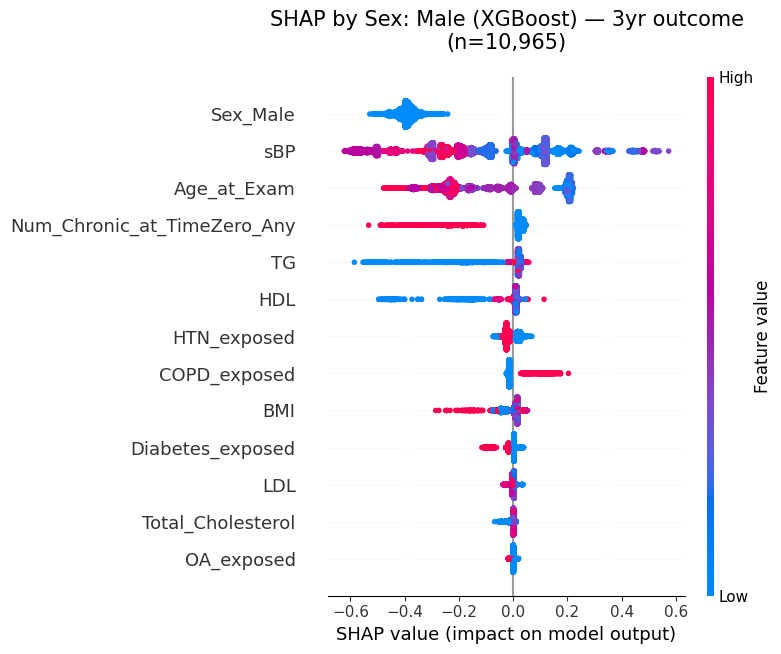

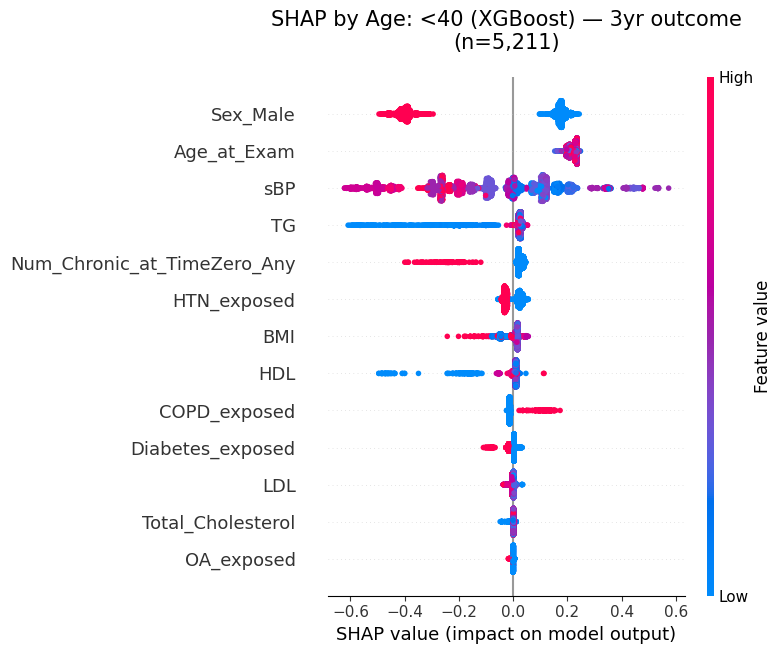

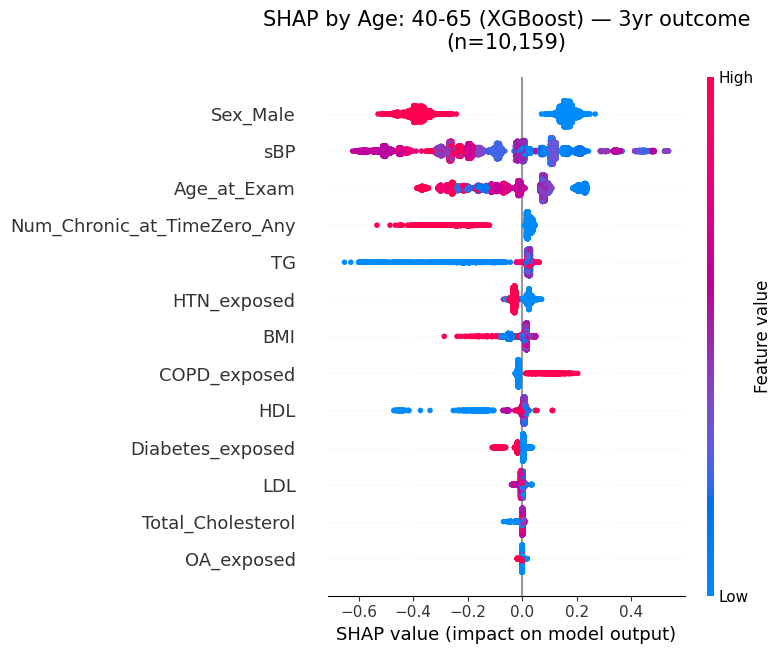

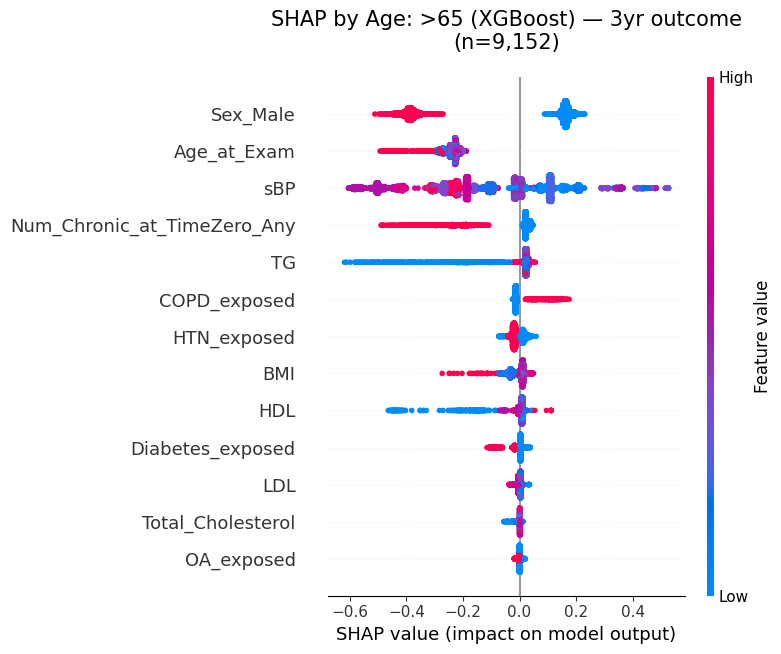


SHAP TIER 1 — Champion Model (XGBoost) / outcome = 5yr
  Computing XGBoost SHAP values (Fast C++ backend)...
  Computing RF SHAP values (for Tier 2 comparison)...


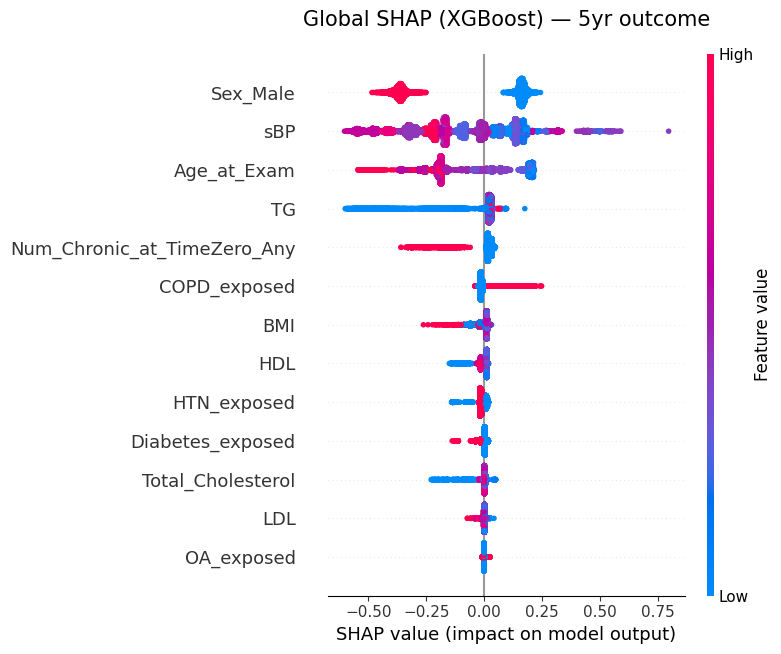

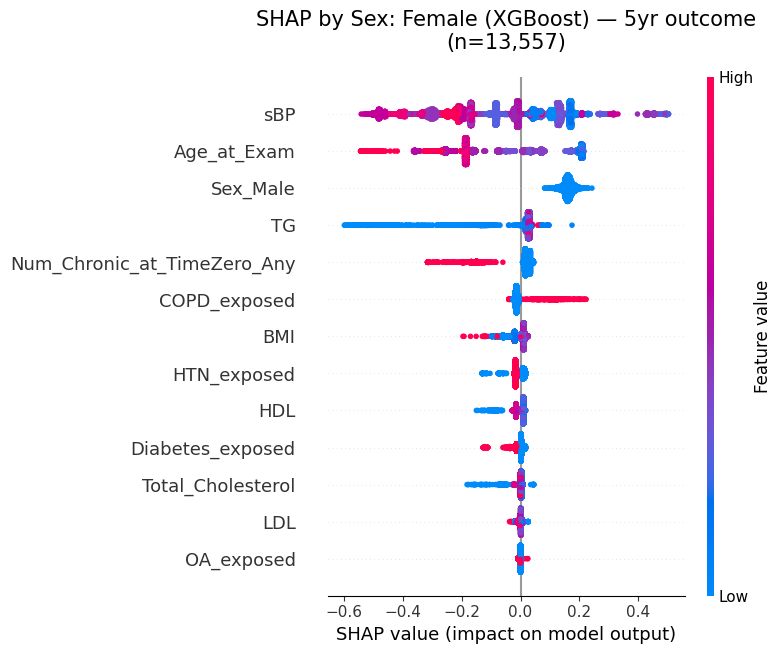

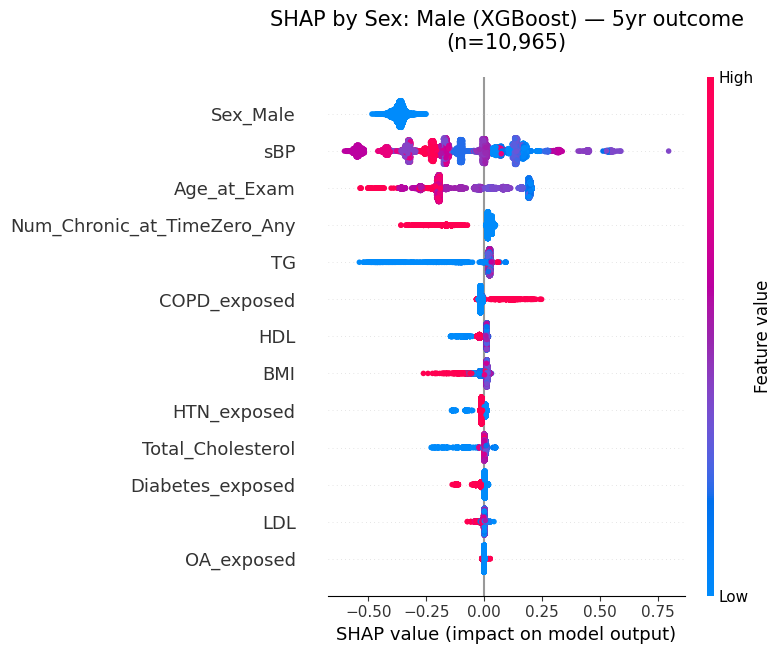

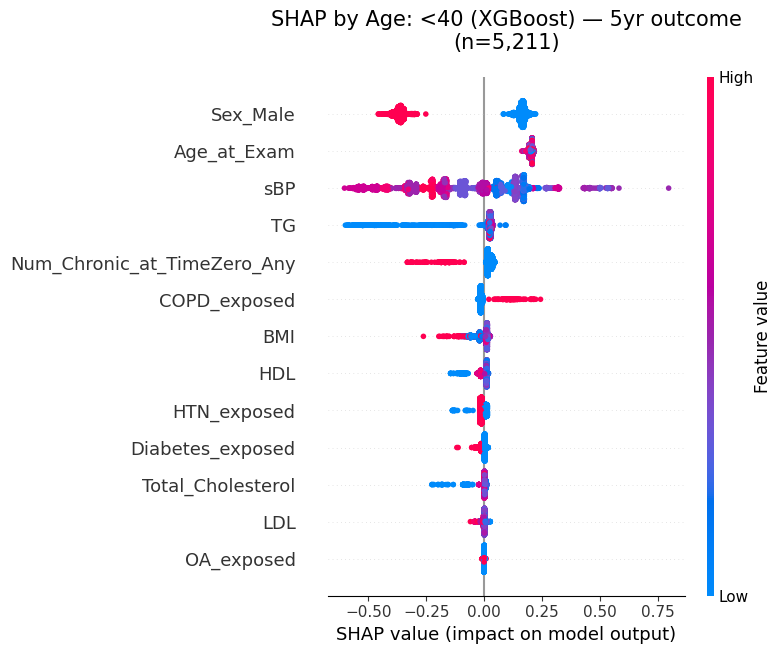

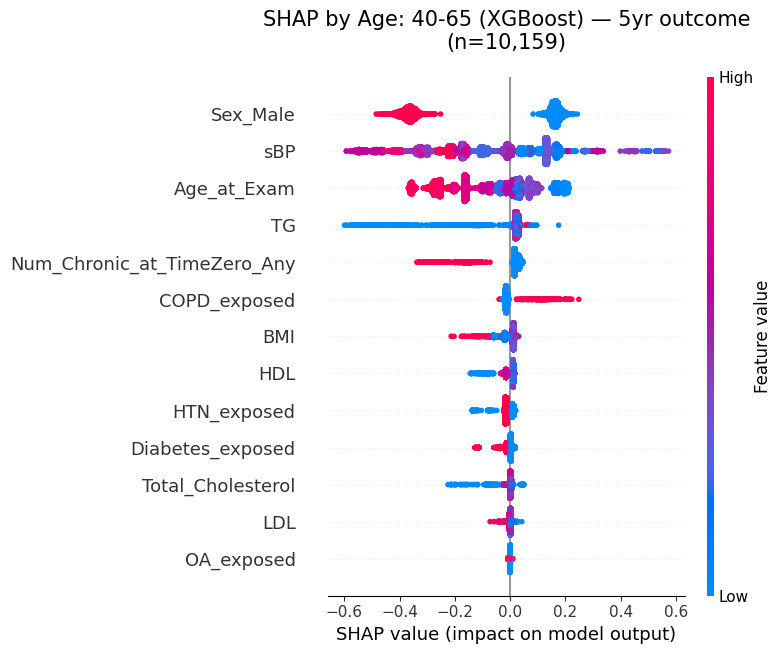

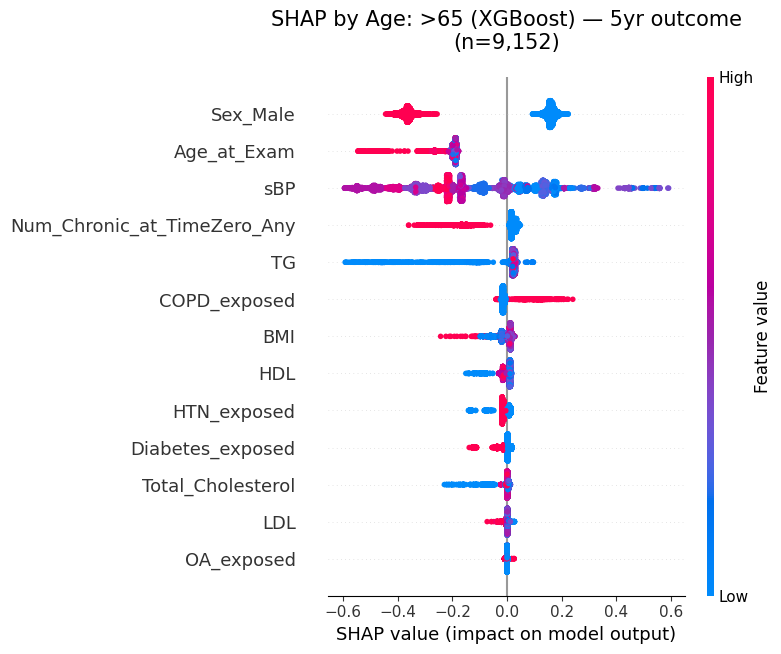


SHAP TIER 2 — RF vs XGB comparison / outcome = 1yr


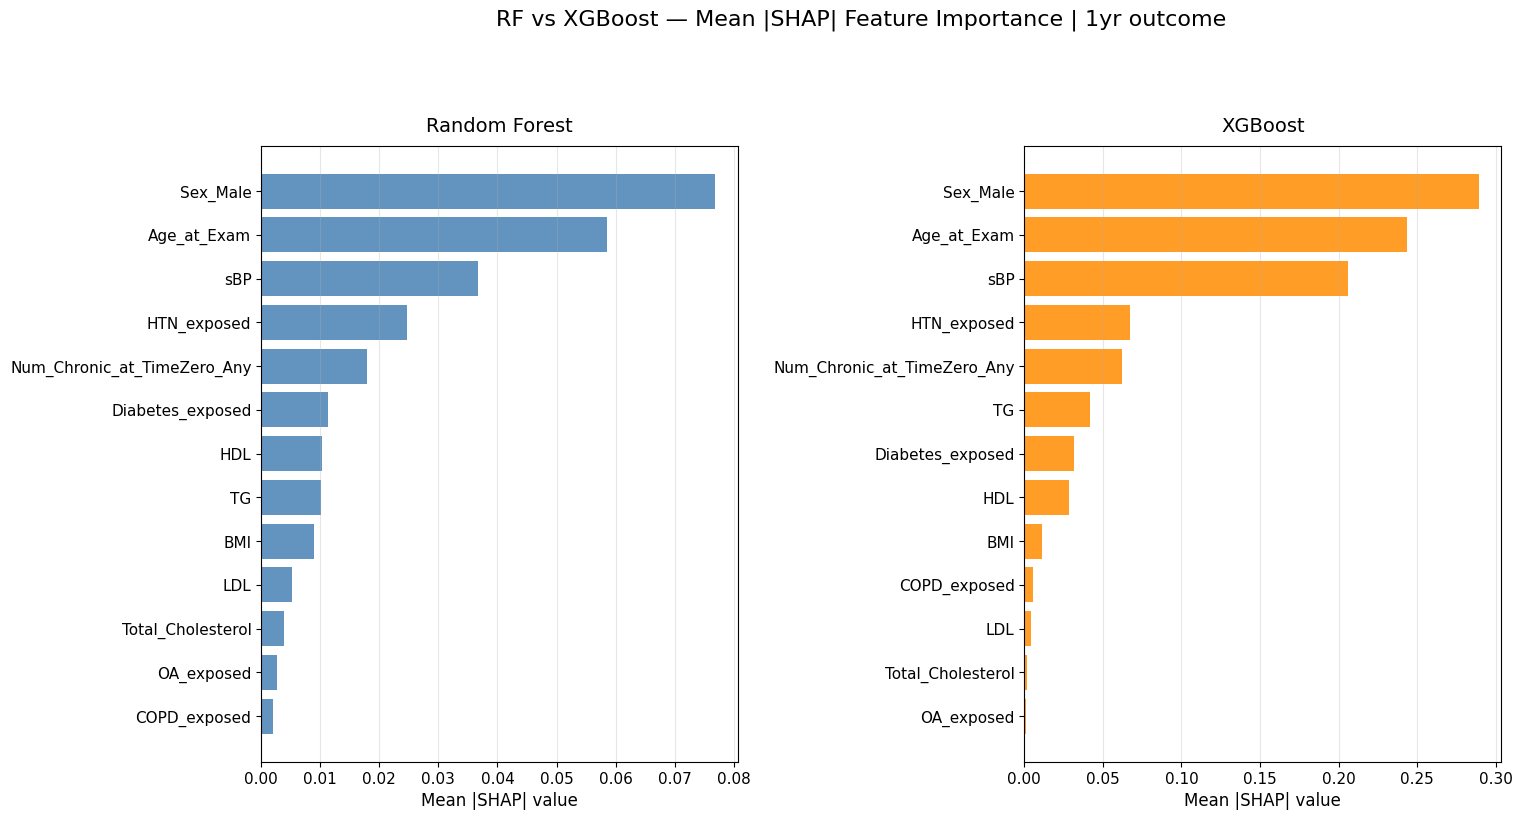


SHAP TIER 2 — RF vs XGB comparison / outcome = 3yr


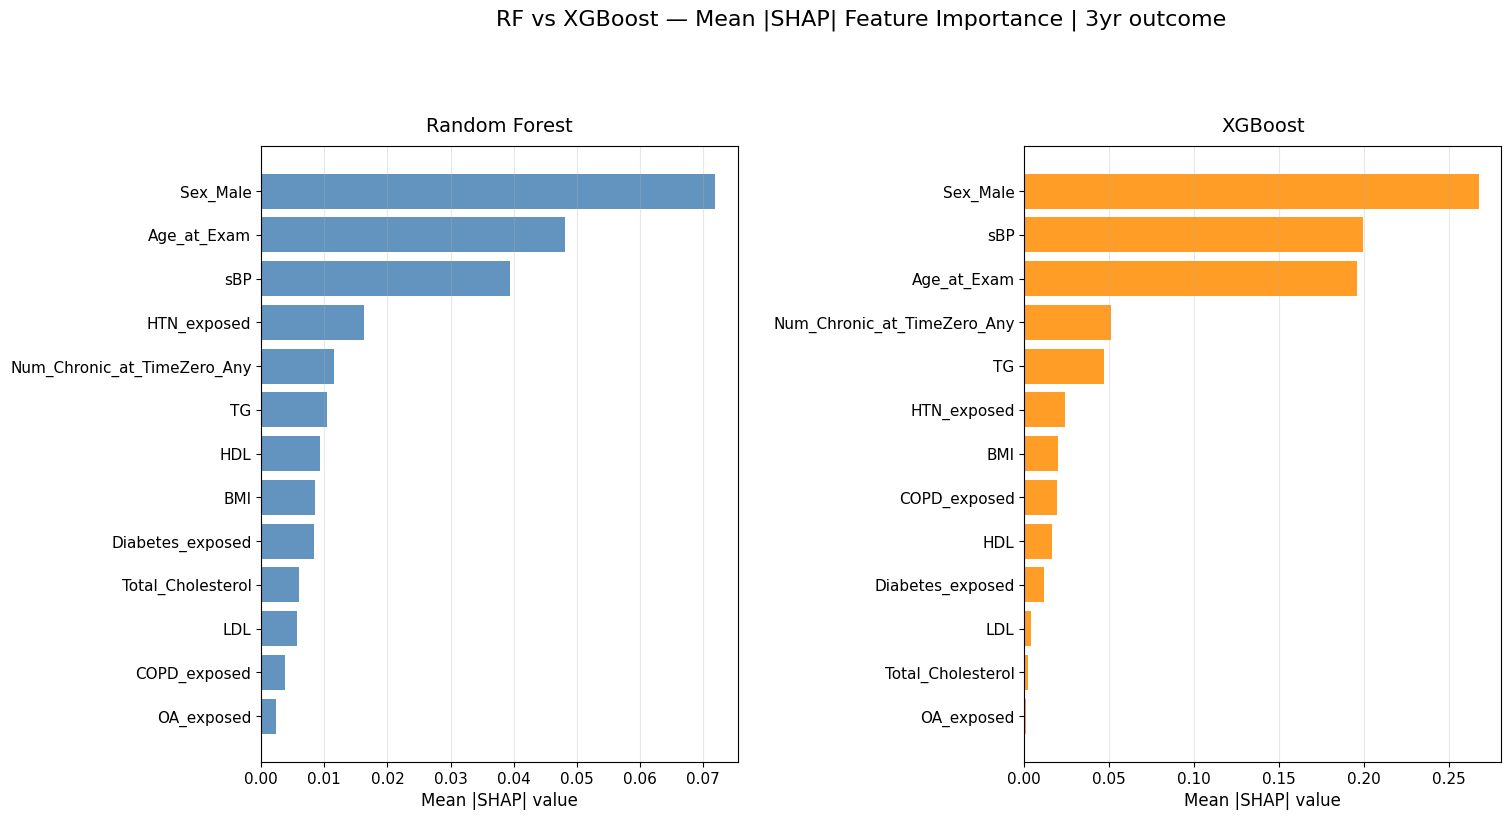


SHAP TIER 2 — RF vs XGB comparison / outcome = 5yr


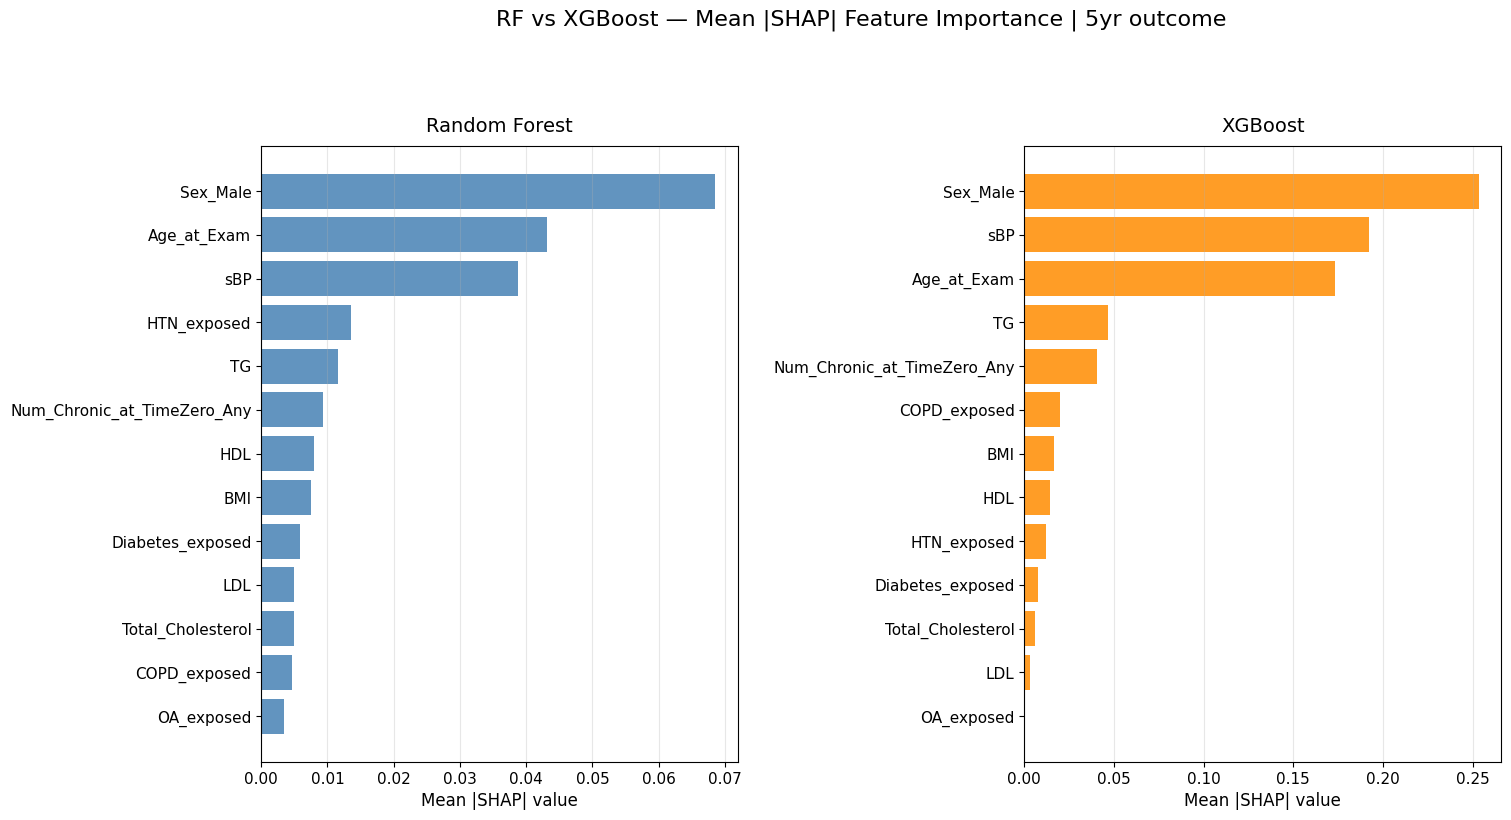

In [ ]:
## SHAP Explainability

def get_feature_names(pipeline):
    """
    Extract clean feature names from the ColumnTransformer inside a pipeline.
    Removes sklearn prefix notation (num__, bin__, cat__).
    """
    ct      = pipeline.named_steps['preprocessor']
    raw     = ct.get_feature_names_out()
    cleaned = (
        pd.Series(raw)
        .str.replace(r'^(num__|bin__|cat__)', '', regex=True)
        .tolist()
    )
    return cleaned


def transform_for_shap(pipeline, X):
    """
    Pass X through all pipeline steps EXCEPT the classifier.
    At inference the SMOTETomek step is inactive; only the preprocessor runs.
    Returns a DataFrame with cleaned feature names and the original index.
    """
    preprocessor_step = pipeline.named_steps['preprocessor']
    X_transformed     = preprocessor_step.transform(X)
    feature_names     = get_feature_names(pipeline)
    return pd.DataFrame(X_transformed, columns=feature_names, index=X.index)


def compute_shap_pos(pipeline, X_transformed):
    """
    Compute SHAP values for the positive class (depression = 1).
    """
    classifier  = pipeline.named_steps['classifier']
    explainer   = shap.TreeExplainer(classifier)

    shap_values = explainer.shap_values(X_transformed, check_additivity=False)

    if isinstance(shap_values, list):
        return shap_values[1]
    elif len(shap_values.shape) == 3:
        return shap_values[:, :, 1]
    else:
        return shap_values


def mean_abs_shap(shap_pos, feature_names, top_n=12):
    """
    Return a DataFrame of mean |SHAP| values, sorted descending.
    """
    mean_abs = np.abs(shap_pos).mean(axis=0)
    df = (
        pd.DataFrame({'Feature': feature_names, 'Mean |SHAP|': mean_abs})
        .sort_values('Mean |SHAP|', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    return df


shap_cache = {}

# TIER 1 — XGBoost full SHAP suite (per window)
for window in OUTCOMES:
    print(f"\n{'='*70}")
    print(f"SHAP TIER 1 — Champion Model (XGBoost) / outcome = {window}")
    print(f"{'='*70}")

    xgb_pipeline = trained_models[('XGB', window)]
    rf_pipeline  = trained_models[('RF', window)]

    X_test_transformed = transform_for_shap(xgb_pipeline, X_test)
    feat_names         = X_test_transformed.columns.tolist()
    total_features     = len(feat_names)

    print("  Computing XGBoost SHAP values (Fast C++ backend)...")
    shap_xgb = compute_shap_pos(xgb_pipeline, X_test_transformed)

    print("  Computing RF SHAP values (for Tier 2 comparison)...")
    shap_rf = compute_shap_pos(rf_pipeline, X_test_transformed)

    shap_cache[window] = {
        'X_tf':     X_test_transformed,
        'shap_xgb': shap_xgb,
        'shap_rf':  shap_rf,
        'feat_names': feat_names
    }

    test_meta = test_meta_base.copy()
    test_meta['y_true'] = y_splits[window]['test'].values

    # ──────────────────────────────────────────────────────────
    # (a) Global beeswarm (XGBoost)
    # ──────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_xgb, X_test_transformed,
        feature_names=feat_names,
        max_display=total_features, plot_type='dot', show=False
    )
    plt.title(f"Global SHAP (XGBoost) — {window} outcome", fontsize=15, pad=20)
    plt.tight_layout()
    plt.savefig(f'output/shap_beeswarm_xgb_{window}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ──────────────────────────────────────────────────────────
    # (c) Subgroup beeswarm by sex (XGBoost)
    # ──────────────────────────────────────────────────────────
    for sex_val in ['Female', 'Male']:
        mask     = (test_meta['Sex'] == sex_val).values
        X_sub    = X_test_transformed.iloc[mask]
        shap_sub = shap_xgb[mask]

        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            shap_sub, X_sub,
            feature_names=feat_names,
            max_display=total_features, plot_type='dot', show=False
        )
        plt.title(f"SHAP by Sex: {sex_val} (XGBoost) — {window} outcome\n(n={mask.sum():,})", fontsize=15, pad=20)
        plt.tight_layout()
        plt.savefig(f'output/shap_by_sex_{sex_val}_xgb_{window}.png', dpi=150, bbox_inches='tight')
        plt.show()

    # ──────────────────────────────────────────────────────────
    # (d) Subgroup beeswarm by age group (XGBoost)
    # ──────────────────────────────────────────────────────────
    for age_grp in ['<40', '40-65', '>65']:
        mask     = (test_meta['age_group'] == age_grp).values
        X_sub    = X_test_transformed.iloc[mask]
        shap_sub = shap_xgb[mask]

        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            shap_sub, X_sub,
            feature_names=feat_names,
            max_display=total_features, plot_type='dot', show=False
        )
        plt.title(f"SHAP by Age: {age_grp} (XGBoost) — {window} outcome\n(n={mask.sum():,})", fontsize=15, pad=20)
        plt.tight_layout()


        safe_age_name = age_grp.replace('<', 'under_').replace('>', 'over_').replace('-', '_')
        plt.savefig(f'output/shap_by_age_{safe_age_name}_xgb_{window}.png', dpi=150, bbox_inches='tight')
        plt.show()


# TIER 2 — RF vs XGBoost mean |SHAP| comparison (per window)
for window in OUTCOMES:
    print(f"\n{'='*70}")
    print(f"SHAP TIER 2 — RF vs XGB comparison / outcome = {window}")
    print(f"{'='*70}")

    feat_names = shap_cache[window]['feat_names']
    shap_rf    = shap_cache[window]['shap_rf']
    shap_xgb   = shap_cache[window]['shap_xgb']

    TOP_N  = len(feat_names)
    df_rf  = mean_abs_shap(shap_rf,  feat_names, top_n=TOP_N)
    df_xgb = mean_abs_shap(shap_xgb, feat_names, top_n=TOP_N)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.subplots_adjust(wspace=0.6)
    fig.suptitle(
        f"RF vs XGBoost — Mean |SHAP| Feature Importance | {window} outcome",
        fontsize=16, y=1.05
    )

    for ax, df, algo_label, color in zip(
        axes,
        [df_rf, df_xgb],
        ['Random Forest', 'XGBoost'],
        ['steelblue', 'darkorange']
    ):
        ax.barh(df['Feature'][::-1], df['Mean |SHAP|'][::-1], color=color, alpha=0.85)
        ax.set_xlabel('Mean |SHAP| value', fontsize=12)
        ax.set_title(algo_label, fontsize=14, pad=10)
        ax.grid(axis='x', alpha=0.3)
        ax.tick_params(labelsize=11)

    plt.savefig(f'output/shap_rf_vs_xgb_{window}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Summary Tables and Figures




FINAL MODEL COMPARISON TABLE (INCLUDING OVERFIT DIAGNOSTICS)
          Test ROC-AUC                 Train ROC-AUC                 Overfit Delta (AUC)                 Test PR-AUC                 Test F1                 Test Sensitivity                 Test Recall_W                
Window             1yr     3yr     5yr           1yr     3yr     5yr                 1yr     3yr     5yr         1yr     3yr     5yr     1yr     3yr     5yr              1yr     3yr     5yr           1yr     3yr     5yr
Algorithm                                                                                                                                                                                                                  
RF              0.6269  0.6100  0.5955        0.7185  0.6949  0.6834              0.0916  0.0849  0.0879      0.1125  0.1534  0.1695  0.1851  0.2275  0.2445           0.3911  0.4417  0.5251        0.7487  0.6820  0.6025
XGB             0.6283  0.6044  0.5928        0.6326  0.61

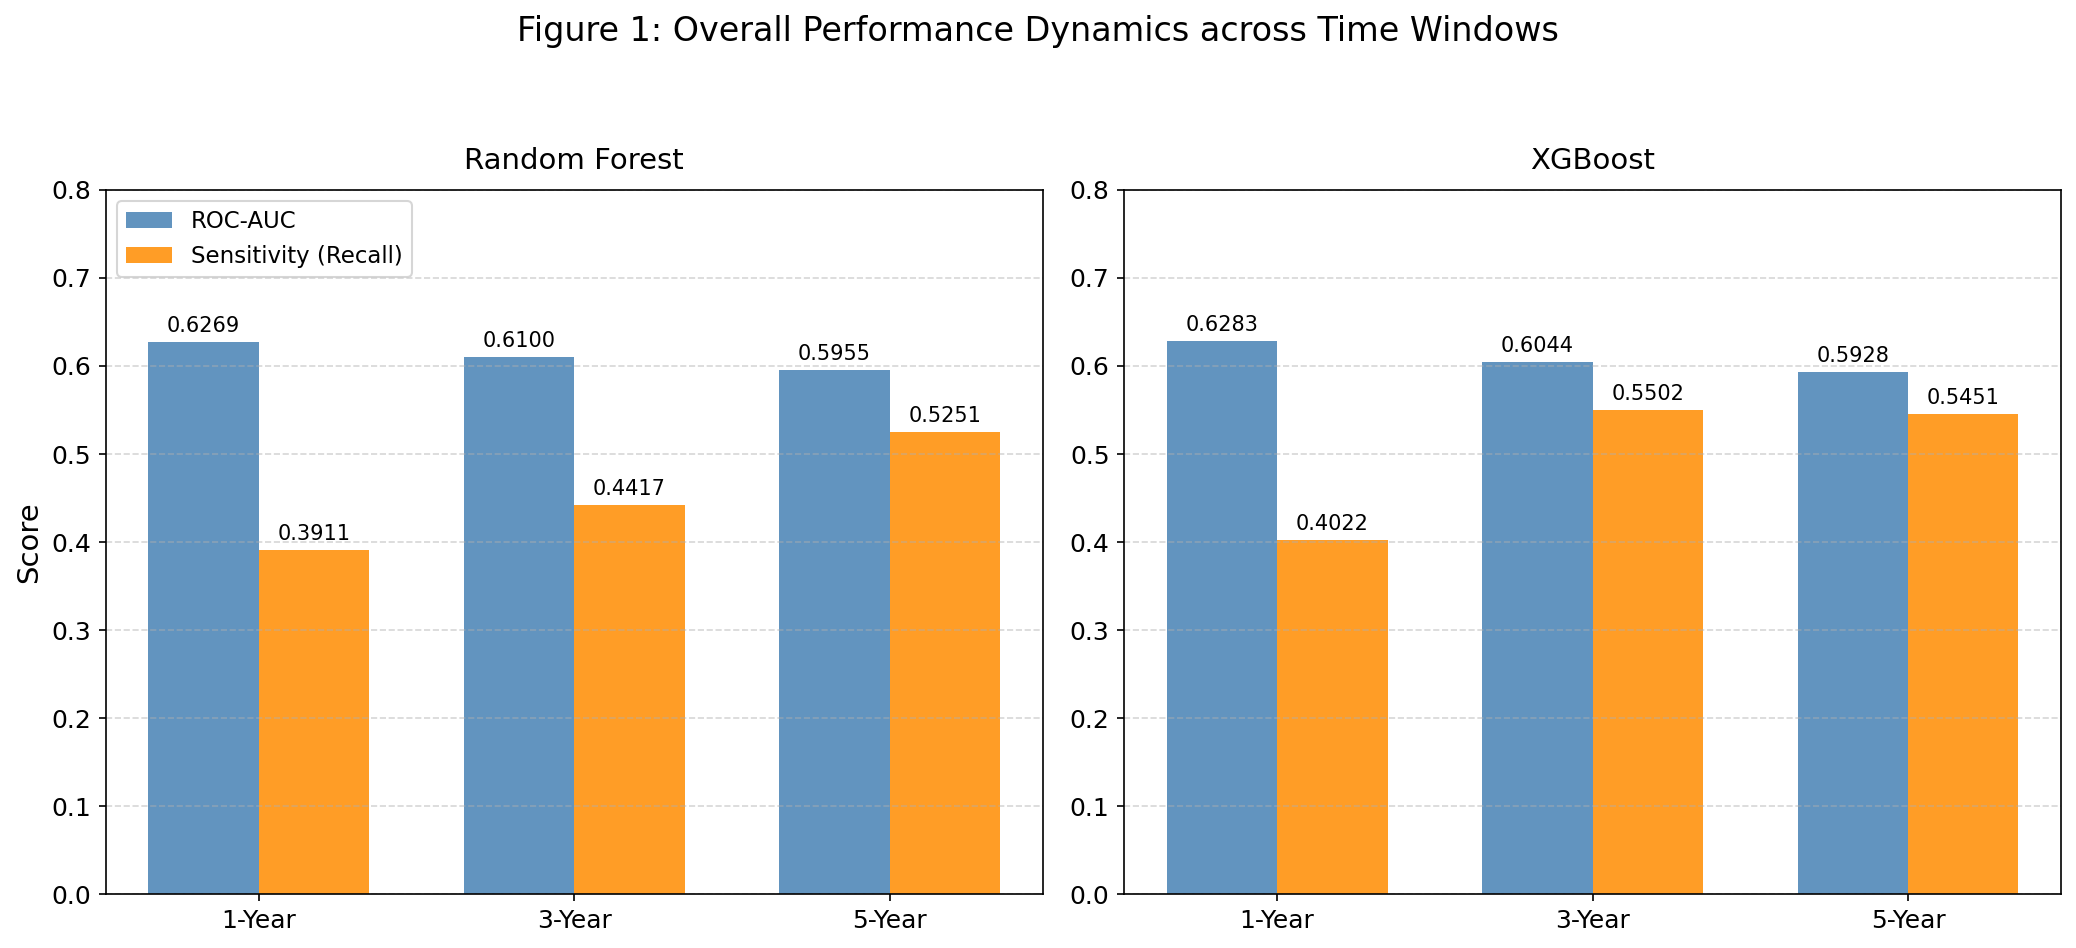

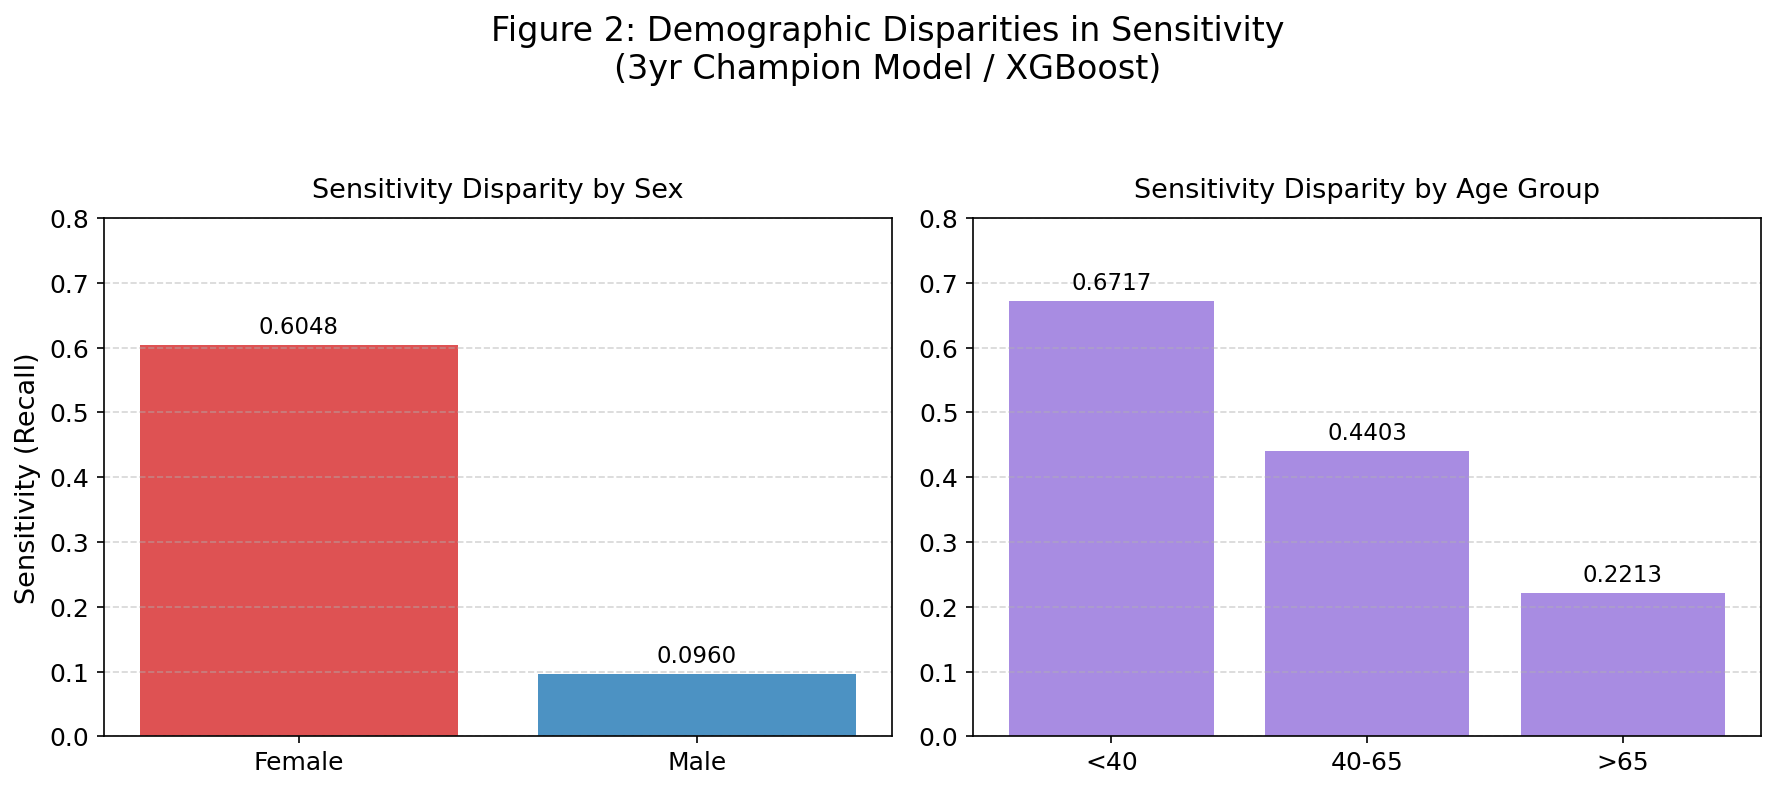

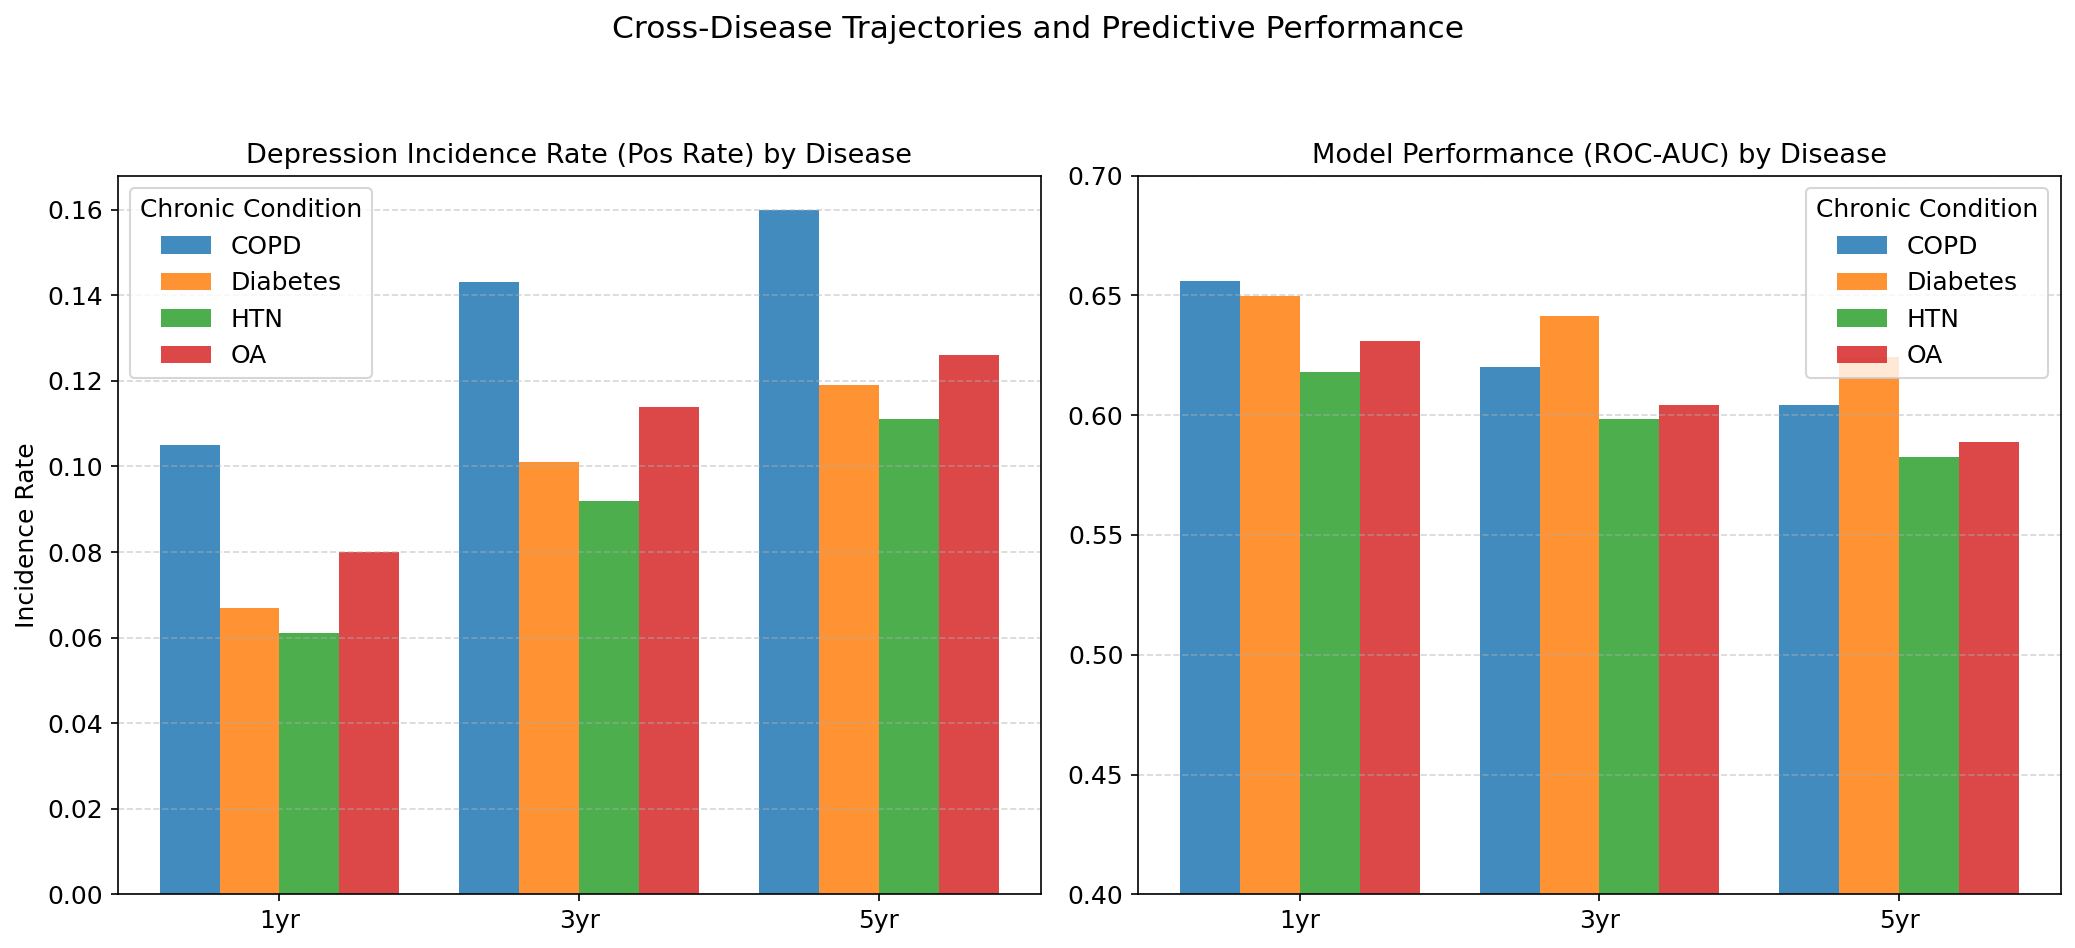

In [ ]:
## Summary Tables
print("\n" + "="*80)
print("FINAL MODEL COMPARISON TABLE (INCLUDING OVERFIT DIAGNOSTICS)")
print("="*80)

summary_pivot = results_df.pivot_table(
    index=['Algorithm'], columns='Window',
    values=['Test ROC-AUC', 'Test PR-AUC', 'Test F1', 'Test Sensitivity', 'Test Recall_W', 'Train ROC-AUC', 'Overfit Delta (AUC)']
)

cols_order = ['Test ROC-AUC', 'Train ROC-AUC', 'Overfit Delta (AUC)', 'Test PR-AUC', 'Test F1', 'Test Sensitivity', 'Test Recall_W']
summary_pivot = summary_pivot.reindex(columns=cols_order, level=0)

print(summary_pivot.to_string())
summary_pivot.to_csv('output/model_comparison_pivot.csv')
print("Saved → output/model_comparison_pivot.csv")


print("\n" + "="*80)
print("STRATIFIED PERFORMANCE SUMMARY")
print("="*80)

print("\n--- By Sex ---")
print(strat_sex_df.pivot_table(index='Subgroup', columns='Window', values=['ROC-AUC', 'Sensitivity', 'F1']).to_string())

print("\n--- By Age Group ---")
print(strat_age_df.pivot_table(index='Age Group', columns='Window', values=['ROC-AUC', 'Sensitivity', 'F1']).to_string())

print("\n--- By Disease Type ---")
print(strat_disease_df.pivot_table(index='Disease Type', columns='Window', values=['ROC-AUC', 'Sensitivity', 'F1']).to_string())

print("\n" + "="*80)
print("PIPELINE COMPLETE — all outputs saved to /output/")
import os
for f in sorted(os.listdir('output')):
    print(f"  output/{f}")
print("="*80)

## Figures
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 12})

def plot_figure_1_rf_and_xgb(df):
    windows = ['1yr', '3yr', '5yr']
    display_windows = ['1-Year', '3-Year', '5-Year']

    rf_df = df[df['Algorithm'] == 'RF'].set_index('Window')
    xgb_df = df[df['Algorithm'] == 'XGB'].set_index('Window')

    rf_roc_auc = [rf_df.loc[w, 'Test ROC-AUC'] for w in windows]
    rf_sensitivity = [rf_df.loc[w, 'Test Sensitivity'] for w in windows]

    xgb_roc_auc = [xgb_df.loc[w, 'Test ROC-AUC'] for w in windows]
    xgb_sensitivity = [xgb_df.loc[w, 'Test Sensitivity'] for w in windows]

    x = np.arange(len(windows))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
    fig.suptitle('Figure 1: Overall Performance Dynamics across Time Windows', fontsize=16, y=1.05)

    ax1 = axes[0]
    rects1_rf = ax1.bar(x - width/2, rf_roc_auc, width, label='ROC-AUC', color='steelblue', alpha=0.85)
    rects2_rf = ax1.bar(x + width/2, rf_sensitivity, width, label='Sensitivity (Recall)', color='darkorange', alpha=0.85)
    ax1.set_ylabel('Score', fontsize=14)
    ax1.set_title('Random Forest', fontsize=14, pad=10)
    ax1.set_xticks(x)
    ax1.set_xticklabels(display_windows, fontsize=12)
    ax1.set_ylim(0, 0.8)
    ax1.legend(loc='upper left', fontsize=11)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.bar_label(rects1_rf, padding=3, fmt='%.4f', fontsize=10)
    ax1.bar_label(rects2_rf, padding=3, fmt='%.4f', fontsize=10)

    ax2 = axes[1]
    rects1_xgb = ax2.bar(x - width/2, xgb_roc_auc, width, label='ROC-AUC', color='steelblue', alpha=0.85)
    rects2_xgb = ax2.bar(x + width/2, xgb_sensitivity, width, label='Sensitivity (Recall)', color='darkorange', alpha=0.85)
    ax2.set_title('XGBoost', fontsize=14, pad=10)
    ax2.set_xticks(x)
    ax2.set_xticklabels(display_windows, fontsize=12)
    ax2.set_ylim(0, 0.8)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    ax2.bar_label(rects1_xgb, padding=3, fmt='%.4f', fontsize=10)
    ax2.bar_label(rects2_xgb, padding=3, fmt='%.4f', fontsize=10)

    plt.tight_layout()
    plt.savefig('output/Figure_1_RF_vs_XGBoost_Time_Windows.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_figure_2(sex_df, age_df, target_window='3yr'):
    sex_sub = sex_df[sex_df['Window'] == target_window]
    age_sub = age_df[age_df['Window'] == target_window]

    sex_labels = ['Female', 'Male']
    sex_sens = [sex_sub[sex_sub['Subgroup'] == l]['Sensitivity'].values[0] if len(sex_sub[sex_sub['Subgroup'] == l]) > 0 else 0 for l in sex_labels]

    age_labels = ['<40', '40-65', '>65']
    age_sens = [age_sub[age_sub['Age Group'] == l]['Sensitivity'].values[0] if len(age_sub[age_sub['Age Group'] == l]) > 0 else 0 for l in age_labels]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
    fig.suptitle(f'Figure 2: Demographic Disparities in Sensitivity\n({target_window} Champion Model / XGBoost)', fontsize=16, y=1.05)

    ax1 = axes[0]
    bars1 = ax1.bar(sex_labels, sex_sens, color=['#d62728', '#1f77b4'], alpha=0.8)
    ax1.set_title('Sensitivity Disparity by Sex', fontsize=13, pad=10)
    ax1.set_ylabel('Sensitivity (Recall)', fontsize=13)
    ax1.set_ylim(0, 0.8)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.bar_label(bars1, padding=3, fmt='%.4f', fontsize=11)

    ax2 = axes[1]
    bars2 = ax2.bar(age_labels, age_sens, color='mediumpurple', alpha=0.8)
    ax2.set_title('Sensitivity Disparity by Age Group', fontsize=13, pad=10)
    ax2.set_ylim(0, 0.8)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    ax2.bar_label(bars2, padding=3, fmt='%.4f', fontsize=11)

    plt.tight_layout()
    plt.savefig('output/Figure_2_Demographic_Disparities.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_disease_stratification(df):
    windows = ['1yr', '3yr', '5yr']
    diseases = df['Disease Type'].unique()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
    fig.suptitle("Cross-Disease Trajectories and Predictive Performance", fontsize=15, y=1.05)

    width = 0.2
    x = np.arange(len(windows))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    ax1 = axes[0]
    for i, disease in enumerate(diseases):
        sub_df = df[df['Disease Type'] == disease]
        rates = [sub_df[sub_df['Window'] == w]['Pos Rate'].values[0] for w in windows]
        ax1.bar(x + (i - 1.5) * width, rates, width, label=disease, color=colors[i % len(colors)], alpha=0.85)
    ax1.set_title('Depression Incidence Rate (Pos Rate) by Disease', fontsize=13)
    ax1.set_xticks(x)
    ax1.set_xticklabels(windows)
    ax1.set_ylabel('Incidence Rate', fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.legend(title='Chronic Condition')

    ax2 = axes[1]
    for i, disease in enumerate(diseases):
        sub_df = df[df['Disease Type'] == disease]
        aucs = [sub_df[sub_df['Window'] == w]['ROC-AUC'].values[0] for w in windows]
        ax2.bar(x + (i - 1.5) * width, aucs, width, label=disease, color=colors[i % len(colors)], alpha=0.85)
    ax2.set_title('Model Performance (ROC-AUC) by Disease', fontsize=13)
    ax2.set_xticks(x)
    ax2.set_xticklabels(windows)
    ax2.set_ylim(0.4, 0.7)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    ax2.legend(title='Chronic Condition')

    plt.tight_layout()
    plt.savefig('output/disease_trajectories.png', dpi=300, bbox_inches='tight')
    plt.show()

# Execution
plot_figure_1_rf_and_xgb(results_df)
plot_figure_2(strat_sex_df, strat_age_df, target_window='3yr')
plot_disease_stratification(strat_disease_df)